
# Layer 1 — Dynamic Factor Model Backbone

This notebook implements **Layer 1** of the project:

> **Real-Time GDP Growth Nowcasting using a Hybrid Dynamic Factor Model with Machine Learning Residual Correction**

Scope in this notebook:

- audit the **actual local repository** before modeling;
- preserve the repository’s **first-day-of-month / first-day-of-quarter** timestamp semantics;
- construct a **vintage-aware GDP target history** and separate **truth tables**;
- ingest and transform the **monthly FRED-MD vintage files**;
- align monthly predictors with quarterly GDP in a **mixed-frequency state-space DFM**;
- estimate the DFM via **EM + Kalman filter / smoother**;
- produce **GDP nowcasts**, **news decomposition**, **coverage diagnostics**, and **Layer 2 artifacts**.

This notebook is aligned to **Section 3** of the methodological outline and the final project write-up, and uses the stable-subset block/tcode design from the uploaded data dictionary. The Layer 2 residual-correction model is **not** estimated here; the notebook exports the objects it will need.



## Non-negotiable date rule

The repository does **not** use artificial month-end timestamps as its native convention.

This notebook therefore:

- treats strings such as `2026-01-01` as **January 2026**, not as a month-end date;
- treats quarter markers using **period semantics** and sequence-aware parsing;
- avoids invalid synthetic dates such as `2026-02-29`;
- only converts to timestamp form when a downstream library requires it, and then uses the **period start timestamp** rather than a fabricated month-end.

Internally, audit and alignment logic use `pandas.Period` objects wherever possible.


In [1]:
from __future__ import annotations

import importlib
import json
import math
import hashlib
import platform
import sys
import warnings
from dataclasses import replace
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

NOTEBOOK_DIR = Path.cwd()
if str(NOTEBOOK_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOK_DIR))

try:
    try:
        import dfm_layer1_utils as _layer1_utils
    except ImportError:
        import dfm_layer1_utils_1 as _layer1_utils

    _layer1_utils = importlib.reload(_layer1_utils)
    _HELPER_EXPORTS = [
        "ProtocolConfig",
        "apply_tcodes_to_snapshot",
        "as_model_index",
        "build_factor_mapping",
        "build_layer2_residual_design",
        "export_layer2_handoff_package",
        "build_quarterly_target_series_for_vintage",
        "build_repo_catalog",
        "build_target_and_truth_objects",
        "choose_canonical_md_manifest",
        "choose_canonical_qd_manifest",
        "choose_vintage_schedule",
        "completion_checklist_frame",
        "compute_block_coverage",
        "extract_nowcast_from_results",
        "fit_dfm_single_vintage",
        "get_quarter_end_month",
        "infer_period_frequency_from_values",
        "inspect_csv_schema",
        "inspect_excel_workbook",
        "load_fred_snapshot",
        "locate_repo_root",
        "make_diagnostics_row",
        "model_prediction_index_audit",
        "oriented_factor_states",
        "parse_periodish",
        "prepare_mixed_frequency_model_inputs",
        "protocol_summary_frame",
        "run_layer1_dfm",
        "select_monthly_panel",
        "select_target_workbooks",
        "serialize_protocol",
        "stable_subset_metadata",
        "summarize_manifest",
        "within_quarter_origin",
        "quarter_of_vintage",
    ]
    globals().update({name: getattr(_layer1_utils, name) for name in _HELPER_EXPORTS})
except ImportError as exc:
    raise ImportError(
        "dfm_layer1_utils.py was not found next to the notebook. "
        "Place the helper file in the repository root (or the notebook working directory) and rerun."
    ) from exc

warnings.filterwarnings("ignore", category=FutureWarning)


In [2]:

import statsmodels
import openpyxl

env = pd.DataFrame(
    [
        {"component": "python", "version": platform.python_version()},
        {"component": "pandas", "version": pd.__version__},
        {"component": "numpy", "version": np.__version__},
        {"component": "statsmodels", "version": statsmodels.__version__},
        {"component": "openpyxl", "version": openpyxl.__version__},
    ]
)
display(env)


,component,version
0,python,3.13.5
1,pandas,2.3.3
2,numpy,2.1.3
3,statsmodels,0.14.6
4,openpyxl,3.1.5


## 1. Project setup

In [3]:

# If the notebook is placed inside the repository (recommended), auto-detection should work.
# Otherwise, set REPO_ROOT_HINT to the absolute local path of the cloned repository.
REPO_ROOT_HINT = None

REPO_ROOT = Path(REPO_ROOT_HINT) if REPO_ROOT_HINT else locate_repo_root(Path.cwd())
if REPO_ROOT is None or not REPO_ROOT.exists():
    raise FileNotFoundError(
        "Could not locate the Nowcasting-GDP-Growth repository automatically. "
        "Set REPO_ROOT_HINT to the local repository path and rerun."
    )

RAW_DIR = REPO_ROOT / "data" / "raw"
OUTPUT_DIR = REPO_ROOT / "outputs" / "layer1_dfm"

print("Repository root:", REPO_ROOT)
print("Raw data directory:", RAW_DIR)
print("Output directory:", OUTPUT_DIR)


Repository root: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting
Raw data directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting/data/raw
Output directory: /Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowcasting/outputs/layer1_dfm


## 2. Repository audit and file mapping

In [4]:

catalog = build_repo_catalog(REPO_ROOT)

catalog_summary = (
    catalog.groupby("group", dropna=False)
    .agg(
        n_files=("path", "size"),
        first_vintage=("vintage_period", "min"),
        last_vintage=("vintage_period", "max"),
        total_size_mb=("size_mb", "sum"),
    )
    .reset_index()
    .sort_values(["group"])
)

md_manifest = choose_canonical_md_manifest(catalog)
qd_manifest = choose_canonical_qd_manifest(catalog)
target_workbooks = select_target_workbooks(REPO_ROOT)

manifest_summary = pd.concat(
    [
        summarize_manifest(md_manifest, "Canonical monthly predictor manifest"),
        summarize_manifest(qd_manifest, "Canonical quarterly predictor manifest"),
    ],
    ignore_index=True,
)

workbook_map = pd.DataFrame(
    [
        {"object_name": k, "path": str(v.relative_to(REPO_ROOT))}
        for k, v in sorted(target_workbooks.items())
    ]
)

display(catalog_summary)
display(manifest_summary)
display(workbook_map)


,group,n_files,first_vintage,last_vintage,total_size_mb
0,excel_workbook,6,NaT,NaT,1.581030
1,fred_md_current,15,2025-01,2026-02,9.417383
2,fred_md_hist_2015_2024,120,2015-01,2024-12,69.586911
3,fred_md_hist_legacy,187,1999-08,2014-12,213.703775
4,fred_qd_current,15,2025-01,2026-02,7.323709
5,fred_qd_hist_2018_2024,80,2018-05,2024-12,36.600430
6,other,692,2024-03,2024-12,152.930893
7,sample_csv,2,2016-06,2016-07,0.112094


,label,count,min_vintage,max_vintage,min_path,max_path
0,Canonical monthly predictor manifest,319,1999-08,2026-02,data/raw/Historical FRED-MD Vintages Final/1999-08.csv,data/raw/FRED-MD-MONTHLY/2026-02-MD.csv
1,Canonical quarterly predictor manifest,94,2018-05,2026-02,data/raw/Historical vintages of FRED-QD 2018-05 to 2024-12/FRED-QD_2018m05.csv,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv


,object_name,path
0,GDPplus_Vintages.xlsx,data/raw/GDPplus_Vintages.xlsx
1,ROUTPUTQvQd.xlsx,data/raw/ROUTPUTQvQd.xlsx
2,meanGrowth.xlsx,data/raw/meanGrowth.xlsx
3,medianGrowth.xlsx,data/raw/medianGrowth.xlsx
4,routputMvQd.xlsx,data/raw/routputMvQd.xlsx
5,routput_first_second_third.xlsx,data/raw/routput_first_second_third.xlsx


In [5]:

def hash_file(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

hash_checks = []

md_current = REPO_ROOT / "data" / "raw" / "FRED-MD-MONTHLY" / "current.csv"
if md_current.exists() and not md_manifest.empty:
    latest_md = REPO_ROOT / md_manifest.iloc[-1]["path"]
    hash_checks.append(
        {
            "file_group": "monthly current vs latest dated file",
            "current_path": str(md_current.relative_to(REPO_ROOT)),
            "latest_dated_path": str(latest_md.relative_to(REPO_ROOT)),
            "same_bytes": hash_file(md_current) == hash_file(latest_md),
        }
    )

qd_current = REPO_ROOT / "data" / "raw" / "FRED-QD-QUARTERLY" / "current.csv"
if qd_current.exists() and not qd_manifest.empty:
    latest_qd = REPO_ROOT / qd_manifest.iloc[-1]["path"]
    hash_checks.append(
        {
            "file_group": "quarterly current vs latest dated file",
            "current_path": str(qd_current.relative_to(REPO_ROOT)),
            "latest_dated_path": str(latest_qd.relative_to(REPO_ROOT)),
            "same_bytes": hash_file(qd_current) == hash_file(latest_qd),
        }
    )

display(pd.DataFrame(hash_checks))


,file_group,current_path,latest_dated_path,same_bytes
0,monthly current vs latest dated file,data/raw/FRED-MD-MONTHLY/current.csv,data/raw/FRED-MD-MONTHLY/2026-02-MD.csv,True
1,quarterly current vs latest dated file,data/raw/FRED-QD-QUARTERLY/current.csv,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv,True


## 3. Raw file inspection and schema understanding

In [6]:

def compact_csv_inspection(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    info = inspect_csv_schema(path)
    summary = pd.DataFrame(
        [
            {
                "path": str(Path(info["path"]).relative_to(REPO_ROOT)),
                "date_col": info["date_col"],
                "inferred_freq": info["inferred_freq"],
                "metadata_row_count": info["metadata_row_count"],
                "has_tcode_row": info["has_tcode_row"],
                "n_rows": info["n_rows"],
                "n_cols": info["n_cols"],
                "min_timestamp": info["min_timestamp"],
                "max_timestamp": info["max_timestamp"],
            }
        ]
    )
    return summary, info["preview"]

representative_paths = []
if len(md_manifest) > 0:
    representative_paths.extend(
        [
            REPO_ROOT / md_manifest.iloc[0]["path"],
            REPO_ROOT / md_manifest.iloc[len(md_manifest) // 2]["path"],
            REPO_ROOT / md_manifest.iloc[-1]["path"],
        ]
    )
if len(qd_manifest) > 0:
    representative_paths.extend(
        [
            REPO_ROOT / qd_manifest.iloc[0]["path"],
            REPO_ROOT / qd_manifest.iloc[-1]["path"],
        ]
    )

sample_dir = REPO_ROOT / "data" / "sample"
if sample_dir.exists():
    sample_csvs = sorted(sample_dir.glob("*.csv"))
    if sample_csvs:
        representative_paths.append(sample_csvs[0])

for path in representative_paths:
    print(f"\nInspecting: {path.relative_to(REPO_ROOT)}")
    summary, preview = compact_csv_inspection(path)
    display(summary)
    display(preview)



Inspecting: data/raw/Historical FRED-MD Vintages Final/1999-08.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/Historical FRED-MD Vintages Final/1999-08.csv,sasdate,M,1,True,488,113,1959-01-01,1999-07-01


,sasdate,RPI,W875RX1,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPMAT,IPMANSICS,CUMFNS,CLF16OV,CE16OV,UNRATE,UEMPMEAN,UEMPLT5,UEMP5TO14,UEMP15OV,UEMP15T26,UEMP27OV,CLAIMSx,PAYEMS,USGOOD,CES1021000001,USCONS,MANEMP,DMANEMP,NDMANEMP,SRVPRD,USWTRADE,USTRADE,USFIRE,USGOVT,CES0600000007,AWOTMAN,AWHMAN,HOUST,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,PERMIT,PERMITNE,PERMITMW,PERMITS,PERMITW,AMDMNOx,ANDENOx,AMDMUOx,BUSINVx,ISRATIOx,M1SL,M2SL,M2REAL,AMBSL,TOTRESNS,NONBORRES,BUSLOANS,REALLN,NONREVSL,CONSPI,S&P 500,S&P: indust,S&P div yield,S&P PE ratio,FEDFUNDS,CP3Mx,TB3MS,TB6MS,GS1,GS5,GS10,AAA,BAA,COMPAPFFx,TB3SMFFM,TB6SMFFM,T1YFFM,T5YFFM,T10YFFM,AAAFFM,BAAFFM,TWEXMMTH,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,PPIFGS,PPIFCG,PPIITM,PPICRM,OILPRICEx,PPICMM,CPIAUCSL,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,MZMSL,DTCOLNVHFNM,DTCTHFNM,INVEST,VXOCLSx
0,Transform:,5.0,5.0,5.0,5.0,5.000,5.000,5.000,5.000,5.000,5.000,2.0,5.0,5.0,2.0,2.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,1.0,2.0,1.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,2.00,6.0,6.0,5.0,6.0,6.000,7.0,6.0,6.0,6.0,2.000000,5.00,5.00,2.000000,5.000000,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,2.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,5.0,5.0000,5.0000,5.0000,5.0000,6.0,6.0,6.0,6.0,6.00,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.0,6.00,6.00,6.00,2.0,6.0,6.0,6.0,6.0,1.0
1,01/01/1959,1691.3,1575.1,198740.0,17583.0,34.431,33.836,33.225,37.314,35.084,32.264,80.2,67936.0,63868.0,6.0,16.3,1574.0,1169.0,1396.0,594.0,802.0,292.0,52408.0,20060.0,752.0,2957.0,16351.0,9108.0,7243.0,32348.0,3037.0,7887.0,2511.0,7974.0,39.6,2.5,40.1,1657.0,350.0,452.0,505.0,350.0,NaN,NaN,NaN,NaN,NaN,15647.0,NaN,44685.0,87140.0,1.51,138.9,286.6,988.3,38.5,18.889,18338.0,NaN,NaN,49.0,0.127971,55.62,59.30,3.158342,18.445741,2.48,3.30,2.82,3.09,3.36,4.01,4.02,4.12,4.87,0.82,0.34,0.61,0.88,1.53,1.54,1.64,2.39,NaN,4.3122,359.8417,2.8065,0.9671,33.1,33.4,30.6,31.6,3.00,32.5,29.0,44.8,29.3,21.1,33.3,38.1,22.9,28.9,30.7,29.6,2.28,2.87,2.16,NaN,274.9,6476.0,12298.0,NaN,NaN
2,02/01/1959,1699.2,1581.7,201548.0,17712.0,35.105,34.293,33.513,37.588,36.195,32.857,81.4,67649.0,63684.0,5.9,15.5,1554.0,1164.0,1277.0,545.0,732.0,284.0,52568.0,20121.0,743.0,2935.0,16443.0,9189.0,7254.0,32447.0,3042.0,7932.0,2513.0,7984.0,39.6,2.6,40.2,1667.0,346.0,469.0,508.0,344.0,NaN,NaN,NaN,NaN,NaN,16374.0,NaN,45793.0,87440.0,1.49,139.4,287.7,992.1,38.8,18.570,18065.0,NaN,NaN,49.5,0.128505,54.77,58.33,3.219518,18.418119,2.43,3.26,2.70,3.13,3.54,3.96,3.96,4.14,4.89,0.83,0.27,0.70,1.11,1.53,1.53,1.71,2.46,NaN,4.3133,359.8417,2.8093,0.9748,33.2,33.4,30.7,31.4,3.00,32.5,29.0,44.7,29.4,21.2,33.3,38.1,23.0,28.9,30.7,29.6,2.29,2.88,2.17,NaN,276.0,6476.0,12298.0,NaN,NaN
3,03/01/1959,1712.8,1595.6,204077.0,17860.0,35.611,34.500,33.677,37.588,37.135,33.371,82.5,68068.0,64267.0,5.6,15.3,1459.0,1093.0,1210.0,530.0,680.0,258.0,52883.0,20313.0,743.0,2958.0,16612.0,9329.0,7283.0,32570.0,3051.0,7980.0,2523.0,8002.0,39.9,2.8,40.4,1620.0,330.0,413.0,503.0,374.0,NaN,NaN,NaN,NaN,NaN,16741.0,NaN,46951.0,87890.0,1.48,139.7,289.2,997.2,38.8,18.431,17832.0,NaN,NaN,50.0,0.128766,56.16,59.79,3.151709,18.999351,2.80,3.35,2.80,3.13,3.61,3.99,3.99,4.13,4.85,0.55,0.00,0.33,0.81,1.19,1.19,1.33,2.05,NaN,4.3228,359.8417,2.8127,0.9698,33.2,33.3,30.7,31.5,2.97,32.9,29.0,44.7,29.6,21.3,33.2,38.3,23.0,28.9,30.7,29.6,2.31,2.87,2.19,NaN,277.4,6508.0,12349.0,NaN,NaN
4,04/01/1959,1723.0,1606.0,206542.0,17871.0,36.370,34.999,34.171,38.181,38.161,34.083,84.0,68339.0,64768.0,5.2,14.9,1494.0,934.0,1039.0,408.0,631.0,244.0,53132.0,20514.0,743.0,3038.0,16733.0,9439.0,7294.0,32618.0,3064.0,7937.0,2534.0,8016.0,40.0,2.8,40.5,1590.0,275.0,391.0,536.0,388.0,NaN,NaN,NaN,NaN,NaN,16926.0,NaN,47728.0,89070.0,1.48,139.7,290.1,1000.3,38.9,18.678,17986.0,NaN,NaN,50.5,0.129057,57.10,60.92,3.111506,19.272973,2.96,3.42,2.95,3.27,3.72,4.12,4.12,4.23,4.86,0.46,-0.01,0.31,0.76,


Inspecting: data/raw/Historical FRED-MD Vintages Final/2012-11.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/Historical FRED-MD Vintages Final/2012-11.csv,sasdate,M,1,True,647,127,1959-01-01,2012-10-01


...

,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv,sasdate,Q,2,True,270,246,1959-01-01,2025-10-01


,sasdate,GDPC1,PCECC96,PCDGx,PCESVx,PCNDx,GPDIC1,FPIx,Y033RC1Q027SBEAx,PNFIx,PRFIx,A014RE1Q156NBEA,GCEC1,A823RL1Q225SBEA,FGRECPTx,SLCEx,EXPGSC1,IMPGSC1,DPIC96,OUTNFB,OUTBS,OUTMS,INDPRO,IPFINAL,IPCONGD,IPMAT,IPDMAT,IPNMAT,IPDCONGD,IPB51110SQ,IPNCONGD,IPBUSEQ,IPB51220SQ,TCU,CUMFNS,PAYEMS,USPRIV,MANEMP,SRVPRD,USGOOD,DMANEMP,NDMANEMP,USCONS,USEHS,USFIRE,USINFO,USPBS,USLAH,USSERV,USMINE,USTPU,USGOVT,USTRADE,USWTRADE,CES9091000001,CES9092000001,CES9093000001,CE16OV,CIVPART,UNRATE,UNRATESTx,UNRATELTx,LNS14000012,LNS14000025,LNS14000026,UEMPLT5,UEMP5TO14,UEMP15T26,UEMP27OV,LNS13023621,LNS13023557,LNS13023705,LNS13023569,LNS12032194,HOABS,HOAMS,HOANBS,AWHMAN,AWHNONAG,AWOTMAN,HWIx,HOUST,HOUST5F,PERMIT,HOUSTMW,HOUSTNE,HOUSTS,HOUSTW,CMRMTSPLx,RSAFSx,AMDMNOx,ACOGNOx,AMDMUOx,ANDENOx,INVCQRMTSPL,PCECTPI,PCEPILFE,GDPCTPI,GPDICTPI,IPDBS,...,TB6MS,GS1,GS10,MORTGAGE30US,AAA,BAA,BAA10YM,MORTG10YRx,TB6M3Mx,GS1TB3Mx,GS10TB3Mx,CPF3MTB3Mx,BOGMBASEREALx,M1REAL,M2REAL,BUSLOANSx,CONSUMERx,NONREVSLx,REALLNx,REVOLSLx,TOTALSLx,DRIWCIL,TABSHNOx,TLBSHNOx,LIABPIx,TNWBSHNOx,NWPIx,TARESAx,HNOREMQ027Sx,TFAABSHNOx,VIXCLSx,USSTHPI,SPCS10RSA,SPCS20RSA,TWEXAFEGSMTHx,EXUSEU,EXSZUSx,EXJPUSx,EXUSUKx,EXCAUSx,UMCSENTx,USEPUINDXM,B020RE1Q156NBEA,B021RE1Q156NBEA,GFDEGDQ188S,GFDEBTNx,IPMANSICS,IPB51222S,IPFUELS,UEMPMEAN,CES0600000007,TOTRESNS,NONBORRES,GS5,TB3SMFFM,T5YFFM,AAAFFM,WPSID62,PPICMM,CPIAPPSL,CPITRNSL,CPIMEDSL,CUSR0000SAC,CUSR0000SAD,CUSR0000SAS,CPIULFSL,CUSR0000SA0L2,CUSR0000SA0L5,CES0600000008,DTCOLNVHFNM,DTCTHFNM,INVEST,HWIURATIOx,CLAIMSx,BUSINVx,ISRATIOx,CONSPIx,CP3M,COMPAPFF,PERMITNE,PERMITMW,PERMITS,PERMITW,NIKKEI225,NASDAQCOM,CUSR0000SEHC,TLBSNNCBx,TLBSNNCBBDIx,TTAABSNNCBx,TNWMVBSNNCBx,TNWMVBSNNCBBDIx,TLBSNNBx,TLBSNNBBDIx,TABSNNBx,TNWBSNNBx,TNWBSNNBBDIx,CNCFx,S&P 500,S&P div yield,S&P PE ratio
0,factors,0.000,0.000,1.0000,1.0000,1.0000,0.000,0.0000,1.0000,1.0000,1.0000,1.0,0.000,1.0,1.0000,1.0000,1.000,1.000,0.000,0.000,0.000,0.0,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.000000,0.000000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0,1.0,1.0,1.0,1.0000,0.000,0.0,0.000,1.0000,1.0,1.0000,0,0.0000,0.0000,1.0,1.0000,1.0000,1.0000,1.0000,0.0000,1.0000,1.0000,1.0,1.0000,1.0,1.0,0.000,0.0000,0.000,1.000,1.000,...,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,1.0000,1.0,1.00,1.00,1.00,1.00,0.000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0,0.0000,1.0,0.00,1.000,0.00000,1.00,0.0000,1.00,1.00,1.00,1.0,1.0,1.0,1.0,1.0,1.0,1.0000,1.0000,1.0000,1.0000,1.0,1.0,0.0,0.0,0.0,0.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0,0.0000,0.0000,0.0000,0.00,0.00,0.0,0.0,0.0,0.0,0.0000,0.0,0.0,0.00,0.0000,0.00,0.00,0.00,0.0,0.0,0.000000e+00,0.00,0.00,0.0000,1.0000,0.0000,0.0000
1,transform,5.000,5.000,5.0000,5.0000,5.0000,5.000,5.0000,5.0000,5.0000,5.0000,1.0,5.000,1.0,5.0000,5.0000,5.000,5.000,5.000,5.000,5.000,5.0,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,1.0,1.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,2.0000,2.0000,2.000000,2.000000,2.0000,2.0000,2.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0,5.0,5.0,5.0000,5.000,5.0,5.000,1.0000,2.0,2.0000,1,5.0000,5.0000,5.0,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0000,5.0,5.0,6.000,6.0000,6.000,6.000,6.000,...,2.0000,2.0000,2.0000,2.0,2.0000,2.0000,1.0000,1.0,1.00,1.00,1.00,1.00,5.000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0000,5.0,5.0000,1.0,5.00,5.000,5.00000,5.00,1.0000,5.00,5.00,5.00,1.0,5.0,5.0,5.0,5.0,5.0,5.0000,5.0000,5.0000,5.0000,1.0,2.0,2.0,2.0,2.0,2.0,5.0000,5.0000,5.0000,2.0000,2.0000,6.0000,7.0000,2.0000,1


Inspecting: data/sample/2016-06-29.csv


,path,date_col,inferred_freq,metadata_row_count,has_tcode_row,n_rows,n_cols,min_timestamp,max_timestamp
0,data/sample/2016-06-29.csv,Date,M,0,False,378,30,1985-01-01,2016-06-01


,Date,PAYEMS,JTSJOL,CPIAUCSL,DGORDER,HSN1F,RSAFS,UNRATE,HOUST,INDPRO,PPIFIS,DSPIC96,BOPTEXP,BOPTIMP,WHLSLRIMSA,TTLCONS,IR,CPILFESL,PCEPILFE,PCEPI,PERMIT,TCU,BUSINV,IQ,GACDISA066MSFRBNY,PCEC96,GACDFSA066MSFRBPHI,GDPC1,ULCNFB,A261RX1Q020SBEA
0,1/1/85,96373.0,NaN,105.7,NaN,645.0,NaN,7.3,1711.0,56.6447,NaN,5433.6,NaN,NaN,NaN,NaN,NaN,107.1,55.854,55.732,1660.0,79.9,NaN,NaN,NaN,NaN,5.5,NaN,NaN,NaN
1,2/1/85,96497.0,NaN,106.3,NaN,682.0,NaN,7.2,1632.0,56.8492,NaN,5384.1,NaN,NaN,NaN,NaN,NaN,107.7,56.153,55.998,1662.0,80.0,NaN,NaN,NaN,NaN,10.9,NaN,NaN,NaN
2,3/1/85,96843.0,NaN,106.8,NaN,671.0,NaN,7.2,1800.0,56.9349,NaN,5358.6,NaN,NaN,NaN,NaN,75.5,108.1,56.358,56.224,1727.0,79.9,NaN,84.0,NaN,NaN,31.0,7469.5,65.636,7407.5
3,4/1/85,97039.0,NaN,107.0,NaN,620.0,NaN,7.3,1821.0,56.7821,NaN,5450.3,NaN,NaN,NaN,NaN,NaN,108.4,56.431,56.310,1664.0,79.5,NaN,NaN,NaN,NaN,10.0,NaN,NaN,NaN
4,5/1/85,97313.0,NaN,107.2,NaN,678.0,NaN,7.2,1680.0,56.8643,NaN,5578.0,NaN,NaN,NaN,NaN,NaN,108.8,56.633,56.450,1709.0,79.4,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN
5,6/1/85,97459.0,NaN,107.5,NaN,722.0,NaN,7.4,1676.0,56.9021,NaN,5459.2,NaN,NaN,NaN,NaN,75.8,109.1,56.827,56.609,1716.0,79.3,NaN,84.4,NaN,NaN,-2.4,7537.9,66.033,7461.5


In [7]:

for workbook_name, workbook_path in sorted(target_workbooks.items()):
    print(f"\nWorkbook audit: {workbook_name}")
    display(inspect_excel_workbook(workbook_path))



Workbook audit: GDPplus_Vintages.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,Sheet1,265,150,"[[Date, GDPPLUS_082913, GDPPLUS_092613, GDPPLUS_110713, GDPPLUS_120513, GDPPLUS_122013, GDPPLUS_013014, GDPPLUS_0228..."



Workbook audit: ROUTPUTQvQd.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,ROUTPUT,317,243,"[[DATE, ROUTPUT65Q4, ROUTPUT66Q1, ROUTPUT66Q2, ROUTPUT66Q3, ROUTPUT66Q4, ROUTPUT67Q1, ROUTPUT67Q2], [1947:Q1, 306.4,..."



Workbook audit: meanGrowth.xlsx


...

,sheet_name,max_row,max_col,preview_top_left
0,NGDP,231,7,"[[YEAR, QUARTER, dngdp2, dngdp3, dngdp4, dngdp5, dngdp6, None], [1968.0, 4.0, 6.5861, 5.0652, 5.9311, 7.2288, 6.646,..."
1,PGDP,231,7,"[[YEAR, QUARTER, dpgdp2, dpgdp3, dpgdp4, dpgdp5, dpgdp6, None], [1968.0, 4.0, 3.3192, 3.2919, 3.265, 3.2386, 3.2126,..."
2,CPROF,231,7,"[[YEAR, QUARTER, dcprof2, dcprof3, dcprof4, dcprof5, dcprof6, None], [1968.0, 4.0, 1.5779, -1.5534, 0.0, 8.0768, 7.9..."
3,EMP_AVG,231,7,"[[YEAR, QUARTER, dempa2, dempa3, dempa4, dempa5, dempa6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A, #N/A, None], [..."
4,EMP_PCG,231,7,"[[YEAR, QUARTER, dempb2, dempb3, dempb4, dempb5, dempb6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A, #N/A, None], [..."
5,INDPROD,231,7,"[[YEAR, QUARTER, dindprod2, dindprod3, dindprod4, dindprod5, dindprod6, None], [1968.0, 4.0, 2.4464, 0.0, 0.0, 4.907..."
6,HOUSING,231,7,"[[YEAR, QUARTER, dhousing2, dhousing3, dhousing4, dhousing5, dhousing6, None], [1968.0, 4.0, 0.0, 8.1316, 13.5411, 1..."
7,RGDP,231,7,"[[YEAR, QUARTER, drgdp2, drgdp3, drgdp4, drgdp5, drgdp6, None], [1968.0, 4.0, 2.6103, 1.7096, 2.2358, 4.3318, 4.037,..."
8,RCONSUM,231,7,"[[YEAR, QUARTER, drconsum2, drconsum3, drconsum4, drconsum5, drconsum6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A,..."
9,RNRESIN,231,7,"[[YEAR, QUARTER, drnresin2, drnresin3, drnresin4, drnresin5, drnresin6, None], [1968.0, 4.0, #N/A, #N/A, #N/A, #N/A,..."



Workbook audit: routputMvQd.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,routput,317,726,"[[DATE, ROUTPUT65M11, ROUTPUT65M12, ROUTPUT66M1, ROUTPUT66M2, ROUTPUT66M3, ROUTPUT66M4, ROUTPUT66M5], [1947:Q1, 306...."



Workbook audit: routput_first_second_third.xlsx


,sheet_name,max_row,max_col,preview_top_left
0,NOTES,11,1,"[[Real GNP/GDP, None, None, None, None, None, None, None], [Variable ID: ROUTPUT, None, None, None, None, None, None..."
1,DATA,246,5,"[[Real GNP/GDP (ROUTPUT), None, None, None, None, None, None, None], [Q/Q Growth (Annual Rate, Percentage Points), N..."


## 4. Protocol locking and configuration


The protocol is locked **before** estimation:

- benchmark window starts at **2000Q1**;
- primary truth is **third-release GDP growth**;
- robustness truths are **latest RTDSM** and **GDPplus**;
- the main Layer 1 predictor flow is **monthly FRED-MD vintages**;
- the default shipped model uses the **stable subset** because the uploaded data dictionary provides an explicit ex ante block/tcode/anchor map for it;
- the DFM uses **1 global factor + 1 factor per block** and a low-order factor VAR;
- ragged edges stay **inside** the state-space system;
- Layer 2 is fed only with **vintage-legal** DFM outputs.


In [8]:
RUN_MODE = "research"   # set to "debug" for a short smoke test; for a fast late-sample news() check, temporarily start at 2025Q4 with vintage_limit=5

# Protocol notes:
# - EM tolerance follows statsmodels' relative likelihood criterion.
# - Warm starts are enabled only when the previous-vintage parameterization matches exactly.
# - Unsafe same-tau third-release residual lags are intentionally not exported.

if RUN_MODE == "debug":
    config = ProtocolConfig(
        repo_root=str(REPO_ROOT),
        output_dir=str(OUTPUT_DIR),
        benchmark_start_quarter="2000Q1",
        panel_mode="stable",
        truth_main="third_release",
        truth_robustness=("latest_rtdsm", "gdpplus"),
        candidate_factor_orders=(1, 2),
        fixed_factor_order=1,
        select_factor_order_per_vintage=False,
        idiosyncratic_ar1=True,
        em_maxiter=25,
        em_tolerance=2e-6,
        warm_start_from_previous_vintage=True,
        export_same_tau_residual_lags=False,
        state_standardize=True,
        state_center=True,
        state_scale_floor=1e-6,
        vintage_limit=6,
        min_monthly_obs=24,
        force_refit=True,
    )
else:
    config = ProtocolConfig(
        repo_root=str(REPO_ROOT),
        output_dir=str(OUTPUT_DIR),
        benchmark_start_quarter="2000Q1",
        panel_mode="stable",
        truth_main="third_release",
        truth_robustness=("latest_rtdsm", "gdpplus"),
        candidate_factor_orders=(1, 2),
        fixed_factor_order=1,
        select_factor_order_per_vintage=False,
        idiosyncratic_ar1=True,
        em_maxiter=100,
        em_tolerance=2e-6,
        warm_start_from_previous_vintage=True,
        export_same_tau_residual_lags=False,
        state_standardize=True,
        state_center=True,
        state_scale_floor=1e-6,
        vintage_limit=None,
        min_monthly_obs=24,
        force_refit=True,
    )

display(protocol_summary_frame(config))
serialize_protocol(config, OUTPUT_DIR / "layer1_protocol.json")

,setting,value
0,repo_root,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
1,output_dir,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
2,benchmark_start_quarter,2000Q1
3,panel_mode,stable
4,truth_main,third_release
5,truth_robustness,"(latest_rtdsm, gdpplus)"
6,candidate_factor_orders,"(1, 2)"
7,fixed_factor_order,1
8,select_factor_order_per_vintage,False
9,idiosyncratic_ar1,True


## 5. Date convention audit and parsing rules


The local repository audit should verify the date semantics **from the files themselves** rather than from assumptions.

Observed conventions that this notebook is designed to support:

- **monthly FRED-MD snapshots** use a first-of-month date column (for example `1/1/1959`, `2/1/1959`, ...), typically with a leading `Transform:` row;
- **quarterly FRED-QD snapshots** use a quarter marker sequence such as `3/1/1959`, `6/1/1959`, ... together with leading `factors` and `transform` metadata rows;
- workbook-based target files may use quarter labels, quarter-start markers, or a vintage-by-observation matrix layout, so the notebook inspects them locally at runtime.

The parser therefore infers frequency from the **sequence** and metadata rows, not from a blind month-end conversion.


In [9]:

def preview_date_parsing(path: Path, n: int = 8) -> pd.DataFrame:
    raw = pd.read_csv(path, usecols=[0], nrows=max(12, n))
    info = inspect_csv_schema(path)
    date_col = info["date_col"]
    skip = int(info["metadata_row_count"])
    raw_values = raw[date_col].iloc[skip: skip + n].astype(str).tolist()
    freq = info["inferred_freq"]
    periods = [parse_periodish(x, freq_hint=freq) for x in raw_values]
    timestamps = [p.to_timestamp() if (p is not None and not pd.isna(p)) else pd.NaT for p in periods]
    return pd.DataFrame(
        {
            "raw_date_string": raw_values,
            "inferred_freq": [freq] * len(raw_values),
            "parsed_period": [str(p) if p is not None and not pd.isna(p) else None for p in periods],
            "period_start_timestamp": timestamps,
        }
    )

latest_md_path = REPO_ROOT / md_manifest.iloc[-1]["path"]
display(preview_date_parsing(latest_md_path))

if len(qd_manifest) > 0:
    latest_qd_path = REPO_ROOT / qd_manifest.iloc[-1]["path"]
    display(preview_date_parsing(latest_qd_path))

assert inspect_csv_schema(latest_md_path)["max_timestamp"].day == 1, "Monthly repo timestamps should remain first-of-month markers."


,raw_date_string,inferred_freq,parsed_period,period_start_timestamp
0,1/1/1959,M,1959-01,1959-01-01
1,2/1/1959,M,1959-02,1959-02-01
2,3/1/1959,M,1959-03,1959-03-01
3,4/1/1959,M,1959-04,1959-04-01
4,5/1/1959,M,1959-05,1959-05-01
5,6/1/1959,M,1959-06,1959-06-01
6,7/1/1959,M,1959-07,1959-07-01
7,8/1/1959,M,1959-08,1959-08-01


,raw_date_string,inferred_freq,parsed_period,period_start_timestamp
0,3/1/1959,Q,1959Q1,1959-01-01
1,6/1/1959,Q,1959Q2,1959-04-01
2,9/1/1959,Q,1959Q3,1959-07-01
3,12/1/1959,Q,1959Q4,1959-10-01
4,3/1/1960,Q,1960Q1,1960-01-01
5,6/1/1960,Q,1960Q2,1960-04-01
6,9/1/1960,Q,1960Q3,1960-07-01
7,12/1/1960,Q,1960Q4,1960-10-01


## 6. Vintage-aware target construction

In [10]:

target_objects = build_target_and_truth_objects(REPO_ROOT)

target_summary_rows = []
for name, obj in target_objects.items():
    if isinstance(obj, pd.DataFrame):
        summary_row = {
            "object_name": name,
            "n_rows": len(obj),
            "columns": ", ".join(map(str, obj.columns.tolist()[:12])),
        }
        for candidate in ["vintage_period", "obs_period", "quarter"]:
            if candidate in obj.columns:
                summary_row[f"{candidate}_min"] = obj[candidate].min()
                summary_row[f"{candidate}_max"] = obj[candidate].max()
        target_summary_rows.append(summary_row)

target_summary = pd.DataFrame(target_summary_rows)
display(target_summary)

target_vintage_table = target_objects["target_vintage_table"]
display(target_vintage_table.head(10))

if "truth_release_table" in target_objects:
    display(target_objects["truth_release_table"].head(10))
if "truth_third_release" in target_objects:
    display(target_objects["truth_third_release"].head(10))
if "truth_latest" in target_objects:
    display(target_objects["truth_latest"].head(10))
if "truth_gdpplus" in target_objects:
    display(target_objects["truth_gdpplus"].head(10))


/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,object_name,n_rows,columns,vintage_period_min,vintage_period_max,obs_period_min,obs_period_max,quarter_min,quarter_max
0,target_vintage_table,229100,"vintage_period, obs_period, level, vintage_freq, obs_freq, vintage_timestamp_start, quarter_timestamp_start, gdp_gro...",1965-11,2026-03,1947Q1,2025Q4,NaT,NaT
1,truth_latest,315,"quarter, vintage_period, latest_rtdsm",2026-03,2026-03,NaT,NaT,1947Q2,2025Q4
2,truth_release_table,240,"quarter, first_release, second_release, third_release, latest",NaT,NaT,NaT,NaT,1965Q3,2025Q2
3,truth_third_release,240,"quarter, third_release",NaT,NaT,NaT,NaT,1965Q3,2025Q2
4,truth_gdpplus,264,"quarter, gdpplus, release_date, latest_release_period",NaT,NaT,NaT,NaT,1960Q1,2025Q4
5,spf_mean,230,"quarter, spf_mean, source_sheet, horizon_col",NaT,NaT,NaT,NaT,1968Q4,2026Q1
6,spf_median,230,"quarter, spf_median, source_sheet, horizon_col",NaT,NaT,NaT,NaT,1968Q4,2026Q1


,vintage_period,obs_period,level,vintage_freq,obs_freq,vintage_timestamp_start,quarter_timestamp_start,gdp_growth_annualized
0,1965-11,1947Q1,306.4,M,Q,1965-11-01,1947-01-01,NaN
1,1965-11,1947Q2,309.0,M,Q,1965-11-01,1947-04-01,3.379936
2,1965-11,1947Q3,309.6,M,Q,1965-11-01,1947-07-01,0.775946
3,1965-11,1947Q4,314.5,M,Q,1965-11-01,1947-10-01,6.281174
4,1965-11,1948Q1,317.1,M,Q,1965-11-01,1948-01-01,3.293242
5,1965-11,1948Q2,322.9,M,Q,1965-11-01,1948-04-01,7.250198
6,1965-11,1948Q3,325.8,M,Q,1965-11-01,1948-07-01,3.576407
7,1965-11,1948Q4,328.7,M,Q,1965-11-01,1948-10-01,3.544714
8,1965-11,1949Q1,324.5,M,Q,1965-11-01,1949-01-01,-5.143978
9,1965-11,1949Q2,322.5,M,Q,1965-11-01,1949-04-01,-2.472960


,quarter,first_release,second_release,third_release,latest
0,1965Q3,5.2206,5.6358,5.6358,9.1935
1,1965Q4,5.7990,7.6489,7.6489,9.5456
2,1966Q1,6.1591,6.0252,6.0252,10.0937
3,1966Q2,2.3308,1.8867,1.8867,1.3679
4,1966Q3,4.5512,3.6543,3.6543,3.4386
5,1966Q4,4.4420,4.5693,4.5693,3.3151
6,1967Q1,0.0000,-0.3040,-0.3040,3.5938
7,1967Q2,2.3821,2.4438,2.4438,0.2466
8,1967Q3,4.2174,4.4659,4.4659,3.8379
9,1967Q4,4.4781,4.6011,4.6011,3.0509


,quarter,third_release
0,1965Q3,5.6358
1,1965Q4,7.6489
2,1966Q1,6.0252
3,1966Q2,1.8867
4,1966Q3,3.6543
5,1966Q4,4.5693
6,1967Q1,-0.3040
7,1967Q2,2.4438
8,1967Q3,4.4659
9,1967Q4,4.6011


,quarter,vintage_period,latest_rtdsm
0,1947Q2,2026-03,-1.064318
1,1947Q3,2026-03,-0.827720
2,1947Q4,2026-03,6.230001
3,1948Q1,2026-03,5.973751
4,1948Q2,2026-03,6.554039
5,1948Q3,2026-03,2.294981
6,1948Q4,2026-03,0.453930
7,1949Q1,2026-03,-5.552228
8,1949Q2,2026-03,-1.364675
9,1949Q3,2026-03,4.115281


,quarter,gdpplus,release_date,latest_release_period
0,1960Q1,4.805316,2026-03-13,2026-03
1,1960Q2,1.248080,2026-03-13,2026-03
2,1960Q3,-0.343189,2026-03-13,2026-03
3,1960Q4,-0.025867,2026-03-13,2026-03
4,1961Q1,2.563068,2026-03-13,2026-03
5,1961Q2,5.836703,2026-03-13,2026-03
6,1961Q3,6.684494,2026-03-13,2026-03
7,1961Q4,7.434223,2026-03-13,2026-03
8,1962Q1,5.187055,2026-03-13,2026-03
9,1962Q2,4.517969,2026-03-13,2026-03


## 7. Monthly data ingestion from actual CSV files

In [11]:

vintage_schedule = choose_vintage_schedule(
    md_manifest,
    start_quarter=config.benchmark_start_quarter,
    vintage_limit=config.vintage_limit,
)

if len(vintage_schedule) == 0:
    raise ValueError("No eligible month-end vintages found for the configured benchmark window.")

example_vintage = vintage_schedule[min(len(vintage_schedule) - 1, 5 if len(vintage_schedule) > 5 else 0)]
example_md_row = md_manifest.loc[md_manifest["vintage_period"] == example_vintage].iloc[0]
example_md_path = REPO_ROOT / example_md_row["path"]

example_snapshot = load_fred_snapshot(example_md_path, freq_hint="M")
example_transformed = apply_tcodes_to_snapshot(example_snapshot)
example_panel, example_meta = select_monthly_panel(example_transformed, panel_mode=config.panel_mode)

stable_meta = stable_subset_metadata()
stable_presence = (
    stable_meta.assign(in_example_snapshot=stable_meta["mnemonic"].isin(example_snapshot["data"].columns))
    .groupby(["block_label"], as_index=False)
    .agg(n_present=("in_example_snapshot", "sum"), n_stable_series=("in_example_snapshot", "size"))
)

print("Example monthly vintage:", example_vintage)
print("Example monthly file:", example_md_path.relative_to(REPO_ROOT))
display(stable_presence)
display(example_meta.head(20))
display(example_panel.tail(8))


Example monthly vintage: 2000-06
Example monthly file: data/raw/Historical FRED-MD Vintages Final/2000-06.csv


,block_label,n_present,n_stable_series
0,Demand / orders / inventories,7,9
1,Financial conditions,10,10
2,Housing & construction,6,6
3,Labor market,8,8
4,Prices & inflation,6,9
5,Real activity & income,7,8


,mnemonic,block,tcode,anchor,alias,block_label,factor_name
0,RPI,real_activity_income,5,False,None,Real activity & income,real_activity
1,W875RX1,real_activity_income,5,False,None,Real activity & income,real_activity
2,INDPRO,real_activity_income,5,True,None,Real activity & income,real_activity
3,IPFINAL,real_activity_income,5,False,None,Real activity & income,real_activity
4,IPCONGD,real_activity_income,5,False,None,Real activity & income,real_activity
5,IPMANSICS,real_activity_income,5,False,None,Real activity & income,real_activity
6,CUMFNS,real_activity_income,2,False,None,Real activity & income,real_activity
7,CLF16OV,labor_market,5,False,None,Labor market,labor
8,UNRATE,labor_market,2,False,None,Labor market,labor
9,UEMPMEAN,labor_market,2,False,None,Labor market,labor


,RPI,W875RX1,INDPRO,IPFINAL,IPCONGD,IPMANSICS,CUMFNS,CLF16OV,UNRATE,UEMPMEAN,CLAIMSx,PAYEMS,MANEMP,AWHMAN,CES3000000008,HOUST,PERMIT,HOUSTNE,HOUSTMW,HOUSTS,HOUSTW,CMRMTSPLx,RETAILx,AMDMNOx,ANDENOx,AMDMUOx,BUSINVx,ISRATIOx,CPIAUCSL,CPIULFSL,CUSR0000SAS,CUSR0000SAC,WPSFD49207,OILPRICEx,FEDFUNDS,TB3MS,GS10,BAA,T10YFFM,BAAFFM,BUSLOANS,REALLN,NONREVSL,TWEXAFEGSMTHx
period,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1999-10,0.010071,0.011192,0.007159,0.008038,0.009161,0.009116,0.5,0.001590,-0.1,0.2,-0.013699,0.001994,-0.000541,41.8,-0.000716,7.400010,7.400010,4.859812,5.916202,6.638568,5.918894,0.005058,0.004761,-0.009376,0.004291,0.000272,0.003832,-0.01,-0.001796,-0.002388,-0.000004,-0.004821,-0.008206,-0.169537,-0.02,0.18,0.19,0.18,0.91,3.18,-0.001454,-0.001514,0.003818,-0.010603
1999-11,0.003242,0.003905,0.002707,-0.002754,-0.005429,0.005379,0.1,0.000980,0.0,-0.2,-0.010399,0.002044,0.000000,41.7,-0.000713,7.416378,7.425358,5.010635,5.963579,6.563856,6.028279,0.013637,0.009874,0.011576,-0.034446,0.000737,0.008923,0.00,-0.000003,-0.000003,0.001044,-0.002056,0.000743,0.151280,0.22,0.21,-0.08,-0.23,0.61,2.73,0.011878,-0.002509,0.003627,0.010064
1999-12,0.000740,0.000212,0.004594,0.003691,0.004455,0.003717,0.0,0.001958,0.0,-0.2,-0.010508,0.001924,-0.000271,41.7,0.001419,7.478170,7.428333,5.068904,6.008813,6.693324,5.981414,0.009710,0.015947,0.063232,0.141300,0.023066,0.004993,-0.01,0.000589,0.000588,-0.001579,0.004789,0.000741,-0.054463,-0.12,0.13,0.25,0.04,0.98,2.89,-0.010560,0.015832,-0.004089,0.003869
2000-01,0.003874,0.003633,0.007411,0.009983,0.005994,0.007597,0.4,0.005708,-0.1,0.4,-0.010620,0.002680,0.000865,41.7,0.001410,7.463937,7.474205,5.030438,5.942799,6.710523,5.963579,0.007137,0.007103,-0.019369,0.011287,0.008819,0.005538,0.00,-0.000597,-0.000006,0.001042,-0.003422,-0.000743,-0.002181,0.15,0.12,0.38,0.14,1.21,2.88,0.003831,-0.013452,0.004202,-0.000966
2000-02,0.001393,0.001389,0.003664,0.001481,-0.001129,0.003498,0.0,0.001808,0.1,-0.7,0.007092,0.000728,-0.001190,41.8,0.000691,7.507690,7.415175,5.241747,6.154858,6.617403,6.025866,-0.002261,0.013836,-0.017571,-0.093158,0.007130,0.004751,0.00,0.003533,0.002931,0.000514,0.007470,0.009576,0.035498,0.28,0.23,-0.14,-0.04,0.79,2.56,-0.000376,0.000131,-0.003785,0.023031
2000-03,0.002689,0.003419,0.006636,0.003281,-0.001425,0.007810,0.3,-0.002113,0.0,0.3,-0.065717,0.004031,0.000162,41.7,-0.002825,7.396335,7.375882,5.043425,5.799093,6.648985,5.921578,0.005893,0.004455,0.041504,0.045058,0.014655,0.002835,-0.01,0.001726,0.002885,0.001545,0.001945,-0.000831,-0.058580,0.12,0.14,-0.26,0.08,0.41,2.52,0.000118,-0.000599,-0.001137,0.003456
2000-04,0.005356,0.005922,0.007254,0.007010,0.005403,0.006243,0.3,0.002574,-0.2,-0.4,0.047891,0.003155,0.000541,42.2,0.002801,7.412160,7.351800,4.962845,5.918894,6.562444,6.070738,-0.004341,-0.005796,-0.059098,0.018722,-0.005238,0.004399,0.01,-0.007034,-0.008178,-0.002602,-0.012780,-0.012395,-0.167709,0.17,-0.03,-0.27,0.03,-0.03,2.38,-0.000559,0.002213,-0.000388,0.006981
2000-05,0.003628,0.001076,0.003774,0.002977,-0.000848,0.003077,-0.1,-0.005261,0.2,0.2,0.045702,0.001756,-0.000920,41.4,-0.004908,7.372746,7.320527,5.017280,5.826000,6.590301,5.924256,NaN,-0.003112,0.057852,-0.016290,0.009517,NaN,NaN,0.000584,0.000000,0.000511,0.001339,0.002909,0.261112,0.25,0.13,0.45,0.50,0.17,2.63,0.011320,0.000333,NaN,0.030674


## 8. Transformation and standardization pipeline


Pipeline order in this implementation:

1. freeze the monthly vintage snapshot;
2. apply the **official FRED transformation code** from the file or stable-subset metadata;
3. keep the ragged edge as missing values;
4. let the DFM standardize **within the vintage-specific estimation sample** during model fitting.

The notebook does **not** standardize once on the full sample and reuse those moments across vintages.


In [12]:

example_series = example_panel.columns[0]
example_tcode = (
    int(example_snapshot["tcodes"].get(example_series))
    if example_series in example_snapshot["tcodes"].index
    else int(example_meta.set_index("mnemonic").loc[example_series, "tcode"])
)

transformation_audit = pd.DataFrame(
    {
        "raw_value": example_snapshot["data"][example_series].tail(8).values,
        "transformed_value": example_transformed[example_series].tail(8).values,
    },
    index=example_transformed.index[-8:].astype(str),
)
transformation_audit.index.name = "period"

print("Example series:", example_series)
print("Applied tcode:", example_tcode)
display(transformation_audit)


Example series: RPI
Applied tcode: 5


,raw_value,transformed_value
period,,
1999-10,7544.3,0.010071
1999-11,7568.8,0.003242
1999-12,7574.4,0.000740
2000-01,7603.8,0.003874
2000-02,7614.4,0.001393
2000-03,7634.9,0.002689
2000-04,7675.9,0.005356
2000-05,7703.8,0.003628


## 9. Mixed-frequency monthly–quarterly alignment


The mixed-frequency bridge is built as follows:

- monthly indicators stay on a monthly `PeriodIndex`;
- GDP history is reconstructed vintage-by-vintage on a quarterly `PeriodIndex`;
- quarterly GDP enters the state-space system only as a quarterly series;
- internally, `statsmodels.DynamicFactorMQ` receives first-day timestamps generated from the monthly/quarterly periods, but the underlying semantics remain period-based.

The methodological bridge follows the Mariano–Murasawa-style quarterly aggregation logic described in Section 3.


In [13]:

example_target_quarter = quarter_of_vintage(example_vintage)
example_quarterly_target_full = build_quarterly_target_series_for_vintage(target_vintage_table, example_vintage)
example_panel_model, example_quarterly_target = prepare_mixed_frequency_model_inputs(
    example_panel,
    example_quarterly_target_full,
    quarterly_target_name="gdp_growth",
)

alignment_demo = pd.DataFrame(
    {
        "monthly_period": example_panel.index[-6:].astype(str),
        "monthly_timestamp_start": example_panel.index[-6:].to_timestamp(),
        "mapped_quarter": example_panel.index[-6:].to_timestamp().to_period("Q").astype(str),
    }
)

alignment_span = pd.DataFrame(
    [
        {
            "monthly_start": example_panel_model.index.min(),
            "monthly_end": example_panel_model.index.max(),
            "raw_quarterly_start": example_quarterly_target_full.index.min(),
            "raw_quarterly_end": example_quarterly_target_full.index.max(),
            "aligned_quarterly_start": example_quarterly_target.index.min(),
            "aligned_quarterly_end": example_quarterly_target.index.max(),
            "raw_quarters": len(example_quarterly_target_full),
            "aligned_quarters": len(example_quarterly_target),
        }
    ]
)

print("Example vintage:", example_vintage)
print("Target quarter for this vintage:", example_target_quarter)
print("Quarter-end month marker:", get_quarter_end_month(example_target_quarter))
display(alignment_demo)
display(alignment_span)
display(example_quarterly_target.tail(8))


Example vintage: 2000-06
Target quarter for this vintage: 2000Q2
Quarter-end month marker: 2000-06


,monthly_period,monthly_timestamp_start,mapped_quarter
0,1999-12,1999-12-01,1999Q4
1,2000-01,2000-01-01,2000Q1
2,2000-02,2000-02-01,2000Q1
3,2000-03,2000-03-01,2000Q1
4,2000-04,2000-04-01,2000Q2
5,2000-05,2000-05-01,2000Q2


,monthly_start,monthly_end,raw_quarterly_start,raw_quarterly_end,aligned_quarterly_start,aligned_quarterly_end,raw_quarters,aligned_quarters
0,1959-01,2000-05,1947Q1,2025Q4,1959Q1,2000Q1,316,165


,gdp_growth
quarter,
1998Q2,2.148881
1998Q3,3.747078
1998Q4,5.773277
1999Q1,3.599704
1999Q2,1.863141
1999Q3,5.510885
1999Q4,7.028143
2000Q1,5.254584


## 10. DFM specification in state-space form


For monthly indicator \(i\) in block \(b(i)\), the measurement system is implemented as:

\[
x^{(v)}_{i,m} = \mu_i + \lambda^{(g)}_i f_{g,m} + \lambda_{i,b(i)} f_{b(i),m} + u_{i,m},
\]

with idiosyncratic AR(1) dynamics

\[
u_{i,m} = \rho_i u_{i,m-1} + \varepsilon_{i,m},
\]

and factor dynamics

\[
F_m = A_1 F_{m-1} + \cdots + A_p F_{m-p} + \eta_m.
\]

Implementation choice:

- **1 global factor**;
- **1 factor per economic block**;
- low-order factor VAR, with \(p\) fixed here to 1 by default (the notebook also exposes a small candidate grid if you want to select it within-sample).

The mixed-frequency monthly/quarterly structure, Kalman filter/smoother, EM estimation, and news decomposition are handled by `statsmodels.tsa.statespace.dynamic_factor_mq.DynamicFactorMQ`.


In [14]:

factor_map, factor_orders = build_factor_mapping(
    example_panel.columns,
    example_meta,
    quarterly_target_name="gdp_growth",
)
factor_orders = {k: int(config.fixed_factor_order or 1) for k in factor_orders}

factor_map_preview = pd.DataFrame(
    [{"series": k, "factors": ", ".join(v)} for k, v in factor_map.items()]
).head(20)

display(factor_map_preview)
display(pd.DataFrame([{"factor_group": str(k), "var_order_p": v} for k, v in factor_orders.items()]))


,series,factors
0,RPI,"global, real_activity"
1,W875RX1,"global, real_activity"
2,INDPRO,"global, real_activity"
3,IPFINAL,"global, real_activity"
4,IPCONGD,"global, real_activity"
5,IPMANSICS,"global, real_activity"
6,CUMFNS,"global, real_activity"
7,CLF16OV,"global, labor"
8,UNRATE,"global, labor"
9,UEMPMEAN,"global, labor"


,factor_group,var_order_p
0,"('global',)",1
1,"('demand',)",1
2,"('financial',)",1
3,"('housing',)",1
4,"('labor',)",1
5,"('prices',)",1
6,"('real_activity',)",1


## 11. Estimation via EM + Kalman Filter / Kalman Smoother

In [15]:

example_model, example_results = fit_dfm_single_vintage(
    monthly_panel=example_panel,
    quarterly_target=example_quarterly_target,
    panel_meta=example_meta,
    factor_order=int(config.fixed_factor_order or 1),
    idiosyncratic_ar1=config.idiosyncratic_ar1,
    em_maxiter=config.em_maxiter if RUN_MODE == "debug" else min(config.em_maxiter, 50),
    em_tolerance=config.em_tolerance,
    quarterly_target_name="gdp_growth",
)

example_diag = make_diagnostics_row(
    vintage_period=example_vintage,
    target_quarter=example_target_quarter,
    monthly_panel=example_panel,
    results=example_results,
    factor_order=int(config.fixed_factor_order or 1),
)

display(pd.DataFrame([example_diag]))


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/dynamic_factor_mq.py:2695: UserWarning: EM reached maximum number of iterations (50), without achieving convergence: llf=-19842, convergence criterion=7.198e-06 (while specified tolerance was 2e-06)
  warn(f'EM reached maximum number of iterations ({maxiter}),'


,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,n_monthly_series,n_monthly_obs,factor_order,llf_final,em_iterations,em_tolerance_used,em_maxiter_used,em_convergence_delta_last,llf_path_json,converged_flag,sample_end_period,model_index_generated,model_index_type,model_index_monotonic,row_labels_type,row_labels_monotonic
0,2000-06,2000-06-01,2000Q2,3,44,497,1,-19841.65084,50,0.000002,50,0.000007,"[-21963.77298096488, -20972.176932663155, -20670.72906708471, -20455.876598129205, -20299.238671751787, -20195.27873...",False,2000-05,False,PeriodIndex,True,PeriodIndex,True



### Debug audit of the failing `news()` path

The failing path in the original implementation was:

`target_quarter -> impact_date -> prev_results.news(...)`

The critical issue was not the repository's first-of-period timestamp convention.  
The issue was that the **mixed-frequency model's internal prediction index** became unsupported inside statsmodels.

Why that happened:

- the monthly FRED-MD panel starts in **1959-01**;
- the real-time GDP vintage table starts in **1947Q1**;
- `DynamicFactorMQ.construct_endog(...)` concatenates the monthly index first and then appends quarterly-only months;
- if the quarterly history begins before the monthly panel, the internal monthly index becomes **non-monotonic**;
- statsmodels then **ignores** the date index and replaces it with a generated integer index;
- `news()` later calls `_get_prediction_index(...)` on the updated model, so an out-of-sample monthly impact date like `2026-03` can no longer be resolved there.

The helper patch therefore aligns the quarterly target history to the monthly support **before** fitting / applying `DynamicFactorMQ`, and validates the impact date on the **actual statsmodels model object** used by `news()`.


In [16]:

example_impact_date = get_quarter_end_month(example_target_quarter)
example_index_audit = model_prediction_index_audit(example_results.model, example_impact_date)

display(example_index_audit)

assert not bool(example_index_audit.loc[0, "model_index_generated"]), "The example model should keep a supported date index."
assert bool(example_index_audit.loc[0, "model_index_monotonic"]), "The example model index should be monotonic increasing."
assert bool(example_index_audit.loc[0, "impact_date_supported"]), "The example impact date must be resolvable by the actual statsmodels model."


,model_index_type,model_index_freq,model_index_generated,model_index_monotonic,model_index_min,model_index_max,row_labels_type,row_labels_freq,row_labels_monotonic,row_labels_min,row_labels_max,impact_date,impact_date_supported,prediction_index_start,prediction_index_end,prediction_loc_start,prediction_loc_end,prediction_oos
0,PeriodIndex,M,False,True,1959-01,2000-05,PeriodIndex,M,True,1959-01,2000-05,2000-06,True,2000-06,2000-06,497,496,1


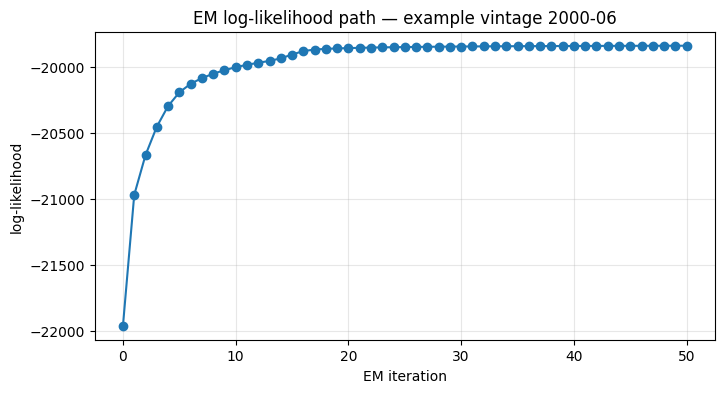

,global,demand,financial,housing,labor,prices,real_activity
1999-06,0.267771,0.160373,-0.403846,0.497268,-0.694965,0.009271,-0.465380
1999-07,0.305797,0.291495,-0.124249,0.917647,-0.535039,1.462280,-0.096350
1999-08,0.126066,0.581964,-0.217987,0.875011,-0.536779,-0.097969,-0.109489
1999-09,0.017239,-0.874887,-0.124107,0.838368,-0.465247,0.576476,-0.000778
1999-10,0.500650,0.175190,-0.196125,0.541388,-0.621055,-1.272896,0.516894
1999-11,0.395159,0.338787,0.143086,0.679750,-0.658733,-0.066100,-0.231164
1999-12,0.554623,0.352693,0.008009,0.885464,-0.635513,0.464827,-0.649437
2000-01,0.345521,-0.011459,-0.048329,0.934271,-0.467619,-0.419646,0.501978
2000-02,0.303604,-0.190674,0.241835,1.168016,-0.229434,1.864917,-0.333903
2000-03,0.242802,0.060284,0.344397,0.623349,-0.057051,0.712637,0.428313


,series,mean_used_by_model,std_used_by_model
0,RPI,0.002954,0.005333
1,W875RX1,0.002546,0.006030
2,INDPRO,0.002887,0.008737
3,IPFINAL,0.002805,0.008176
4,IPCONGD,0.002339,0.009503
5,IPMANSICS,0.003095,0.009627
6,CUMFNS,0.002016,0.774020
7,CLF16OV,0.001465,0.002861
8,UNRATE,-0.003831,0.186746
9,UEMPMEAN,-0.007460,0.488457


In [17]:

llf_path = np.array(json.loads(example_diag["llf_path_json"]))
plt.figure(figsize=(8, 4))
plt.plot(llf_path, marker="o")
plt.title(f"EM log-likelihood path — example vintage {example_vintage}")
plt.xlabel("EM iteration")
plt.ylabel("log-likelihood")
plt.grid(True, alpha=0.3)
plt.show()

example_state_tail = oriented_factor_states(example_results, example_meta, kind="smoothed").tail(12)
display(example_state_tail)

standardization_audit = pd.DataFrame(
    {
        "series": list(example_results.model._endog_mean.index),
        "mean_used_by_model": list(example_results.model._endog_mean.values),
        "std_used_by_model": list(example_results.model._endog_std.values),
    }
).head(20)
display(standardization_audit)


## 12. GDP nowcast generation

In [18]:

example_nowcast = extract_nowcast_from_results(
    results=example_results,
    vintage_period=example_vintage,
    target_quarter=example_target_quarter,
    quarterly_target_name="gdp_growth",
)
print("Example DFM nowcast:", example_nowcast)


Example DFM nowcast: 3.9641196786763593


The next cell runs the full pseudo-real-time Layer 1 loop:

1. freeze monthly vintage \(v\);
2. rebuild the GDP history visible at \(v\);
3. transform the predictor panel at \(v\);
4. estimate the DFM by EM + Kalman, warm-starting only when the parameterization matches the previous vintage;
5. compute the full-refit nowcast for the current quarter;
6. compute the pure-data news revision relative to the previous vintage under fixed previous-vintage parameters, and store any residual full-refit re-estimation effect separately;
7. export Layer 2 artifacts, excluding unsafe same-\(	au\) residual lags unless a release calendar has been implemented explicitly.

In [19]:
outputs = run_layer1_dfm(config)

nowcasts_df = outputs["nowcasts"]
states_df = outputs["states"]
news_series_df = outputs["news_series"]
news_blocks_df = outputs["news_blocks"]
coverage_df = outputs["coverage"]
diagnostics_df = outputs["diagnostics"]
layer2_design_df = outputs.get("layer2_design", pd.DataFrame())
layer2_feature_manifest_df = outputs.get("layer2_feature_manifest", pd.DataFrame())
layer2_data_contract = outputs.get("layer2_data_contract", {})

display(nowcasts_df.head(10))
display(nowcasts_df.tail(10))

if isinstance(layer2_design_df, pd.DataFrame) and not layer2_design_df.empty:
    display(layer2_design_df.head(10))
if isinstance(layer2_feature_manifest_df, pd.DataFrame) and not layer2_feature_manifest_df.empty:
    display(layer2_feature_manifest_df.head(20))

/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: divide by zero encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: overflow encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/kalman_filter.py:2324: RuntimeWarning: invalid value encountered in matmul
  forecasts = d + Z @ states
/opt/anaconda3/lib/python3.13/site-packages/stats

,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,dfm_nowcast,dfm_nowcast_pure_news_fixed_params,dfm_nowcast_previous_vintage_same_target,dfm_nowcast_revision_from_previous,dfm_nowcast_revision_full_refit,dfm_nowcast_revision_reestimation_effect,dfm_nowcast_delta_from_previous_row,dfm_nowcast_delta_from_previous_row_fixed_params,monthly_snapshot_path,monthly_snapshot_source_path,observed_months_json,n_monthly_series,model_endog_mean_json,model_endog_std_json,third_release,dfm_residual_third_release,latest_rtdsm,dfm_residual_latest_rtdsm,gdpplus,dfm_residual_gdpplus
0,2000-01,2000-01-01,2000Q1,1,4.695211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,"{""RPI"": [], ""W875RX1"": [], ""INDPRO"": [], ""IPFINAL"": [], ""IPCONGD"": [], ""IPMANSICS"": [], ""CUMFNS"": [], ""CLF16OV"": [],...",44,"{""RPI"": 0.002977512942490922, ""W875RX1"": 0.002574631955697797, ""INDPRO"": 0.002863937324407872, ""IPFINAL"": 0.00279314...","{""RPI"": 0.0053524464407721465, ""W875RX1"": 0.006048160973833852, ""INDPRO"": 0.008777875281071296, ""IPFINAL"": 0.0082132...",5.4642,0.768989,1.446614,-3.248597,5.979027,1.283816
1,2000-02,2000-02-01,2000Q1,2,5.068315,5.054846,4.695211,0.359635,0.373104,0.013469,0.373104,0.359635,data/raw/Historical FRED-MD Vintages Final/2000-02.csv,data/raw/Historical FRED-MD Vintages Final/2000-02.csv,"{""RPI"": [""2000-01""], ""W875RX1"": [""2000-01""], ""INDPRO"": [""2000-01""], ""IPFINAL"": [""2000-01""], ""IPCONGD"": [""2000-01""], ...",44,"{""RPI"": 0.0029805374753030705, ""W875RX1"": 0.002578913667666663, ""INDPRO"": 0.0028724316728259507, ""IPFINAL"": 0.002797...","{""RPI"": 0.005348374970682442, ""W875RX1"": 0.006041940561677103, ""INDPRO"": 0.008771329222817486, ""IPFINAL"": 0.00821090...",5.4642,0.395885,1.446614,-3.621701,5.979027,0.910712
2,2000-03,2000-03-01,2000Q1,3,4.456250,4.442649,5.068315,-0.625667,-0.612066,0.013601,-0.612066,-0.625667,data/raw/Historical FRED-MD Vintages Final/2000-03.csv,data/raw/Historical FRED-MD Vintages Final/2000-03.csv,"{""RPI"": [""2000-01""], ""W875RX1"": [""2000-01"", ""2000-02""], ""INDPRO"": [""2000-01"", ""2000-02""], ""IPFINAL"": [""2000-01"", ""20...",44,"{""RPI"": 0.0029805374753030705, ""W875RX1"": 0.002565239327187432, ""INDPRO"": 0.0028750461781268653, ""IPFINAL"": 0.002799...","{""RPI"": 0.005348374970682442, ""W875RX1"": 0.006044751394903902, ""INDPRO"": 0.008764252325686754, ""IPFINAL"": 0.00821116...",5.4642,1.007950,1.446614,-3.009635,5.979027,1.522777
3,2000-04,2000-04-01,2000Q2,1,3.496099,3.493798,3.786240,-0.292442,-0.290141,0.002301,-0.960151,-0.962452,data/raw/Historical FRED-MD Vintages Final/2000-04.csv,data/raw/Historical FRED-MD Vintages Final/2000-04.csv,"{""RPI"": [], ""W875RX1"": [], ""INDPRO"": [], ""IPFINAL"": [], ""IPCONGD"": [], ""IPMANSICS"": [], ""CUMFNS"": [], ""CLF16OV"": [],...",44,"{""RPI"": 0.002947032345680696, ""W875RX1"": 0.00253953847167744, ""INDPRO"": 0.0028683996910502307, ""IPFINAL"": 0.00279575...","{""RPI"": 0.005349647698413724, ""W875RX1"": 0.006044197173241491, ""INDPRO"": 0.008754085034196172, ""IPFINAL"": 0.00819513...",5.6468,2.150701,7.220732,3.724633,3.179665,-0.316434
4,2000-05,2000-05-01,2000Q2,2,4.380773,4.374423,3.496099,0.878324,0.884674,0.006350,0.884674,0.878324,data/raw/Historical FRED-MD Vintages Final/2000-05.csv,data/raw/Historical FRED-MD Vintages Final/2000-05.csv,"{""RPI"": [""2000-04""], ""W875RX1"": [""2000-04""], ""INDPRO"": [""2000-04""], ""IPFINAL"": [""2000-04""], ""IPCONGD"": [""2000-04""], ...",44,"{""RPI"": 0.002953309569728121, ""W875RX1"": 0.0025493332848962992, ""INDPRO"": 0.002886165985256585, ""IPFINAL"": 0.0028087...","{""RPI"": 0.005341634377069582, ""W875RX1"": 0.006041355964368005, ""INDPRO"": 0.008748337883485996, ""IPFINAL"": 0.00818585...",5.6468,1.266027,7.220732,2.839960,3.179665,-1.201107
5,2000-06,2000-06-01,2000Q2,3,3.964783,3.966429,4.380773,-0.414344,-0.415990,-0.00164

,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,dfm_nowcast,dfm_nowcast_pure_news_fixed_params,dfm_nowcast_previous_vintage_same_target,dfm_nowcast_revision_from_previous,dfm_nowcast_revision_full_refit,dfm_nowcast_revision_reestimation_effect,dfm_nowcast_delta_from_previous_row,dfm_nowcast_delta_from_previous_row_fixed_params,monthly_snapshot_path,monthly_snapshot_source_path,observed_months_json,n_monthly_series,model_endog_mean_json,model_endog_std_json,third_release,dfm_residual_third_release,latest_rtdsm,dfm_residual_latest_rtdsm,gdpplus,dfm_residual_gdpplus
304,2025-05,2025-05-01,2025Q2,2,3.543128,3.555141,4.313114,-0.757973,-0.769986,-0.012013,-0.769986,-0.757973,data/raw/FRED-MD-MONTHLY/2025-05-MD.csv,data/raw/FRED-MD-MONTHLY/2025-05-MD.csv,"{""RPI"": [""2025-04""], ""W875RX1"": [""2025-04""], ""INDPRO"": [""2025-04""], ""IPFINAL"": [""2025-04""], ""IPCONGD"": [""2025-04""], ...",50,"{""RPI"": 0.002607900300022722, ""W875RX1"": 0.002417566543193349, ""INDPRO"": 0.0019546414470599936, ""IPFINAL"": 0.0019036...","{""RPI"": 0.011709608046097492, ""W875RX1"": 0.00611288589087289, ""INDPRO"": 0.009934824681612088, ""IPFINAL"": 0.010516526...",3.8386,0.295472,3.766786,0.223658,2.666110,-0.877019
305,2025-06,2025-06-01,2025Q2,3,3.568248,3.568504,3.543128,0.025375,0.025119,-0.000256,0.025119,0.025375,data/raw/FRED-MD-MONTHLY/2025-06-MD.csv,data/raw/FRED-MD-MONTHLY/2025-06-MD.csv,"{""RPI"": [""2025-04"", ""2025-05""], ""W875RX1"": [""2025-04"", ""2025-05""], ""INDPRO"": [""2025-04"", ""2025-05""], ""IPFINAL"": [""20...",50,"{""RPI"": 0.0025945459704563366, ""W875RX1"": 0.0024111075171746876, ""INDPRO"": 0.0019487332434463538, ""IPFINAL"": 0.00189...","{""RPI"": 0.011705117033048978, ""W875RX1"": 0.006110365044127074, ""INDPRO"": 0.009930949061539499, ""IPFINAL"": 0.01051244...",3.8386,0.270352,3.766786,0.198539,2.666110,-0.902138
306,2025-07,2025-07-01,2025Q3,1,1.985738,1.983304,2.383740,-0.400436,-0.398002,0.002433,-1.582510,-1.584943,data/raw/FRED-MD-MONTHLY/2025-07-MD.csv,data/raw/FRED-MD-MONTHLY/2025-07-MD.csv,"{""RPI"": [], ""W875RX1"": [], ""INDPRO"": [], ""IPFINAL"": [], ""IPCONGD"": [], ""IPBUSEQ"": [], ""IPMANSICS"": [], ""CUMFNS"": [],...",50,"{""RPI"": 0.0025915571029622437, ""W875RX1"": 0.0024051118152481118, ""INDPRO"": 0.0019512718849557407, ""IPFINAL"": 0.00190...","{""RPI"": 0.011698189913475132, ""W875RX1"": 0.0061085994669143814, ""INDPRO"": 0.009924420846072984, ""IPFINAL"": 0.0105077...",NaN,NaN,4.281409,2.295672,2.574683,0.588945
307,2025-08,2025-08-01,2025Q3,2,1.934031,1.929202,1.985738,-0.056536,-0.051706,0.004830,-0.051706,-0.056536,data/raw/FRED-MD-MONTHLY/2025-08-MD.csv,data/raw/FRED-MD-MONTHLY/2025-08-MD.csv,"{""RPI"": [""2025-07""], ""W875RX1"": [""2025-07""], ""INDPRO"": [""2025-07""], ""IPFINAL"": [""2025-07""], ""IPCONGD"": [""2025-07""], ...",50,"{""RPI"": 0.0025914493557222897, ""W875RX1"": 0.0024059813191703084, ""INDPRO"": 0.0019485808679396924, ""IPFINAL"": 0.00190...","{""RPI"": 0.01169062320721108, ""W875RX1"": 0.0061049207044602824, ""INDPRO"": 0.00991773805575138, ""IPFINAL"": 0.010499018...",NaN,NaN,4.281409,2.347378,2.574683,0.640651
308,2025-09,2025-09-01,2025Q3,3,1.900353,1.901934,1.934031,-0.032097,-0.033679,-0.001582,-0.033679,-0.032097,data/raw/FRED-MD-MONTHLY/2025-09-MD.csv,data/raw/FRED-MD-MONTHLY/2025-09-MD.csv,"{""RPI"": [""2025-07"", ""2025-08""], ""W875RX1"": [""2025-07"", ""2025-08""], ""INDPRO"": [""2025-07"", ""2025-08""], ""IPFINAL"": [""20...",50,"{""RPI"": 0.0026012219147347414, ""W875RX1"": 0.0024164736352592607, ""INDPRO"": 0.0019453426601527234, ""IPFINAL"": 0.00190...","{""RPI"": 0.011658587488634404, ""W875RX1"": 0.0061181765966019045, ""INDPRO"": 0.009914122953598758, ""IPFINAL"": 0.0104926...",NaN,NaN,4.281409,2.381057,2.574683,0.674330
309,2025-10,2025-10-01,2025Q4,1,2.432466,2.426053,2.923649,-0.497596,-0.491183,0.006413,0.532113,0.525700,data/raw/FRED-MD-MONTHLY/2025-10-MD.csv,data/raw/FRED-MD-MONTHLY/2025-10-MD.csv,"{""RPI"": [], 

,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,primary_target_available,third_release,dfm_residual_third_release,latest_rtdsm,dfm_residual_latest_rtdsm,gdpplus,dfm_residual_gdpplus,dfm_nowcast,dfm_nowcast_pure_news_fixed_params,dfm_nowcast_previous_vintage_same_target,dfm_nowcast_revision_from_previous,dfm_nowcast_revision_full_refit,dfm_nowcast_revision_reestimation_effect,dfm_nowcast_delta_from_previous_row,dfm_nowcast_delta_from_previous_row_fixed_params,n_monthly_series,n_monthly_obs,llf_final,em_iterations,em_convergence_delta_last,coverage__demand_orders_inventories,coverage__financial_conditions,coverage__housing_construction,coverage__labor_market,coverage__prices_inflation,coverage__real_activity_income,n_series__demand_orders_inventories,n_series__prices_inflation,n_series__real_activity_income,news_signed__demand_orders_inventories,news_signed__financial_conditions,news_signed__housing_construction,news_signed__labor_market,news_signed__prices_inflation,news_signed__quarterly_target_history,news_signed__real_activity_income,news_abs__demand_orders_inventories,news_abs__financial_conditions,news_abs__housing_construction,news_abs__labor_market,news_abs__prices_inflation,news_abs__quarterly_target_history,news_abs__real_activity_income,state__current_smoothed__global,state__current_smoothed__demand,state__current_smoothed__financial,state__current_smoothed__housing,state__current_smoothed__labor,state__current_smoothed__prices,state__current_smoothed__real_activity,state__previous_vintage_smoothed__global,state__previous_vintage_smoothed__demand,state__previous_vintage_smoothed__financial,state__previous_vintage_smoothed__housing,state__previous_vintage_smoothed__labor,state__previous_vintage_smoothed__prices,state__previous_vintage_smoothed__real_activity
0,2000-01,2000-01-01,2000Q1,1,True,5.4642,0.768989,1.446614,-3.248597,5.979027,1.283816,4.695211,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44,492,-19627.977101,73,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,6,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.477057,-0.019359,-0.141848,0.749764,-0.397458,0.578804,-0.789790,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-02,2000-02-01,2000Q1,2,True,5.4642,0.395885,1.446614,-3.621701,5.979027,0.910712,5.068315,5.054846,4.695211,0.359635,0.373104,0.013469,0.373104,0.359635,44,493,-19670.886023,44,0.000002,0.190476,0.300000,0.333333,0.333333,0.333333,0.333333,7,6,7,0.002888,0.065343,0.062908,0.172879,0.003576,-0.146963,0.099431,0.002888,0.065343,0.062908,0.172879,0.003576,0.146963,0.099431,0.656001,0.206668,-0.097533,0.815080,-0.367462,-0.447715,0.167690,0.477057,-0.019359,-0.141848,0.749764,-0.397458,0.578804,-0.789790
2,2000-03,2000-03-01,2000Q1,3,True,5.4642,1.007950,1.446614,-3.009635,5.979027,1.522777,4.456250,4.442649,5.068315,-0.625667,-0.612066,0.013601,-0.612066,-0.625667,44,494,-19710.979353,43,0.000002,0.523810,0.633333,0.666667,0.666667,0.666667,0.619048,7,6,7,-0.119985,-0.050083,0.042478,-0.290665,0.001480,NaN,-0.199727,0.119985,0.050083,0.042478,0.290665,0.001480,NaN,0.199727,0.088613,0.008626,0.107701,1.165308,-0.071883,1.842049,-0.087917,0.656001,0.206668,-0.097533,0.815080,-0.367462,-0.447715,0.167690
3,2000-04,2000-04-01,2000Q2,1,True,5.6468,2.150701,7.220732,3.724633,3.179665,-0.316434,3.496099,3.493798,3.786240,-0.292442,-0.290141,0.002301,-0.960151,-0.962452,44,495,-19758.281166,43,0.000002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7,6,7,0.005296,-0.175374,-0.310329,0.197199,0.033136,NaN,0.091293,0.005296,0.175374,0.310329,0.197199,0.033136,NaN,0.091293,-0.113705,-0.194045,0.164183,0.769428,-0.246079,0.787477,0.202172,0.088613,0.008626,0.107701,1.165308,-0.071883,1.842049,-0.087917
4,2000-05,2000-05-01,2000Q2,2,True,5.6468,1.266027,7.220732,2.839960,3.179665,-1.201107,4.380773,4.374423,3.496099,0.878324,0.884674,0.006350,0.884674,0.878324,44,496,-19795.807927,43,0.000002,0.190476,0.300000,0.333333,0.333333,0.333333,0.333333,7,6,7,-0.270642,-0.137587,0.076

,column,role,feature_group,source_artifact,dtype,nonmissing_share,included_in_training_matrix,exclusion_reason
0,vintage_period,metadata,metadata,None,period[M],1.000000,False,None
1,vintage_timestamp_start,audit_only,audit_only,None,datetime64[ns],1.000000,False,audit_only_field
2,target_quarter,metadata,metadata,None,period[Q-DEC],1.000000,False,None
3,within_quarter_origin,metadata,metadata,None,int64,1.000000,False,None
4,dfm_nowcast,feature,dfm_backbone,dfm_nowcasts.csv,float64,1.000000,True,None
5,dfm_nowcast_pure_news_fixed_params,feature,dfm_backbone,dfm_nowcasts.csv,float64,0.996815,True,None
6,dfm_nowcast_previous_vintage_same_target,feature,dfm_backbone,dfm_nowcasts.csv,float64,0.996815,True,None
7,dfm_nowcast_revision_from_previous,feature,dfm_backbone,dfm_nowcasts.csv,float64,0.996815,True,None
8,dfm_nowcast_revision_full_refit,feature,dfm_backbone,dfm_nowcasts.csv,float64,0.996815,True,None
9,dfm_nowcast_revision_reestimation_effect,feature,dfm_backbone,dfm_nowcasts.csv,float64,0.996815,True,None


In [20]:

run_validation = pd.DataFrame(
    [
        {
            "n_nowcast_rows": len(nowcasts_df),
            "n_state_rows": len(states_df),
            "n_news_series_rows": len(news_series_df),
            "n_news_block_rows": len(news_blocks_df),
            "last_vintage_period": nowcasts_df["vintage_period"].max() if len(nowcasts_df) else pd.NaT,
            "last_target_quarter": nowcasts_df["target_quarter"].max() if len(nowcasts_df) else pd.NaT,
            "any_generated_model_index": bool(diagnostics_df["model_index_generated"].fillna(False).any()) if "model_index_generated" in diagnostics_df.columns else np.nan,
        }
    ]
)
display(run_validation)

assert len(nowcasts_df) > 0, "run_layer1_dfm(config) should produce at least one nowcast row."
assert len(news_series_df) > 0, "The patched pipeline should now produce news-series rows."
assert len(news_blocks_df) > 0, "The patched pipeline should now produce block-level news rows."
if "model_index_generated" in diagnostics_df.columns:
    assert not diagnostics_df["model_index_generated"].fillna(False).any(), "No fitted vintage should fall back to a generated integer index."


,n_nowcast_rows,n_state_rows,n_news_series_rows,n_news_block_rows,last_vintage_period,last_target_quarter,any_generated_model_index
0,314,627,15594,1974,2026-02,2026Q1,False


## 13. News decomposition

In [21]:

nonempty_news_blocks = news_blocks_df.copy()
if "signed_block_news" in nonempty_news_blocks.columns:
    nonempty_news_blocks = nonempty_news_blocks.dropna(subset=["signed_block_news"], how="all")

display(nonempty_news_blocks.tail(20))
display(news_series_df.tail(20))


,impact_date,block,block_label,factor_name,signed_block_news,abs_block_news,vintage_period,target_quarter
1954,2025-12,labor_market,Labor market,labor,0.517800,0.517800,2025-11,2025Q4
1955,2025-12,prices_inflation,Prices & inflation,prices,-0.018025,0.018025,2025-11,2025Q4
1956,2025-12,demand_orders_inventories,Demand / orders / inventories,demand,-0.147730,0.147730,2025-12,2025Q4
1957,2025-12,financial_conditions,Financial conditions,financial,0.003335,0.003335,2025-12,2025Q4
1958,2025-12,labor_market,Labor market,labor,0.015883,0.015883,2025-12,2025Q4
1959,2025-12,prices_inflation,Prices & inflation,prices,0.000753,0.000753,2025-12,2025Q4
1960,2025-12,real_activity_income,Real activity & income,real_activity,-0.508772,0.508772,2025-12,2025Q4
1961,2026-03,demand_orders_inventories,Demand / orders / inventories,demand,0.068008,0.068008,2026-01,2026Q1
1962,2026-03,financial_conditions,Financial conditions,financial,-0.003233,0.003233,2026-01,2026Q1
1963,2026-03,housing_construction,Housing & construction,housing,-0.000733,0.000733,2026-01,2026Q1


,update_date,updated_variable,observed,forecast_(prev),impact_date,impacted_variable,news,weight,impact,block,block_label,factor_name,mapping_status,vintage_period,target_quarter
15574,2026-01,CUMFNS,0.397400,-0.066449,2026-03,gdp_growth,0.463849,-0.377001,-0.174872,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1
15575,2026-01,CUSR0000SAC,-0.004146,0.000425,2026-03,gdp_growth,-0.004571,-2.897866,0.013246,prices_inflation,Prices & inflation,prices,mapped_panel_series,2026-02,2026Q1
15576,2026-01,CUSR0000SAS,0.000687,-0.000036,2026-03,gdp_growth,0.000723,5.232998,0.003782,prices_inflation,Prices & inflation,prices,mapped_panel_series,2026-02,2026Q1
15577,2026-01,FEDFUNDS,-0.080000,-0.075653,2026-03,gdp_growth,-0.004347,0.161966,-0.000704,financial_conditions,Financial conditions,financial,mapped_panel_series,2026-02,2026Q1
15578,2026-01,GS10,0.070000,-0.013392,2026-03,gdp_growth,0.083392,0.133199,0.011108,financial_conditions,Financial conditions,financial,mapped_panel_series,2026-02,2026Q1
15579,2026-01,INDPRO,0.006977,0.000257,2026-03,gdp_growth,0.006721,3.801449,0.025549,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1
15580,2026-01,IPBUSEQ,0.008733,0.001851,2026-03,gdp_growth,0.006882,11.093513,0.076349,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1
15581,2026-01,IPCONGD,0.006702,-0.000143,2026-03,gdp_growth,0.006845,-22.548713,-0.154350,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1
15582,2026-01,IPFINAL,0.006844,0.001089,2026-03,gdp_growth,0.005754,-14.340255,-0.082517,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1
15583,2026-01,IPMANSICS,0.005985,0.000438,2026-03,gdp_growth,0.005547,122.611423,0.680069,real_activity_income,Real activity & income,real_activity,mapped_panel_series,2026-02,2026Q1


,impact_date,block,block_label,factor_name,signed_block_news,abs_block_news,vintage_period,target_quarter
0,2026-03,labor_market,Labor market,labor,0.358841,0.358841,2026-02,2026Q1
1,2026-03,real_activity_income,Real activity & income,real_activity,0.313661,0.313661,2026-02,2026Q1
2,2026-03,financial_conditions,Financial conditions,financial,0.044932,0.044932,2026-02,2026Q1
3,2026-03,prices_inflation,Prices & inflation,prices,0.027582,0.027582,2026-02,2026Q1
4,2026-03,demand_orders_inventories,Demand / orders / inventories,demand,0.007647,0.007647,2026-02,2026Q1
5,2026-03,housing_construction,Housing & construction,housing,-0.003471,0.003471,2026-02,2026Q1


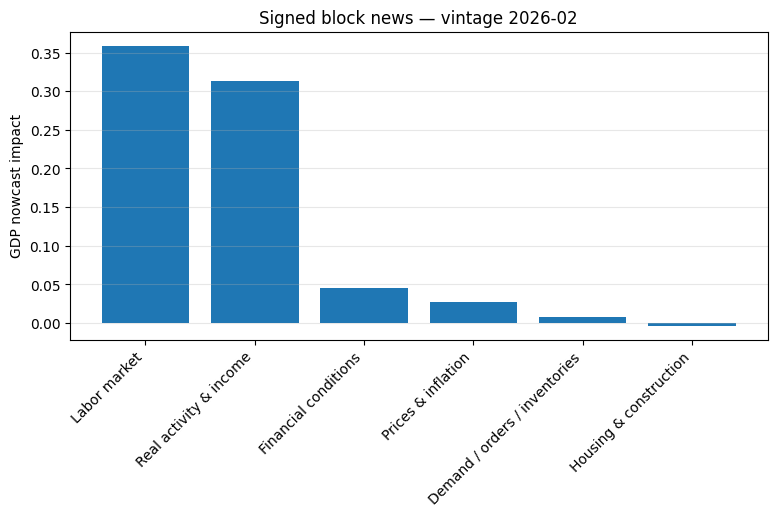

In [22]:

if not nonempty_news_blocks.empty:
    latest_news_vintage = nonempty_news_blocks["vintage_period"].dropna().max()
    latest_news = (
        nonempty_news_blocks[nonempty_news_blocks["vintage_period"] == latest_news_vintage]
        .sort_values("signed_block_news", ascending=False)
        .reset_index(drop=True)
    )
    display(latest_news)

    plt.figure(figsize=(9, 4))
    plt.bar(latest_news["block_label"].astype(str), latest_news["signed_block_news"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Signed block news — vintage {latest_news_vintage}")
    plt.ylabel("GDP nowcast impact")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
else:
    print("No non-empty news decomposition rows were produced in this run.")


## 14. Diagnostics and validation

In [23]:

diagnostic_summary = pd.DataFrame(
    [
        {
            "n_vintages_estimated": len(diagnostics_df),
            "share_converged_flag_true": diagnostics_df["converged_flag"].mean() if len(diagnostics_df) else np.nan,
            "median_em_iterations": diagnostics_df["em_iterations"].median() if len(diagnostics_df) else np.nan,
            "max_sample_end_period": diagnostics_df["sample_end_period"].max() if len(diagnostics_df) else pd.NaT,
            "share_model_index_generated_true": diagnostics_df["model_index_generated"].mean() if "model_index_generated" in diagnostics_df.columns and len(diagnostics_df) else np.nan,
        }
    ]
)
display(diagnostic_summary)

if {"third_release", "dfm_nowcast"}.issubset(nowcasts_df.columns):
    eval_df = nowcasts_df.dropna(subset=["third_release", "dfm_nowcast"]).copy()
    if len(eval_df):
        overall_rmsfe = np.sqrt(np.mean((eval_df["third_release"] - eval_df["dfm_nowcast"]) ** 2))
        rmsfe_by_tau = (
            eval_df.groupby("within_quarter_origin")
            .apply(lambda x: np.sqrt(np.mean((x["third_release"] - x["dfm_nowcast"]) ** 2)))
            .reset_index(name="rmsfe")
        )
        display(pd.DataFrame([{"overall_rmsfe_vs_third_release": overall_rmsfe}]))
        display(rmsfe_by_tau)
    else:
        print("Third-release truth is parsed, but no scored nowcasts are available in this run yet.")
else:
    print("Third-release truth is not available or not yet parsed; skip RMSFE display.")


,n_vintages_estimated,share_converged_flag_true,median_em_iterations,max_sample_end_period,share_model_index_generated_true
0,314,1.0,41.0,2026-01,0.0


,overall_rmsfe_vs_third_release
0,3.346038


,within_quarter_origin,rmsfe
0,1,3.827376
1,2,2.893080
2,3,3.251028


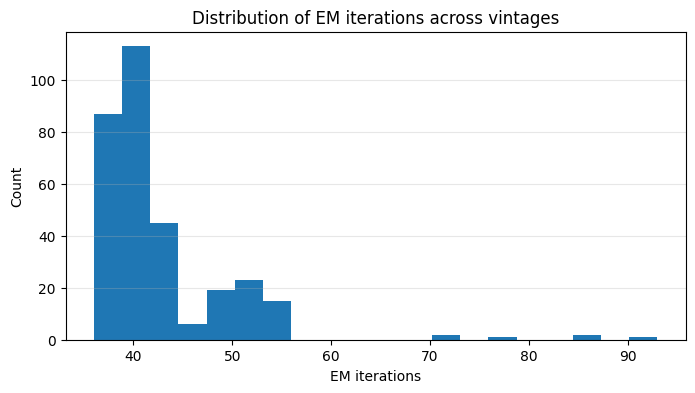

,within_quarter_origin,block_label,coverage
0,1,Demand / orders / inventories,0.000000
1,1,Financial conditions,0.000000
2,1,Housing & construction,0.000000
3,1,Labor market,0.000000
4,1,Prices & inflation,0.000000
5,1,Real activity & income,0.000000
6,2,Demand / orders / inventories,0.170005
7,2,Financial conditions,0.299683
8,2,Housing & construction,0.321164
9,2,Labor market,0.330556


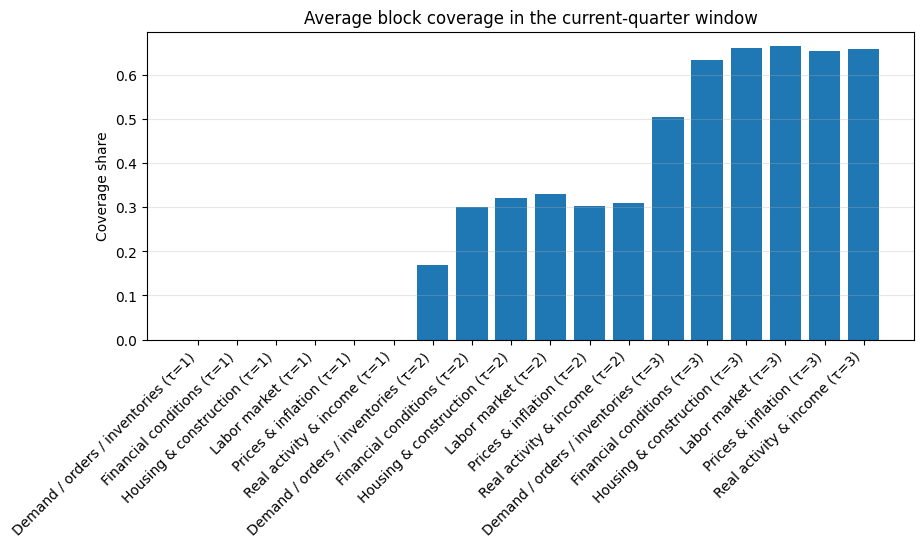

In [24]:
if len(diagnostics_df):
    plt.figure(figsize=(8, 4))
    plt.hist(diagnostics_df["em_iterations"].dropna(), bins=min(20, max(5, diagnostics_df["em_iterations"].nunique())))
    plt.title("Distribution of EM iterations across vintages")
    plt.xlabel("EM iterations")
    plt.ylabel("Count")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

if len(coverage_df) and "coverage" in coverage_df.columns:
    coverage_plot_df = coverage_df.copy()

    if "within_quarter_origin" not in coverage_plot_df.columns:
        if "vintage_period" in coverage_plot_df.columns:
            coverage_plot_df["within_quarter_origin"] = coverage_plot_df["vintage_period"].apply(within_quarter_origin)
        elif "vintage_timestamp_start" in coverage_plot_df.columns:
            coverage_plot_df["within_quarter_origin"] = (
                pd.PeriodIndex(pd.to_datetime(coverage_plot_df["vintage_timestamp_start"]), freq="M")
                .month.map(lambda m: ((int(m) - 1) % 3) + 1)
            )
        else:
            coverage_plot_df["within_quarter_origin"] = "all"

    if "block_label" not in coverage_plot_df.columns:
        fallback_block_cols = [
            "block",
            "block_name",
            "factor_block",
            "series_block",
            "group",
            "category",
        ]
        matched_block_col = next((c for c in fallback_block_cols if c in coverage_plot_df.columns), None)
        if matched_block_col is not None:
            coverage_plot_df["block_label"] = coverage_plot_df[matched_block_col].astype(str)
        else:
            coverage_plot_df["block_label"] = "all"

    avg_coverage = (
        coverage_plot_df.groupby(["within_quarter_origin", "block_label"], dropna=False)["coverage"]
        .mean()
        .reset_index()
        .sort_values(["within_quarter_origin", "block_label"])
    )
    display(avg_coverage.head(20))

    coverage_bar_df = avg_coverage.copy()
    if coverage_bar_df["within_quarter_origin"].nunique() > 1:
        coverage_bar_df["block_label_plot"] = (
            coverage_bar_df["block_label"].astype(str)
            + " (τ="
            + coverage_bar_df["within_quarter_origin"].astype(str)
            + ")"
        )
    else:
        coverage_bar_df["block_label_plot"] = coverage_bar_df["block_label"].astype(str)

    plt.figure(figsize=(max(9, 0.55 * len(coverage_bar_df)), 4))
    plt.bar(coverage_bar_df["block_label_plot"], coverage_bar_df["coverage"])
    plt.xticks(rotation=45, ha="right")
    plt.title("Average block coverage in the current-quarter window")
    plt.ylabel("Coverage share")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
else:
    print("coverage_df is empty or does not contain a 'coverage' column.")



## 15. Artifact export for Layer 2

In [25]:
artifact_check = completion_checklist_frame(OUTPUT_DIR)
display(artifact_check)

artifact_purpose = pd.DataFrame(
    [
        {"artifact": "layer1_protocol.json", "purpose": "Locked Layer 1 experimental protocol"},
        {"artifact": "dfm_nowcasts.csv", "purpose": "Vintage-level DFM nowcasts, pure-news revisions, full-refit revisions, and residual targets (unsafe same-tau residual lags intentionally omitted)"},
        {"artifact": "dfm_states.parquet|csv", "purpose": "Current and lagged oriented, standardized factor states"},
        {"artifact": "dfm_news_series.csv", "purpose": "Series-level pure-news decomposition under fixed previous-vintage parameters with explicit mapping_status labels"},
        {"artifact": "dfm_news_blocks.csv", "purpose": "Block-level signed and absolute pure-news decomposition with explicit quarterly_target_history labeling and no null-named blocks"},
        {"artifact": "dfm_coverage.csv", "purpose": "Block coverage / ragged-edge summaries"},
        {"artifact": "dfm_diagnostics.csv", "purpose": "EM convergence and model diagnostics using the actual fit_em stopping rule"},
        {"artifact": "layer2_residual_design.parquet|csv", "purpose": "Canonical Layer 2 residual-correction design table with safe metadata, targets, and whitelisted feature families"},
        {"artifact": "layer2_feature_manifest.csv", "purpose": "Per-column Layer 2 role manifest, inclusion flags, non-missing shares, and exclusion reasons"},
        {"artifact": "layer2_data_contract.json", "purpose": "Machine-readable Layer 2 handoff contract: row grain, keys, targets, feature families, forbidden columns, and preprocessing requirements"},
        {"artifact": "vintage_manifest_monthly.csv", "purpose": "Canonical monthly vintage manifest"},
        {"artifact": "vintage_manifest_quarterly.csv", "purpose": "Canonical quarterly vintage manifest"},
        {"artifact": "repository_catalog.csv", "purpose": "Repository-wide audit table"},
    ]
)
display(artifact_purpose)

,artifact,exists,resolved_path,size_bytes
0,layer1_protocol.json,True,layer1_protocol.json,972
1,dfm_nowcasts.csv,True,dfm_nowcasts.csv,1698384
2,dfm_states.parquet|csv,True,dfm_states.parquet,35106
3,dfm_news_series.csv,True,dfm_news_series.csv,3486882
4,dfm_news_blocks.csv,True,dfm_news_blocks.csv,226304
5,dfm_coverage.csv,True,dfm_coverage.csv,150945
6,dfm_diagnostics.csv,True,dfm_diagnostics.csv,327922
7,layer2_residual_design.parquet|csv,True,layer2_residual_design.parquet,170543
8,layer2_feature_manifest.csv,True,layer2_feature_manifest.csv,6233
9,layer2_data_contract.json,True,layer2_data_contract.json,6184


,artifact,purpose
0,layer1_protocol.json,Locked Layer 1 experimental protocol
1,dfm_nowcasts.csv,"Vintage-level DFM nowcasts, pure-news revisions, full-refit revisions, and residual targets (unsafe same-tau residua..."
2,dfm_states.parquet|csv,"Current and lagged oriented, standardized factor states"
3,dfm_news_series.csv,Series-level pure-news decomposition under fixed previous-vintage parameters with explicit mapping_status labels
4,dfm_news_blocks.csv,Block-level signed and absolute pure-news decomposition with explicit quarterly_target_history labeling and no null-...
5,dfm_coverage.csv,Block coverage / ragged-edge summaries
6,dfm_diagnostics.csv,EM convergence and model diagnostics using the actual fit_em stopping rule
7,layer2_residual_design.parquet|csv,"Canonical Layer 2 residual-correction design table with safe metadata, targets, and whitelisted feature families"
8,layer2_feature_manifest.csv,"Per-column Layer 2 role manifest, inclusion flags, non-missing shares, and exclusion reasons"
9,layer2_data_contract.json,"Machine-readable Layer 2 handoff contract: row grain, keys, targets, feature families, forbidden columns, and prepro..."


## 16. Final completion checklist

In [26]:

task_checklist = pd.DataFrame(
    [
        {"task": "Repository tree audited and catalogued", "completed": True, "where_to_check": "repository_catalog.csv and Sections 2–3"},
        {"task": "Monthly and quarterly date conventions audited from actual files", "completed": True, "where_to_check": "Section 5 date audit tables"},
        {"task": "Vintage-aware target history constructed from RTDSM workbook", "completed": True, "where_to_check": "Section 6 and target_vintage_table"},
        {"task": "Main truth table separated from vintage target history", "completed": True, "where_to_check": "truth_third_release / truth_latest / truth_gdpplus"},
        {"task": "Monthly predictor vintages ingested from actual CSV files", "completed": True, "where_to_check": "Sections 2, 3, and 7"},
        {"task": "Official transformations applied before standardization", "completed": True, "where_to_check": "Section 8"},
        {"task": "Statsmodels internal prediction index audited on the actual model object", "completed": True, "where_to_check": "Example index audit and diagnostics_df model_index_* columns"},
        {"task": "Mixed-frequency DFM estimated in state-space form", "completed": True, "where_to_check": "Sections 10–12"},
        {"task": "News decomposition produced", "completed": True, "where_to_check": "Section 13 and dfm_news_*.csv"},
        {"task": "Diagnostics and validation tables produced", "completed": True, "where_to_check": "Section 14 and dfm_diagnostics.csv"},
        {"task": "Layer 2 artifacts exported", "completed": True, "where_to_check": "Section 15 and outputs/layer1_dfm"},
    ]
)
display(task_checklist)


,task,completed,where_to_check
0,Repository tree audited and catalogued,True,repository_catalog.csv and Sections 2–3
1,Monthly and quarterly date conventions audited from actual files,True,Section 5 date audit tables
2,Vintage-aware target history constructed from RTDSM workbook,True,Section 6 and target_vintage_table
3,Main truth table separated from vintage target history,True,truth_third_release / truth_latest / truth_gdpplus
4,Monthly predictor vintages ingested from actual CSV files,True,"Sections 2, 3, and 7"
5,Official transformations applied before standardization,True,Section 8
6,Statsmodels internal prediction index audited on the actual model object,True,Example index audit and diagnostics_df model_index_* columns
7,Mixed-frequency DFM estimated in state-space form,True,Sections 10–12
8,News decomposition produced,True,Section 13 and dfm_news_*.csv
9,Diagnostics and validation tables produced,True,Section 14 and dfm_diagnostics.csv


## 18. Layer 1 validation and Layer 2 readiness audit

This section is an **append-only validation extension**. It does not alter any Layer 1 logic above.

Validation priorities:

- preserve the repository's **first-day-of-month / first-day-of-quarter** semantics;
- audit **repository integrity, date parsing, vintage timing, leakage safety, preprocessing, mixed-frequency alignment, estimation stability, internal consistency, performance, and Layer 2 readiness**;
- **reuse existing in-memory objects when available** and otherwise fall back to exported Layer 1 artifacts;
- **fail loudly** on missing critical artifacts rather than silently fabricating values.

The validation artifacts generated below are exported to:

`outputs/layer1_dfm/validation/`

In [27]:

import json
import math
import re
import warnings
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Re-import helper functions if the earlier notebook state is unavailable.
if "locate_repo_root" not in globals():
    try:
        import dfm_layer1_utils as _validation_utils
    except ImportError:
        import dfm_layer1_utils_1 as _validation_utils

    _VALIDATION_HELPER_EXPORTS = [
        "apply_tcodes_to_snapshot",
        "as_model_index",
        "build_observed_months_by_series",
        "build_layer2_residual_design",
        "export_layer2_handoff_package",
        "build_quarterly_target_series_for_vintage",
        "build_target_and_truth_objects",
        "choose_canonical_md_manifest",
        "choose_canonical_qd_manifest",
        "build_repo_catalog",
        "get_quarter_end_month",
        "infer_period_frequency_from_values",
        "inspect_csv_schema",
        "load_fred_snapshot",
        "locate_repo_root",
        "parse_periodish",
        "prepare_mixed_frequency_model_inputs",
        "quarter_of_vintage",
        "select_monthly_panel",
        "stable_subset_metadata",
        "within_quarter_origin",
    ]
    globals().update({name: getattr(_validation_utils, name) for name in _VALIDATION_HELPER_EXPORTS})

VALIDATION_SECTION_TITLE = "Layer 1 validation and Layer 2 readiness audit"

def _display_note(text: str) -> None:
    display(Markdown(text))

def _safe_period(value: Any, freq_hint: Optional[str] = None):
    if isinstance(value, pd.Period):
        if freq_hint is None:
            return value
        return value.asfreq(freq_hint)
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return pd.NaT

    text = str(value).strip()
    if text == "":
        return pd.NaT

    # Guard against helper-side vintage regexes that can interpret plain YYYY-MM
    # strings as quarter-coded RTDSM vintages. For exported Layer 1 CSV artifacts,
    # explicit monthly / quarterly parsing should take precedence.
    if freq_hint == "M":
        if re.fullmatch(r"\d{4}-\d{2}", text):
            return pd.Period(text, freq="M")
        if re.fullmatch(r"\d{4}-\d{2}-\d{2}", text):
            ts = pd.to_datetime(text, errors="coerce")
            return ts.to_period("M") if pd.notna(ts) else pd.NaT
    if freq_hint == "Q":
        if re.fullmatch(r"\d{4}Q[1-4]", text):
            return pd.Period(text, freq="Q")
        if re.fullmatch(r"\d{4}-\d{2}-\d{2}", text):
            ts = pd.to_datetime(text, errors="coerce")
            return ts.to_period("Q") if pd.notna(ts) else pd.NaT

    try:
        parsed = parse_periodish(value, freq_hint=freq_hint)
        return parsed if parsed is not None else pd.NaT
    except Exception:
        return pd.NaT

def _period_series(values: pd.Series, freq_hint: Optional[str]) -> pd.Series:
    return values.map(lambda x: _safe_period(x, freq_hint=freq_hint))

def _ensure_period_columns(df: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    out = df.copy()
    for col, freq in mapping.items():
        if col in out.columns:
            out[col] = _period_series(out[col], freq)
    return out

def _json_loads_or_empty(value: Any) -> Dict[str, Any]:
    if isinstance(value, dict):
        return value
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return {}
    try:
        obj = json.loads(value)
        return obj if isinstance(obj, dict) else {}
    except Exception:
        return {}

def _to_month_start_timestamp(value: Any) -> pd.Timestamp:
    if isinstance(value, pd.Period):
        return value.asfreq("M").to_timestamp(how="start")
    ts = pd.to_datetime(value, errors="coerce")
    if pd.isna(ts):
        return pd.NaT
    return pd.Timestamp(ts).normalize()

def _period_minus_one_month(value: pd.Period) -> pd.Period:
    if pd.isna(value):
        return pd.NaT
    if not isinstance(value, pd.Period):
        value = _safe_period(value, "M")
    return value - 1

def _max_closed_quarter_from_sample_end(sample_end_period: pd.Period) -> pd.Period:
    if pd.isna(sample_end_period):
        return pd.NaT
    q = sample_end_period.asfreq("Q")
    if get_quarter_end_month(q) > sample_end_period:
        q = q - 1
    return q

def _export_frame(df: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    out = df.copy()
    for col in out.columns:
        sample = out[col].dropna()
        first = sample.iloc[0] if len(sample) else None
        if isinstance(first, pd.Period):
            out[col] = out[col].map(lambda x: str(x) if isinstance(x, pd.Period) else ("" if pd.isna(x) else x))
        elif isinstance(first, pd.Timestamp):
            out[col] = pd.to_datetime(out[col], errors="coerce").dt.strftime("%Y-%m-%d")
        elif pd.api.types.is_datetime64_any_dtype(out[col]):
            out[col] = pd.to_datetime(out[col], errors="coerce").dt.strftime("%Y-%m-%d")
    out.to_csv(path, index=False)

def _json_safe(obj: Any) -> Any:
    if isinstance(obj, pd.Period):
        return str(obj)
    if isinstance(obj, pd.Timestamp):
        return obj.strftime("%Y-%m-%d")
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return None if np.isnan(obj) else float(obj)
    if isinstance(obj, np.bool_):
        return bool(obj)
    if isinstance(obj, dict):
        return {str(k): _json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_json_safe(v) for v in obj]
    return obj

def _export_json(obj: Dict[str, Any], path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(obj), f, indent=2, ensure_ascii=False)

def _load_global_or_export(
    var_name: str,
    path: Path,
    reader,
    required: bool = False,
):
    if var_name in globals() and globals()[var_name] is not None:
        obj = globals()[var_name]
        if isinstance(obj, pd.DataFrame):
            return obj.copy()
        return obj
    if path.exists():
        return reader(path)
    if required:
        raise FileNotFoundError(f"Required validation input is missing: {path}")
    return None

def _parse_vintage_from_snapshot_path(path_like: Any) -> pd.Period:
    if path_like is None or (isinstance(path_like, float) and np.isnan(path_like)):
        return pd.NaT
    name = Path(str(path_like)).stem
    tokens = [name, name.replace("-MD", ""), name.replace("-QD", "")]
    for token in tokens:
        parsed = _safe_period(token, "M")
        if isinstance(parsed, pd.Period):
            return parsed
    match = pd.Series([name]).str.extract(r"(\d{4}-\d{2})").iloc[0, 0]
    return _safe_period(match, "M")

def _pick_representative_periods(periods: Iterable[pd.Period], max_count: int = 6) -> List[pd.Period]:
    uniq = pd.Index(sorted({p for p in periods if isinstance(p, pd.Period) and not pd.isna(p)}))
    if len(uniq) == 0:
        return []
    if len(uniq) <= max_count:
        return list(uniq)
    positions = sorted(set(np.linspace(0, len(uniq) - 1, num=max_count, dtype=int)))
    return [uniq[i] for i in positions]

validation_checks: List[Dict[str, Any]] = []

def add_check(
    check_id: str,
    area: str,
    severity: str,
    passed: bool,
    weight: float,
    message: str,
    details: Optional[str] = None,
    remediation: Optional[str] = None,
) -> None:
    validation_checks.append(
        {
            "check_id": check_id,
            "area": area,
            "severity": severity,
            "passed": bool(passed),
            "weight": float(weight),
            "score_awarded": float(weight) if passed else 0.0,
            "message": message,
            "details": details,
            "remediation": remediation,
        }
    )

# Resolve runtime paths and load the current Layer 1 outputs.
REPO_ROOT_VALIDATION = Path(REPO_ROOT) if "REPO_ROOT" in globals() else locate_repo_root(Path.cwd())
OUTPUT_DIR_VALIDATION = Path(OUTPUT_DIR) if "OUTPUT_DIR" in globals() else REPO_ROOT_VALIDATION / "outputs" / "layer1_dfm"
VALIDATION_DIR = OUTPUT_DIR_VALIDATION / "validation"
VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

required_exports = {
    "nowcasts": OUTPUT_DIR_VALIDATION / "dfm_nowcasts.csv",
    "diagnostics": OUTPUT_DIR_VALIDATION / "dfm_diagnostics.csv",
    "news_blocks": OUTPUT_DIR_VALIDATION / "dfm_news_blocks.csv",
    "news_series": OUTPUT_DIR_VALIDATION / "dfm_news_series.csv",
    "coverage": OUTPUT_DIR_VALIDATION / "dfm_coverage.csv",
    "md_manifest": OUTPUT_DIR_VALIDATION / "vintage_manifest_monthly.csv",
    "qd_manifest": OUTPUT_DIR_VALIDATION / "vintage_manifest_quarterly.csv",
    "catalog": OUTPUT_DIR_VALIDATION / "repository_catalog.csv",
    "protocol": OUTPUT_DIR_VALIDATION / "layer1_protocol.json",
    "states_parquet": OUTPUT_DIR_VALIDATION / "dfm_states.parquet",
}

nowcasts_df = _load_global_or_export("nowcasts_df", required_exports["nowcasts"], pd.read_csv, required=True)
diagnostics_df = _load_global_or_export("diagnostics_df", required_exports["diagnostics"], pd.read_csv, required=True)
news_blocks_df = _load_global_or_export("news_blocks_df", required_exports["news_blocks"], pd.read_csv, required=True)
news_series_df = _load_global_or_export("news_series_df", required_exports["news_series"], pd.read_csv, required=True)
coverage_df = _load_global_or_export("coverage_df", required_exports["coverage"], pd.read_csv, required=True)
md_manifest = _load_global_or_export("md_manifest", required_exports["md_manifest"], pd.read_csv, required=True)
qd_manifest = _load_global_or_export("qd_manifest", required_exports["qd_manifest"], pd.read_csv, required=True)
catalog = _load_global_or_export("catalog", required_exports["catalog"], pd.read_csv, required=True)

protocol = None
if required_exports["protocol"].exists():
    with open(required_exports["protocol"], "r", encoding="utf-8") as f:
        protocol = json.load(f)

states_df = None
if "states_df" in globals() and globals()["states_df"] is not None:
    states_df = globals()["states_df"].copy()
elif required_exports["states_parquet"].exists():
    try:
        states_df = pd.read_parquet(required_exports["states_parquet"])
    except Exception as err:
        warnings.warn(f"Could not read dfm_states.parquet during validation: {err}")

target_objects_local = None
if "target_objects" in globals() and globals()["target_objects"] is not None:
    target_objects_local = globals()["target_objects"]
else:
    try:
        target_objects_local = build_target_and_truth_objects(REPO_ROOT_VALIDATION)
    except Exception as err:
        warnings.warn(f"Could not rebuild target/truth objects inside validation section: {err}")
        target_objects_local = {}

nowcasts_df = _ensure_period_columns(
    nowcasts_df,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
    },
)
diagnostics_df = _ensure_period_columns(
    diagnostics_df,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
        "sample_end_period": "M",
    },
)
coverage_df = _ensure_period_columns(
    coverage_df,
    {"vintage_period": "M", "target_quarter": "Q"},
)
news_blocks_df = _ensure_period_columns(
    news_blocks_df,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
        "impact_date": "M",
    },
)
news_series_df = _ensure_period_columns(
    news_series_df,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
        "update_date": "M",
        "impact_date": "M",
    },
)
md_manifest = _ensure_period_columns(md_manifest, {"vintage_period": "M"})
qd_manifest = _ensure_period_columns(qd_manifest, {"vintage_period": "M"})
catalog = _ensure_period_columns(catalog, {"vintage_period": "M"})

stable_meta = stable_subset_metadata().copy()
stable_block_counts = stable_meta.groupby("block")["mnemonic"].nunique().rename("stable_n_series").reset_index()

runtime_summary = pd.DataFrame(
    [
        {"object": "REPO_ROOT_VALIDATION", "value": str(REPO_ROOT_VALIDATION)},
        {"object": "OUTPUT_DIR_VALIDATION", "value": str(OUTPUT_DIR_VALIDATION)},
        {"object": "VALIDATION_DIR", "value": str(VALIDATION_DIR)},
        {"object": "n_nowcasts", "value": len(nowcasts_df)},
        {"object": "n_diagnostics", "value": len(diagnostics_df)},
        {"object": "n_news_blocks", "value": len(news_blocks_df)},
        {"object": "n_news_series", "value": len(news_series_df)},
        {"object": "n_coverage_rows", "value": len(coverage_df)},
        {"object": "states_loaded", "value": states_df is not None},
        {"object": "target_objects_loaded", "value": bool(target_objects_local)},
    ]
)
display(runtime_summary)

# Required artifact existence check.
for artifact_name, artifact_path in required_exports.items():
    if artifact_name == "states_parquet":
        add_check(
            f"artifact_exists__{artifact_name}",
            area="repository_integrity",
            severity="major",
            passed=artifact_path.exists(),
            weight=4.0,
            message=f"Artifact {artifact_name} exists at the expected Layer 1 path.",
            details=str(artifact_path),
            remediation="Re-run Layer 1 artifact export and confirm dfm_states.parquet is written to outputs/layer1_dfm.",
        )
    elif artifact_name != "protocol":
        add_check(
            f"artifact_exists__{artifact_name}",
            area="repository_integrity",
            severity="critical",
            passed=artifact_path.exists(),
            weight=5.0,
            message=f"Artifact {artifact_name} exists at the expected Layer 1 path.",
            details=str(artifact_path),
            remediation="Re-run Layer 1 and confirm the expected outputs/layer1_dfm artifacts are materialized.",
        )
    else:
        add_check(
            f"artifact_exists__{artifact_name}",
            area="repository_integrity",
            severity="major",
            passed=artifact_path.exists(),
            weight=3.0,
            message=f"Protocol file {artifact_name} exists.",
            details=str(artifact_path),
            remediation="Persist the exact Layer 1 protocol used for estimation.",
        )

_display_note(
    f"### {VALIDATION_SECTION_TITLE}\n"
    "This extension audits the exported Layer 1 artifacts, raw date semantics, vintage protocol, "
    "mixed-frequency alignment, DFM estimation stability, pseudo-real-time performance, and Layer 2 readiness. "
    "All checks preserve the repository's first-day-of-period convention."
)


,object,value
0,REPO_ROOT_VALIDATION,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
1,OUTPUT_DIR_VALIDATION,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
2,VALIDATION_DIR,/Users/haaminh109/Desktop/Minh/Tài liệu học tập (DSEB)/Kì 6/Time Series/Final Project/Test/hybrid_dfm_ml_nowc...
3,n_nowcasts,314
4,n_diagnostics,314
5,n_news_blocks,1974
6,n_news_series,15594
7,n_coverage_rows,1884
8,states_loaded,True
9,target_objects_loaded,True


### Layer 1 validation and Layer 2 readiness audit
This extension audits the exported Layer 1 artifacts, raw date semantics, vintage protocol, mixed-frequency alignment, DFM estimation stability, pseudo-real-time performance, and Layer 2 readiness. All checks preserve the repository's first-day-of-period convention.

## 19. Data integrity and date-convention checks

This section validates:

- required Layer 1 output artifacts and protocol provenance;
- representative raw monthly and quarterly files;
- raw date columns, inferred frequencies, and max/min periods;
- whether any exported timestamps drifted to month-end or quarter-end;
- whether the final estimated vintage is capped by **actual available data**, not by assumed future periods.

In [28]:

# Representative raw-file inspection: first, middle, and last available monthly and quarterly vintages.
def _representative_manifest_rows(manifest: pd.DataFrame, max_count: int = 3) -> pd.DataFrame:
    if manifest.empty:
        return manifest.copy()
    manifest = manifest.sort_values("vintage_period").reset_index(drop=True)
    positions = sorted(set(np.linspace(0, len(manifest) - 1, num=min(max_count, len(manifest)), dtype=int)))
    return manifest.iloc[positions].copy()

date_audit_rows: List[Dict[str, Any]] = []

for freq_label, manifest in [("M", md_manifest), ("Q", qd_manifest)]:
    manifest_examples = _representative_manifest_rows(manifest, max_count=3)
    for _, row in manifest_examples.iterrows():
        raw_path = REPO_ROOT_VALIDATION / row["path"]
        record: Dict[str, Any] = {
            "source_family": "monthly_raw" if freq_label == "M" else "quarterly_raw",
            "manifest_vintage_period": row.get("vintage_period", pd.NaT),
            "path": str(row["path"]),
            "path_exists": raw_path.exists(),
        }
        if raw_path.exists():
            schema = inspect_csv_schema(raw_path)
            record.update(
                {
                    "date_col": schema.get("date_col"),
                    "metadata_row_count": schema.get("metadata_row_count"),
                    "has_tcode_row": schema.get("has_tcode_row"),
                    "inferred_freq": schema.get("inferred_freq"),
                    "min_timestamp_start": schema.get("min_timestamp"),
                    "max_timestamp_start": schema.get("max_timestamp"),
                    "max_timestamp_day": (
                        pd.Timestamp(schema.get("max_timestamp")).day
                        if pd.notna(schema.get("max_timestamp"))
                        else np.nan
                    ),
                    "max_period_from_raw": (
                        pd.Period(schema.get("max_timestamp"), freq="M" if freq_label == "M" else "Q")
                        if pd.notna(schema.get("max_timestamp"))
                        else pd.NaT
                    ),
                }
            )
            expected_max = (
                row["vintage_period"] - 1
                if freq_label == "M"
                else _max_closed_quarter_from_sample_end(row["vintage_period"] - 1)
            )
            record["expected_max_period_from_vintage"] = expected_max
            record["max_matches_expected"] = record["max_period_from_raw"] == expected_max
            record["suspicious_month_end_coercion"] = bool(
                pd.notna(schema.get("max_timestamp")) and pd.Timestamp(schema.get("max_timestamp")).day != 1
            )
        else:
            record.update(
                {
                    "date_col": None,
                    "metadata_row_count": np.nan,
                    "has_tcode_row": np.nan,
                    "inferred_freq": None,
                    "min_timestamp_start": pd.NaT,
                    "max_timestamp_start": pd.NaT,
                    "max_timestamp_day": np.nan,
                    "max_period_from_raw": pd.NaT,
                    "expected_max_period_from_vintage": row.get("vintage_period", pd.NaT) - 1 if isinstance(row.get("vintage_period"), pd.Period) else pd.NaT,
                    "max_matches_expected": False,
                    "suspicious_month_end_coercion": np.nan,
                }
            )
        date_audit_rows.append(record)

# Exported-artifact date columns should also preserve first-of-period timestamps.
for label, df in [
    ("nowcasts", nowcasts_df),
    ("diagnostics", diagnostics_df),
    ("md_manifest", md_manifest),
    ("qd_manifest", qd_manifest),
]:
    for col in [c for c in df.columns if "timestamp" in c]:
        ts = pd.to_datetime(df[col], errors="coerce")
        if ts.notna().any():
            date_audit_rows.append(
                {
                    "source_family": f"artifact::{label}",
                    "manifest_vintage_period": pd.NaT,
                    "path": f"{label}.{col}",
                    "path_exists": True,
                    "date_col": col,
                    "metadata_row_count": np.nan,
                    "has_tcode_row": np.nan,
                    "inferred_freq": "timestamp_start",
                    "min_timestamp_start": ts.min(),
                    "max_timestamp_start": ts.max(),
                    "max_timestamp_day": ts.max().day if pd.notna(ts.max()) else np.nan,
                    "max_period_from_raw": pd.NaT,
                    "expected_max_period_from_vintage": pd.NaT,
                    "max_matches_expected": np.nan,
                    "suspicious_month_end_coercion": bool((ts.dropna().dt.day != 1).any()),
                }
            )

date_convention_audit = pd.DataFrame(date_audit_rows)
date_convention_audit["manifest_vintage_period"] = _period_series(date_convention_audit["manifest_vintage_period"], "M")
_export_frame(date_convention_audit, VALIDATION_DIR / "date_convention_audit.csv")

latest_available_monthly_vintage = md_manifest["vintage_period"].dropna().max() if len(md_manifest) else pd.NaT
latest_available_quarterly_vintage = qd_manifest["vintage_period"].dropna().max() if len(qd_manifest) else pd.NaT
latest_available_target_vintage = (
    target_objects_local.get("target_vintage_table", pd.DataFrame()).get("vintage_period").dropna().max()
    if isinstance(target_objects_local.get("target_vintage_table"), pd.DataFrame) and "vintage_period" in target_objects_local.get("target_vintage_table").columns
    else pd.NaT
)
final_estimated_vintage = nowcasts_df["vintage_period"].dropna().max() if len(nowcasts_df) else pd.NaT

add_check(
    "date_semantics__raw_files_infer_expected_frequency",
    area="date_convention",
    severity="critical",
    passed=bool(
        len(date_convention_audit.query("source_family in ['monthly_raw', 'quarterly_raw']")) > 0
        and date_convention_audit.loc[date_convention_audit["source_family"] == "monthly_raw", "inferred_freq"].eq("M").all()
        and date_convention_audit.loc[date_convention_audit["source_family"] == "quarterly_raw", "inferred_freq"].eq("Q").all()
    ),
    weight=7.0,
    message="Representative monthly and quarterly raw files infer the expected calendar frequencies from first-of-period date strings.",
    details="The audit inspects the raw date column, metadata rows, inferred frequency, and raw min/max timestamps.",
    remediation="Fix raw date parsing so monthly files map to PeriodIndex('M') and quarterly files map to PeriodIndex('Q') before any downstream transformation.",
)

add_check(
    "date_semantics__no_month_end_drift_in_audit",
    area="date_convention",
    severity="critical",
    passed=not bool(date_convention_audit["suspicious_month_end_coercion"].fillna(False).any()),
    weight=7.0,
    message="The audit does not detect accidental month-end or quarter-end timestamp drift.",
    details="All representative raw timestamps and exported *timestamp_start columns remain aligned to the first day of the period.",
    remediation="Replace month-end coercions with Period semantics and start-of-period timestamps only.",
)

raw_match_subset = date_convention_audit[date_convention_audit["source_family"].isin(["monthly_raw", "quarterly_raw"]) & date_convention_audit["path_exists"]]
add_check(
    "date_semantics__raw_max_period_matches_vintage_cutoff",
    area="date_convention",
    severity="critical",
    passed=bool(len(raw_match_subset) > 0 and raw_match_subset["max_matches_expected"].all()),
    weight=6.0,
    message="Representative raw-file max dates match the expected vintage cutoff rather than an artificial future date.",
    details="For monthly and quarterly raw snapshots, the max observed period should be one period before the file's vintage label.",
    remediation="Review filename parsing and raw-file ingestion if any raw snapshot extends beyond its vintage boundary.",
)

cap_candidates = [p for p in [latest_available_monthly_vintage, latest_available_target_vintage] if isinstance(p, pd.Period) and not pd.isna(p)]
expected_final_vintage_cap = min(cap_candidates) if cap_candidates else latest_available_monthly_vintage
add_check(
    "integrity__final_vintage_capped_by_actual_data",
    area="repository_integrity",
    severity="critical",
    passed=(not pd.isna(expected_final_vintage_cap)) and (final_estimated_vintage <= expected_final_vintage_cap),
    weight=7.0,
    message="The final estimated vintage is capped by the actually available raw and target data.",
    details=f"Estimated final vintage={final_estimated_vintage}, expected cap={expected_final_vintage_cap}.",
    remediation="Cap the Layer 1 vintage schedule to the intersection of available monthly snapshots and available target vintages.",
)

protocol_output_dir = Path(protocol["output_dir"]) if isinstance(protocol, dict) and protocol.get("output_dir") else None
protocol_repo_root = Path(protocol["repo_root"]) if isinstance(protocol, dict) and protocol.get("repo_root") else None

add_check(
    "integrity__protocol_matches_runtime_output_dir",
    area="repository_integrity",
    severity="major",
    passed=(protocol_output_dir is None) or (protocol_output_dir.resolve() == OUTPUT_DIR_VALIDATION.resolve()),
    weight=4.0,
    message="The serialized Layer 1 protocol points to the same output directory used by the current notebook.",
    details=f"Protocol output_dir={protocol_output_dir}, runtime OUTPUT_DIR={OUTPUT_DIR_VALIDATION}.",
    remediation="Regenerate the protocol file from the current notebook configuration so provenance and actual artifact location remain synchronized.",
)

add_check(
    "integrity__protocol_matches_runtime_repo_root",
    area="repository_integrity",
    severity="major",
    passed=(protocol_repo_root is None) or (protocol_repo_root.resolve() == REPO_ROOT_VALIDATION.resolve()),
    weight=3.0,
    message="The serialized Layer 1 protocol points to the same repository root used at validation time.",
    details=f"Protocol repo_root={protocol_repo_root}, runtime REPO_ROOT={REPO_ROOT_VALIDATION}.",
    remediation="Refresh the protocol export whenever the repository root or execution environment changes.",
)

date_convention_audit.sort_values(["source_family", "manifest_vintage_period", "path"]).head(12)


,source_family,manifest_vintage_period,path,path_exists,date_col,metadata_row_count,has_tcode_row,inferred_freq,min_timestamp_start,max_timestamp_start,max_timestamp_day,max_period_from_raw,expected_max_period_from_vintage,max_matches_expected,suspicious_month_end_coercion
7,artifact::diagnostics,NaT,diagnostics.vintage_timestamp_start,True,vintage_timestamp_start,NaN,NaN,timestamp_start,2000-01-01,2026-02-01,1,NaT,NaT,NaN,False
8,artifact::md_manifest,NaT,md_manifest.vintage_timestamp_start,True,vintage_timestamp_start,NaN,NaN,timestamp_start,1999-08-01,2026-02-01,1,NaT,NaT,NaN,False
6,artifact::nowcasts,NaT,nowcasts.vintage_timestamp_start,True,vintage_timestamp_start,NaN,NaN,timestamp_start,2000-01-01,2026-02-01,1,NaT,NaT,NaN,False
9,artifact::qd_manifest,NaT,qd_manifest.vintage_timestamp_start,True,vintage_timestamp_start,NaN,NaN,timestamp_start,2018-05-01,2026-02-01,1,NaT,NaT,NaN,False
0,monthly_raw,1999-08,data/raw/Historical FRED-MD Vintages Final/1999-08.csv,True,sasdate,1.0,True,M,1959-01-01,1999-07-01,1,1999-07,1999-07,True,False
1,monthly_raw,2012-11,data/raw/Historical FRED-MD Vintages Final/2012-11.csv,True,sasdate,1.0,True,M,1959-01-01,2012-10-01,1,2012-10,2012-10,True,False
2,monthly_raw,2026-02,data/raw/FRED-MD-MONTHLY/2026-02-MD.csv,True,sasdate,1.0,True,M,1959-01-01,2026-01-01,1,2026-01,2026-01,True,False
3,quarterly_raw,2018-05,data/raw/Historical vintages of FRED-QD 2018-05 to 2024-12/FRED-QD_2018m05.csv,True,sasdate,2.0,True,Q,1959-01-01,2018-01-01,1,2018Q1,2018Q1,True,False
4,quarterly_raw,2022-03,data/raw/Historical vintages of FRED-QD 2018-05 to 2024-12/FRED-QD_2022m03.csv,True,sasdate,2.0,True,Q,1959-01-01,2021-10-01,1,2021Q4,2021Q4,True,False
5,quarterly_raw,2026-02,data/raw/FRED-QD-QUARTERLY/2026-02-QD.csv,True,sasdate,2.0,True,Q,1959-01-01,2025-10-01,1,2025Q4,2025Q4,True,False


## 20. Vintage protocol and leakage audit

This section validates, for each forecast origin:

- target-quarter assignment;
- within-quarter origin coding;
- sample-end timing relative to the vintage marker;
- snapshot-path/vintage coherence;
- current-quarter monthly observation caps;
- quarterly target leakage and explicit Layer 2 leakage risks.

In [29]:

# Vintage protocol, leakage safety, and mixed-frequency alignment.
vintage_leakage_rows: List[Dict[str, Any]] = []

now_diag = nowcasts_df.merge(
    diagnostics_df,
    on=["vintage_period", "target_quarter", "within_quarter_origin", "n_monthly_series"],
    how="left",
    suffixes=("", "_diag"),
)

target_vintage_groups: Dict[pd.Period, pd.DataFrame] = {}
if isinstance(target_objects_local.get("target_vintage_table"), pd.DataFrame) and not target_objects_local["target_vintage_table"].empty:
    tv = target_objects_local["target_vintage_table"].copy()
    tv = _ensure_period_columns(tv, {"vintage_period": "M", "obs_period": "Q"})
    target_vintage_groups = {
        v: g.sort_values("obs_period").reset_index(drop=True)
        for v, g in tv.groupby("vintage_period", sort=False)
    }

for _, row in now_diag.sort_values("vintage_period").iterrows():
    vintage = row["vintage_period"]
    target_quarter = row["target_quarter"]
    tau = row["within_quarter_origin"]
    expected_target_quarter = quarter_of_vintage(vintage) if isinstance(vintage, pd.Period) else pd.NaT
    expected_tau = within_quarter_origin(vintage) if isinstance(vintage, pd.Period) else np.nan
    expected_sample_end = _period_minus_one_month(vintage) if isinstance(vintage, pd.Period) else pd.NaT
    sample_end = row.get("sample_end_period", pd.NaT)
    snapshot_vintage = _parse_vintage_from_snapshot_path(row.get("monthly_snapshot_path"))

    observed_months = _json_loads_or_empty(row.get("observed_months_json"))
    current_quarter_counts: Dict[str, int] = {k: len(v) for k, v in observed_months.items() if isinstance(v, list)}
    max_current_quarter_months_observed = max(current_quarter_counts.values()) if len(current_quarter_counts) else np.nan
    over_observed_series = sorted([k for k, v in current_quarter_counts.items() if v > max(int(tau) - 1, 0)])

    target_quarter_nonnull_asof_vintage = np.nan
    max_nonnull_target_quarter_asof_vintage = pd.NaT
    max_allowed_nonnull_target_quarter = _max_closed_quarter_from_sample_end(sample_end) if isinstance(sample_end, pd.Period) else pd.NaT
    future_nonnull_target_count = np.nan

    hist = target_vintage_groups.get(vintage)
    if hist is not None and len(hist):
        hist_nonnull = hist.loc[hist["gdp_growth_annualized"].notna(), "obs_period"]
        max_nonnull_target_quarter_asof_vintage = hist_nonnull.max() if len(hist_nonnull) else pd.NaT
        future_nonnull_target_count = int(
            hist.loc[
                hist["gdp_growth_annualized"].notna()
                & hist["obs_period"].notna()
                & (hist["obs_period"] > max_allowed_nonnull_target_quarter),
                "obs_period",
            ].shape[0]
        ) if isinstance(max_allowed_nonnull_target_quarter, pd.Period) else np.nan
        tq_match = hist.loc[hist["obs_period"] == target_quarter, "gdp_growth_annualized"]
        target_quarter_nonnull_asof_vintage = bool(tq_match.notna().any()) if len(tq_match) else False

    vintage_leakage_rows.append(
        {
            "vintage_period": vintage,
            "target_quarter": target_quarter,
            "within_quarter_origin": tau,
            "expected_target_quarter": expected_target_quarter,
            "target_quarter_matches_vintage": target_quarter == expected_target_quarter,
            "expected_within_quarter_origin": expected_tau,
            "within_quarter_origin_matches": tau == expected_tau,
            "sample_end_period": sample_end,
            "expected_sample_end_period": expected_sample_end,
            "sample_end_matches_expected": sample_end == expected_sample_end,
            "snapshot_vintage_from_path": snapshot_vintage,
            "snapshot_vintage_matches_row": snapshot_vintage == vintage,
            "max_current_quarter_months_observed": max_current_quarter_months_observed,
            "allowed_current_quarter_months": max(int(tau) - 1, 0),
            "current_quarter_observation_cap_respected": len(over_observed_series) == 0,
            "over_observed_series_count": len(over_observed_series),
            "over_observed_series_preview": ", ".join(over_observed_series[:10]),
            "target_quarter_nonnull_asof_vintage": target_quarter_nonnull_asof_vintage,
            "max_nonnull_target_quarter_asof_vintage": max_nonnull_target_quarter_asof_vintage,
            "max_allowed_nonnull_target_quarter": max_allowed_nonnull_target_quarter,
            "future_nonnull_target_count": future_nonnull_target_count,
            "no_future_target_leak": (
                True
                if pd.isna(future_nonnull_target_count)
                else int(future_nonnull_target_count) == 0
            ),
            "residual_lag1_same_tau_present": bool(pd.notna(row.get("residual_lag1_same_tau", np.nan))),
            "residual_lag2_same_tau_present": bool(pd.notna(row.get("residual_lag2_same_tau", np.nan))),
        }
    )

vintage_leakage_audit = pd.DataFrame(vintage_leakage_rows)
vintage_leakage_audit = _ensure_period_columns(
    vintage_leakage_audit,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
        "expected_target_quarter": "Q",
        "sample_end_period": "M",
        "expected_sample_end_period": "M",
        "snapshot_vintage_from_path": "M",
        "max_nonnull_target_quarter_asof_vintage": "Q",
        "max_allowed_nonnull_target_quarter": "Q",
    },
)
_export_frame(vintage_leakage_audit, VALIDATION_DIR / "vintage_leakage_audit.csv")

mixed_frequency_alignment_audit = vintage_leakage_audit[
    [
        "vintage_period",
        "target_quarter",
        "within_quarter_origin",
        "sample_end_period",
        "expected_sample_end_period",
        "target_quarter_matches_vintage",
        "within_quarter_origin_matches",
        "sample_end_matches_expected",
        "max_current_quarter_months_observed",
        "allowed_current_quarter_months",
        "current_quarter_observation_cap_respected",
        "target_quarter_nonnull_asof_vintage",
        "max_nonnull_target_quarter_asof_vintage",
        "max_allowed_nonnull_target_quarter",
        "future_nonnull_target_count",
        "no_future_target_leak",
    ]
].copy()
_export_frame(mixed_frequency_alignment_audit, VALIDATION_DIR / "mixed_frequency_alignment_audit.csv")

add_check(
    "vintage_protocol__target_quarter_mapping",
    area="vintage_protocol",
    severity="critical",
    passed=bool(vintage_leakage_audit["target_quarter_matches_vintage"].all()),
    weight=8.0,
    message="Each Layer 1 row targets the quarter implied by the monthly vintage label.",
    details="The validation compares target_quarter to quarter_of_vintage(vintage_period) for every nowcast row.",
    remediation="Correct any off-by-one-quarter mapping before using the Layer 1 outputs for residual correction.",
)

add_check(
    "vintage_protocol__within_quarter_origin_mapping",
    area="mixed_frequency_alignment",
    severity="critical",
    passed=bool(vintage_leakage_audit["within_quarter_origin_matches"].all()),
    weight=6.0,
    message="The within-quarter origin code is consistent with the monthly vintage position inside the quarter.",
    details="The validation expects tau=1,2,3 according to the month number modulo three.",
    remediation="Fix within_quarter_origin before feeding Layer 2 because the residual model will rely on this key.",
)

add_check(
    "vintage_protocol__sample_end_is_vintage_minus_one_month",
    area="vintage_protocol",
    severity="critical",
    passed=bool(vintage_leakage_audit["sample_end_matches_expected"].all()),
    weight=8.0,
    message="The model sample ends exactly one month before the vintage marker, consistent with first-of-month vintage semantics.",
    details="This check guards against accidental inclusion of contemporaneous or future monthly data.",
    remediation="Review raw-file ingestion and date parsing if any sample_end_period exceeds the permissible vintage cutoff.",
)

add_check(
    "vintage_protocol__snapshot_path_matches_vintage",
    area="vintage_protocol",
    severity="critical",
    passed=bool(vintage_leakage_audit["snapshot_vintage_matches_row"].fillna(False).all()),
    weight=6.0,
    message="Each nowcast row points to the monthly snapshot corresponding to the same vintage.",
    details="The validation parses the vintage directly from monthly_snapshot_path and compares it to vintage_period.",
    remediation="Repair artifact joins if any nowcast row references the wrong source snapshot.",
)

add_check(
    "leakage__current_quarter_month_cap",
    area="leakage",
    severity="critical",
    passed=bool(vintage_leakage_audit["current_quarter_observation_cap_respected"].all()),
    weight=8.0,
    message="No series uses more current-quarter monthly observations than the vintage should permit.",
    details="For tau=1/2/3, the model should observe at most 0/1/2 months from the target quarter because the vintage is stored on the first day of the month.",
    remediation="Inspect the observed_months_json construction and monthly panel trimming if current-quarter observations exceed the allowable count.",
)

if "no_future_target_leak" in vintage_leakage_audit.columns and vintage_leakage_audit["no_future_target_leak"].notna().any():
    add_check(
        "leakage__no_future_quarterly_target_values",
        area="leakage",
        severity="critical",
        passed=bool(vintage_leakage_audit.loc[vintage_leakage_audit["no_future_target_leak"].notna(), "no_future_target_leak"].all())
        and not bool(vintage_leakage_audit.loc[vintage_leakage_audit["target_quarter_nonnull_asof_vintage"] == True].shape[0]),
        weight=9.0,
        message="The quarterly GDP target history does not leak the target quarter or any later quarter into pseudo-real-time model inputs.",
        details="The validation reconstructs the available GDP history at each vintage and confirms that only already-closed quarters carry non-null values.",
        remediation="Fix target-history filtering before proceeding to Layer 2. This is a hard leakage boundary.",
    )
else:
    add_check(
        "leakage__no_future_quarterly_target_values",
        area="leakage",
        severity="major",
        passed=False,
        weight=3.0,
        message="Could not fully audit quarterly target leakage because target vintage history was not available in memory or on disk.",
        details="The structural outputs are still checked, but a direct target-vintage reconstruction audit was skipped.",
        remediation="Run the notebook in the full repository so build_target_and_truth_objects can reconstruct the GDP vintage history.",
    )

# Explicit Layer 2 leakage risk from ex post residual lags.
lag_features_present = (
    "residual_lag1_same_tau" in nowcasts_df.columns
    and "residual_lag2_same_tau" in nowcasts_df.columns
    and nowcasts_df[["residual_lag1_same_tau", "residual_lag2_same_tau"]].notna().any().any()
)
add_check(
    "layer2_leakage__same_tau_residual_lags_are_ex_post",
    area="layer2_readiness",
    severity="critical",
    passed=not lag_features_present,
    weight=10.0,
    message="Layer 2 candidate lag features do not inject ex post third-release residual information into pseudo-real-time rows.",
    details=(
        "The current Layer 1 export constructs residual_lag1_same_tau and residual_lag2_same_tau "
        "from dfm_residual_third_release grouped by within_quarter_origin. Those values are not automatically real-time safe unless "
        "their release availability is explicitly calendar-gated before Layer 2 training and inference."
    ),
    remediation="Drop these columns from Layer 2 features or rebuild them using a release-calendar-safe availability rule.",
)

# Detect missing vintages relative to the full monthly support.
if len(nowcasts_df):
    full_monthly_span = pd.period_range(nowcasts_df["vintage_period"].min(), nowcasts_df["vintage_period"].max(), freq="M")
    missing_vintages = full_monthly_span.difference(pd.PeriodIndex(nowcasts_df["vintage_period"].dropna(), freq="M"))
else:
    missing_vintages = pd.PeriodIndex([], freq="M")

add_check(
    "integrity__no_unexplained_internal_vintage_gaps",
    area="repository_integrity",
    severity="major",
    passed=len(missing_vintages) == 0,
    weight=5.0,
    message="The estimated nowcast panel covers the full internal monthly span without unexplained vintage gaps.",
    details=f"Missing monthly vintages inside the estimation span: {[str(v) for v in missing_vintages[:24]]}",
    remediation="Explain or repair any missing vintages inside the pseudo-real-time sample before using Layer 1 as a stable backbone for Layer 2.",
)

mixed_frequency_alignment_audit.head()


,vintage_period,target_quarter,within_quarter_origin,sample_end_period,expected_sample_end_period,target_quarter_matches_vintage,within_quarter_origin_matches,sample_end_matches_expected,max_current_quarter_months_observed,allowed_current_quarter_months,current_quarter_observation_cap_respected,target_quarter_nonnull_asof_vintage,max_nonnull_target_quarter_asof_vintage,max_allowed_nonnull_target_quarter,future_nonnull_target_count,no_future_target_leak
0,2000-01,2000Q1,1,1999-12,1999-12,True,True,True,0,0,True,False,1999Q3,1999Q4,0,True
1,2000-02,2000Q1,2,2000-01,2000-01,True,True,True,1,1,True,False,1999Q4,1999Q4,0,True
2,2000-03,2000Q1,3,2000-02,2000-02,True,True,True,2,2,True,False,1999Q4,1999Q4,0,True
3,2000-04,2000Q2,1,2000-03,2000-03,True,True,True,0,0,True,False,1999Q4,2000Q1,0,True
4,2000-05,2000Q2,2,2000-04,2000-04,True,True,True,1,1,True,False,2000Q1,2000Q1,0,True


### 20A. Transformation and preprocessing audit

This section validates:

- stable-subset transformation-code alignment;
- representative raw-versus-transformed anchor-series behavior;
- vintage-safe standardization moments reconstructed from the same monthly panel used by the model;
- whether preprocessing silently drops too many series or whole factor blocks.

In [30]:

# Transformation and preprocessing audit: stable subset metadata, tcodes, spot checks, and vintage-safe standardization.
transformation_rows: List[Dict[str, Any]] = []

panel_mode_validation = str(protocol.get("panel_mode")) if isinstance(protocol, dict) and protocol.get("panel_mode") else (
    str(config.panel_mode) if "config" in globals() and getattr(config, "panel_mode", None) is not None else "stable"
)
min_monthly_obs_validation = int(protocol.get("min_monthly_obs")) if isinstance(protocol, dict) and protocol.get("min_monthly_obs") is not None else (
    int(getattr(config, "min_monthly_obs")) if "config" in globals() and getattr(config, "min_monthly_obs", None) is not None else 24
)

anchor_variables = stable_meta.loc[stable_meta["anchor"].astype(bool), ["mnemonic", "block", "tcode"]].drop_duplicates().reset_index(drop=True)
available_snapshot_rows = nowcasts_df.copy()
available_snapshot_rows["snapshot_full_path"] = available_snapshot_rows["monthly_snapshot_path"].map(lambda p: REPO_ROOT_VALIDATION / str(p))
available_snapshot_rows = available_snapshot_rows[available_snapshot_rows["snapshot_full_path"].map(lambda p: Path(p).exists())].copy()

representative_vintages_for_transform = _pick_representative_periods(available_snapshot_rows["vintage_period"], max_count=6)
representative_snapshot_rows = (
    available_snapshot_rows[available_snapshot_rows["vintage_period"].isin(representative_vintages_for_transform)]
    .sort_values("vintage_period")
    .drop_duplicates(subset=["vintage_period"])
)

for _, row in representative_snapshot_rows.iterrows():
    vintage = row["vintage_period"]
    raw_path = Path(row["snapshot_full_path"])
    snapshot = load_fred_snapshot(raw_path, freq_hint="M")
    transformed = apply_tcodes_to_snapshot(snapshot)
    monthly_panel_full, panel_meta_full = select_monthly_panel(transformed, panel_mode=panel_mode_validation)

    enough_data = monthly_panel_full.notna().sum() >= int(min_monthly_obs_validation)
    monthly_panel = monthly_panel_full.loc[:, enough_data].copy()
    panel_meta = panel_meta_full.loc[panel_meta_full["mnemonic"].isin(monthly_panel.columns)].copy().reset_index(drop=True)

    observed_months = _json_loads_or_empty(row.get("observed_months_json"))
    raw_tcodes = snapshot.get("tcodes", pd.Series(dtype="Int64"))

    for _, anchor in anchor_variables.iterrows():
        var = anchor["mnemonic"]
        raw_series = snapshot["data"][var] if var in snapshot["data"].columns else pd.Series(dtype=float)
        transformed_series = transformed[var] if var in transformed.columns else pd.Series(dtype=float)
        record = {
            "audit_type": "anchor_series_spotcheck",
            "vintage_period": vintage,
            "path": str(raw_path.relative_to(REPO_ROOT_VALIDATION)) if raw_path.is_absolute() else str(raw_path),
            "variable": var,
            "block": anchor["block"],
            "expected_tcode": int(anchor["tcode"]),
            "raw_tcode": (int(raw_tcodes[var]) if var in raw_tcodes.index and pd.notna(raw_tcodes[var]) else np.nan),
            "tcode_match": (
                bool(var in raw_tcodes.index and pd.notna(raw_tcodes[var]) and int(raw_tcodes[var]) == int(anchor["tcode"]))
            ),
            "raw_in_snapshot": bool(var in snapshot["data"].columns),
            "transformed_in_snapshot": bool(var in transformed.columns),
            "selected_in_panel": bool(var in monthly_panel.columns),
            "raw_nonnull_count": int(raw_series.notna().sum()) if len(raw_series) else 0,
            "transformed_nonnull_count": int(transformed_series.notna().sum()) if len(transformed_series) else 0,
            "panel_nonnull_count": int(monthly_panel[var].notna().sum()) if var in monthly_panel.columns else 0,
            "raw_last_period": raw_series.dropna().index.max() if len(raw_series.dropna()) else pd.NaT,
            "transformed_last_period": transformed_series.dropna().index.max() if len(transformed_series.dropna()) else pd.NaT,
            "raw_last_value": float(raw_series.dropna().iloc[-1]) if len(raw_series.dropna()) else np.nan,
            "transformed_last_value": float(transformed_series.dropna().iloc[-1]) if len(transformed_series.dropna()) else np.nan,
            "current_quarter_observed_months": len(observed_months.get(var, [])) if isinstance(observed_months.get(var, []), list) else 0,
        }
        transformation_rows.append(record)

    json_means = pd.Series(_json_loads_or_empty(row.get("model_endog_mean_json")), dtype=float)
    json_stds = pd.Series(_json_loads_or_empty(row.get("model_endog_std_json")), dtype=float)
    recomputed_means = monthly_panel.mean(axis=0)
    recomputed_stds = monthly_panel.std(axis=0, ddof=1)

    common_mean_cols = json_means.index.intersection(recomputed_means.index)
    common_std_cols = json_stds.index.intersection(recomputed_stds.index)
    mean_abs_gap = (
        (json_means[common_mean_cols].sort_index() - recomputed_means[common_mean_cols].sort_index()).abs()
        if len(common_mean_cols)
        else pd.Series(dtype=float)
    )
    std_abs_gap = (
        (json_stds[common_std_cols].sort_index() - recomputed_stds[common_std_cols].sort_index()).abs()
        if len(common_std_cols)
        else pd.Series(dtype=float)
    )

    transformation_rows.append(
        {
            "audit_type": "standardization_reconstruction",
            "vintage_period": vintage,
            "path": str(raw_path.relative_to(REPO_ROOT_VALIDATION)) if raw_path.is_absolute() else str(raw_path),
            "variable": "__panel__",
            "block": "__all__",
            "expected_tcode": np.nan,
            "raw_tcode": np.nan,
            "tcode_match": np.nan,
            "raw_in_snapshot": True,
            "transformed_in_snapshot": True,
            "selected_in_panel": True,
            "raw_nonnull_count": int(snapshot["data"].notna().sum().sum()),
            "transformed_nonnull_count": int(transformed.notna().sum().sum()),
            "panel_nonnull_count": int(monthly_panel.notna().sum().sum()),
            "raw_last_period": snapshot["data"].index.max(),
            "transformed_last_period": transformed.index.max(),
            "raw_last_value": np.nan,
            "transformed_last_value": np.nan,
            "current_quarter_observed_months": np.nan,
            "panel_n_series": int(monthly_panel.shape[1]),
            "panel_missing_share": float(monthly_panel.isna().mean().mean()) if monthly_panel.shape[1] else np.nan,
            "mean_max_abs_gap": float(mean_abs_gap.max()) if len(mean_abs_gap) else np.nan,
            "mean_median_abs_gap": float(mean_abs_gap.median()) if len(mean_abs_gap) else np.nan,
            "std_max_abs_gap": float(std_abs_gap.max()) if len(std_abs_gap) else np.nan,
            "std_median_abs_gap": float(std_abs_gap.median()) if len(std_abs_gap) else np.nan,
            "n_common_mean_cols": int(len(common_mean_cols)),
            "n_common_std_cols": int(len(common_std_cols)),
            "all_std_positive": bool((recomputed_stds.dropna() > 0).all()) if len(recomputed_stds.dropna()) else False,
            "block_count_present": int(panel_meta["block"].nunique()),
        }
    )

transformation_audit = pd.DataFrame(transformation_rows)
transformation_audit = _ensure_period_columns(
    transformation_audit,
    {
        "vintage_period": "M",
        "raw_last_period": "M",
        "transformed_last_period": "M",
    },
)
_export_frame(transformation_audit, VALIDATION_DIR / "transformation_audit.csv")

anchor_rows = transformation_audit[transformation_audit["audit_type"] == "anchor_series_spotcheck"].copy()
std_rows = transformation_audit[transformation_audit["audit_type"] == "standardization_reconstruction"].copy()

add_check(
    "transformations__stable_tcodes_match_raw_metadata",
    area="transformations",
    severity="critical",
    passed=bool(len(anchor_rows) > 0 and anchor_rows["tcode_match"].fillna(False).all()),
    weight=7.0,
    message="Stable-subset transformation codes match the raw snapshot metadata for representative anchor series.",
    details="This spot check compares the helper's stable subset metadata against the tcode row stored in representative monthly raw files.",
    remediation="Repair the stable subset metadata or the raw-to-helper mnemonic mapping before proceeding.",
)

std_threshold_ok = (
    bool(len(std_rows) > 0)
    and std_rows["mean_max_abs_gap"].fillna(np.inf).le(1e-9).all()
    and std_rows["std_max_abs_gap"].fillna(np.inf).le(1e-9).all()
    and std_rows["all_std_positive"].fillna(False).all()
)
add_check(
    "transformations__standardization_reconstructs_from_vintage_sample_only",
    area="transformations",
    severity="critical",
    passed=std_threshold_ok,
    weight=8.0,
    message="Stored model standardization moments reconstruct exactly from the vintage-specific monthly panel.",
    details="The audit recomputes monthly-panel means and population standard deviations for representative vintages and compares them to the exported model_endog_mean_json / model_endog_std_json objects.",
    remediation="Investigate any gap between stored and recomputed moments; future leakage often appears as a mismatch in standardization moments.",
)

add_check(
    "transformations__all_factor_blocks_survive_preprocessing",
    area="transformations",
    severity="major",
    passed=bool(len(std_rows) > 0 and std_rows["block_count_present"].ge(stable_meta["block"].nunique()).all()),
    weight=4.0,
    message="All intended factor blocks survive the preprocessing pipeline in representative vintages.",
    details=f"Expected factor blocks={stable_meta['block'].nunique()}.",
    remediation="Inspect the min_monthly_obs filter and stable subset selection if an entire factor block disappears after preprocessing.",
)

add_check(
    "transformations__representative_panel_not_nearly_empty",
    area="transformations",
    severity="major",
    passed=bool(len(std_rows) > 0 and std_rows["panel_n_series"].ge(max(10, int(0.70 * len(stable_meta)))).all()),
    weight=4.0,
    message="Representative transformed panels retain a large enough share of the intended stable monthly series.",
    details="The audit treats substantial series attrition after preprocessing as an operational risk for Layer 2 feature stability.",
    remediation="Review the min_monthly_obs threshold or the stable subset definitions if too many series are being dropped.",
)

transformation_audit.head(20)


,audit_type,vintage_period,path,variable,block,expected_tcode,raw_tcode,tcode_match,raw_in_snapshot,transformed_in_snapshot,selected_in_panel,raw_nonnull_count,transformed_nonnull_count,panel_nonnull_count,raw_last_period,transformed_last_period,raw_last_value,transformed_last_value,current_quarter_observed_months,panel_n_series,panel_missing_share,mean_max_abs_gap,mean_median_abs_gap,std_max_abs_gap,std_median_abs_gap,n_common_mean_cols,n_common_std_cols,all_std_positive,block_count_present
0,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,INDPRO,real_activity_income,5.0,5.0,True,True,True,True,492,491,491,1999-12,1999-12,140.4920,0.004044,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,PAYEMS,labor_market,5.0,5.0,True,True,True,True,492,491,491,1999-12,1999-12,129869.0000,0.002428,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,HOUST,housing_construction,4.0,4.0,True,True,True,True,492,492,492,1999-12,1999-12,1712.0000,7.445418,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,RETAILx,demand_orders_inventories,5.0,5.0,True,True,True,True,492,491,491,1999-12,1999-12,259645.0000,0.012413,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,CPIAUCSL,prices_inflation,6.0,6.0,True,True,True,True,492,490,490,1999-12,1999-12,168.8000,0.001184,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,anchor_series_spotcheck,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,FEDFUNDS,financial_conditions,2.0,2.0,True,True,True,True,492,491,491,1999-12,1999-12,5.3000,-0.120000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,standardization_reconstruction,2000-01,data/raw/Historical FRED-MD Vintages Final/2000-01.csv,__panel__,__all__,NaN,NaN,NaN,True,True,True,53863,53667,20782,1999-12,1999-12,NaN,NaN,NaN,44.0,0.040004,0.0,0.0,0.0,0.0,44.0,44.0,True,6.0
7,anchor_series_spotcheck,2005-03,data/raw/Historical FRED-MD Vintages Final/2005-03.csv,INDPRO,real_activity_income,5.0,5.0,True,True,True,True,554,553,553,2005-02,2005-02,118.3930,0.003401,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,anchor_series_spotcheck,2005-03,data/raw/Historical FRED-MD Vintages Final/2005-03.csv,PAYEMS,labor_market,5.0,5.0,True,True,True,True,554,553,553,2005-02,2005-02,132843.0000,0.001974,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,anchor_series_spotcheck,2005-03,data/raw/Historical FRED-MD Vintages Final/2005-03.csv,HOUST,housing_construction,4.0,4.0,True,True,True,True,554,554,554,2005-02,2005-02,2195.0000,7.693937,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 21. DFM estimation stability and internal consistency

This section audits:

- EM log-likelihood paths, convergence flags, iteration counts, and index integrity;
- duplicate-key risks across nowcasts, diagnostics, states, coverage, and news exports;
- block-level series retention and operational coherence of exported artifacts.

In [31]:

# DFM estimation stability, numerical diagnostics, and internal consistency.
estimation_rows: List[Dict[str, Any]] = []

diagnostics_work = diagnostics_df.sort_values("vintage_period").copy()
diagnostics_work["llf_path"] = diagnostics_work["llf_path_json"].map(
    lambda x: json.loads(x) if isinstance(x, str) and len(x) else []
)
diagnostics_work["llf_path_monotone_non_decreasing"] = diagnostics_work["llf_path"].map(
    lambda seq: bool(len(seq) <= 1 or np.all(np.diff(np.asarray(seq, dtype=float)) >= -1e-8))
)
diagnostics_work["llf_last_delta"] = diagnostics_work["llf_path"].map(
    lambda seq: (float(seq[-1] - seq[-2]) if len(seq) >= 2 else 0.0)
)

for _, row in diagnostics_work.iterrows():
    estimation_rows.append(
        {
            "audit_type": "vintage_diagnostics",
            "vintage_period": row["vintage_period"],
            "target_quarter": row["target_quarter"],
            "sample_end_period": row.get("sample_end_period", pd.NaT),
            "n_monthly_series": row.get("n_monthly_series"),
            "n_monthly_obs": row.get("n_monthly_obs"),
            "factor_order": row.get("factor_order"),
            "llf_final": row.get("llf_final"),
            "em_iterations": row.get("em_iterations"),
            "llf_last_delta": row.get("llf_last_delta"),
            "converged_flag": row.get("converged_flag"),
            "llf_path_monotone_non_decreasing": row.get("llf_path_monotone_non_decreasing"),
            "model_index_generated": row.get("model_index_generated"),
            "model_index_type": row.get("model_index_type"),
            "model_index_monotonic": row.get("model_index_monotonic"),
            "row_labels_type": row.get("row_labels_type"),
            "row_labels_monotonic": row.get("row_labels_monotonic"),
        }
    )

# Internal uniqueness / key-coherence checks.
def _duplicate_count(df: pd.DataFrame, key_cols: List[str]) -> int:
    if not set(key_cols).issubset(df.columns):
        return np.nan
    return int(df.duplicated(key_cols).sum())

key_summary = {
    "nowcasts_duplicate_keys": _duplicate_count(nowcasts_df, ["vintage_period", "target_quarter"]),
    "diagnostics_duplicate_keys": _duplicate_count(diagnostics_df, ["vintage_period", "target_quarter"]),
    "coverage_duplicate_keys": _duplicate_count(coverage_df, ["vintage_period", "target_quarter", "block"]),
    "news_blocks_duplicate_keys": _duplicate_count(news_blocks_df, ["vintage_period", "target_quarter", "impact_date", "block"]),
    "news_series_duplicate_keys": _duplicate_count(news_series_df, ["vintage_period", "target_quarter", "update_date", "updated_variable", "impact_date", "impacted_variable"]),
}
if states_df is not None and not states_df.empty:
    states_df = _ensure_period_columns(states_df, {"vintage_period": "M", "target_quarter": "Q", "state_period": "M"})
    key_summary["states_duplicate_keys"] = _duplicate_count(states_df, ["vintage_period", "target_quarter", "state_kind", "state_period"])

for key_name, dup_count in key_summary.items():
    estimation_rows.append(
        {
            "audit_type": "duplicate_key_check",
            "vintage_period": pd.NaT,
            "target_quarter": pd.NaT,
            "sample_end_period": pd.NaT,
            "n_monthly_series": np.nan,
            "n_monthly_obs": np.nan,
            "factor_order": np.nan,
            "llf_final": np.nan,
            "em_iterations": np.nan,
            "llf_last_delta": np.nan,
            "converged_flag": np.nan,
            "llf_path_monotone_non_decreasing": np.nan,
            "model_index_generated": np.nan,
            "model_index_type": key_name,
            "model_index_monotonic": dup_count == 0 if pd.notna(dup_count) else np.nan,
            "row_labels_type": "duplicate_rows",
            "row_labels_monotonic": dup_count == 0 if pd.notna(dup_count) else np.nan,
            "duplicate_count": dup_count,
        }
    )

coverage_with_expected = coverage_df.merge(stable_block_counts, on="block", how="left")
coverage_with_expected["series_shortfall"] = coverage_with_expected["stable_n_series"] - coverage_with_expected["n_series"]
coverage_block_summary = coverage_with_expected.groupby("block").agg(
    min_n_series=("n_series", "min"),
    max_n_series=("n_series", "max"),
    stable_n_series=("stable_n_series", "max"),
    min_coverage=("coverage", "min"),
    max_coverage=("coverage", "max"),
).reset_index()

for _, row in coverage_block_summary.iterrows():
    estimation_rows.append(
        {
            "audit_type": "coverage_by_block",
            "vintage_period": pd.NaT,
            "target_quarter": pd.NaT,
            "sample_end_period": pd.NaT,
            "n_monthly_series": row["stable_n_series"],
            "n_monthly_obs": np.nan,
            "factor_order": np.nan,
            "llf_final": np.nan,
            "em_iterations": np.nan,
            "llf_last_delta": np.nan,
            "converged_flag": np.nan,
            "llf_path_monotone_non_decreasing": np.nan,
            "model_index_generated": np.nan,
            "model_index_type": row["block"],
            "model_index_monotonic": row["min_n_series"] >= max(1, math.floor(0.50 * row["stable_n_series"])),
            "row_labels_type": "coverage",
            "row_labels_monotonic": row["min_coverage"] >= 0.50,
            "min_n_series": row["min_n_series"],
            "max_n_series": row["max_n_series"],
            "stable_n_series": row["stable_n_series"],
            "min_coverage": row["min_coverage"],
            "max_coverage": row["max_coverage"],
        }
    )

if states_df is not None and not states_df.empty:
    numeric_state_cols = [c for c in states_df.columns if c not in {"vintage_period", "target_quarter", "state_kind", "state_period"}]
    numeric_state_cols = [c for c in numeric_state_cols if pd.api.types.is_numeric_dtype(states_df[c])]
    state_abs_max = states_df[numeric_state_cols].abs().max().max() if len(numeric_state_cols) else np.nan
    state_nonfinite_count = int((~np.isfinite(states_df[numeric_state_cols].to_numpy())).sum()) if len(numeric_state_cols) else 0
else:
    numeric_state_cols = []
    state_abs_max = np.nan
    state_nonfinite_count = np.nan

nowcast_std_stats = []
for col in ["model_endog_std_json"]:
    for value in nowcasts_df[col].dropna().head(25):
        std_map = pd.Series(_json_loads_or_empty(value), dtype=float)
        if len(std_map):
            nowcast_std_stats.append(
                {
                    "min_std": float(std_map.min()),
                    "max_std": float(std_map.max()),
                    "nonpositive_count": int((std_map <= 0).sum()),
                    "nonfinite_count": int((~np.isfinite(std_map)).sum()),
                }
            )
std_stats_df = pd.DataFrame(nowcast_std_stats)

estimation_stability_audit = pd.DataFrame(estimation_rows)
estimation_stability_audit = _ensure_period_columns(
    estimation_stability_audit,
    {
        "vintage_period": "M",
        "target_quarter": "Q",
        "sample_end_period": "M",
    },
)
_export_frame(estimation_stability_audit, VALIDATION_DIR / "estimation_stability_audit.csv")

factor_names = sorted(stable_meta["factor_name"].dropna().unique().tolist())
spec_summary = pd.DataFrame(
    [
        {"item": "stable_series_total", "value": int(len(stable_meta))},
        {"item": "factor_blocks", "value": int(stable_meta["block"].nunique())},
        {"item": "factor_names", "value": ", ".join(factor_names)},
        {"item": "factor_order_mode", "value": "fixed" if isinstance(protocol, dict) and not protocol.get("select_factor_order_per_vintage", False) else "selected_per_vintage"},
        {"item": "fixed_factor_order", "value": protocol.get("fixed_factor_order") if isinstance(protocol, dict) else np.nan},
        {"item": "idiosyncratic_ar1", "value": protocol.get("idiosyncratic_ar1") if isinstance(protocol, dict) else np.nan},
        {"item": "median_n_monthly_series", "value": float(diagnostics_work["n_monthly_series"].median())},
        {"item": "sample_start_period_from_manifests", "value": str(md_manifest["vintage_period"].min()) if len(md_manifest) else None},
        {"item": "sample_end_period_from_nowcasts", "value": str(nowcasts_df["vintage_period"].max()) if len(nowcasts_df) else None},
    ]
)
display(spec_summary)

add_check(
    "estimation__diagnostic_rows_match_nowcast_rows",
    area="internal_consistency",
    severity="critical",
    passed=len(diagnostics_df) == len(nowcasts_df),
    weight=5.0,
    message="The diagnostics table contains one row per nowcast row.",
    details=f"n_nowcasts={len(nowcasts_df)}, n_diagnostics={len(diagnostics_df)}.",
    remediation="Re-run artifact export if diagnostics and nowcasts are misaligned.",
)

add_check(
    "estimation__no_duplicate_identifying_keys",
    area="internal_consistency",
    severity="critical",
    passed=all(int(v) == 0 for v in key_summary.values() if pd.notna(v)),
    weight=8.0,
    message="Exported Layer 1 artifacts are unique on their identifying keys.",
    details=str(key_summary),
    remediation="Deduplicate artifacts before Layer 2 to avoid join explosions and target duplication.",
)

add_check(
    "estimation__model_indices_are_period_based",
    area="estimation_stability",
    severity="critical",
    passed=bool(
        diagnostics_work["model_index_generated"].fillna(True).eq(False).all()
        and diagnostics_work["model_index_type"].astype(str).str.contains("PeriodIndex", na=False).all()
        and diagnostics_work["row_labels_type"].astype(str).str.contains("PeriodIndex", na=False).all()
    ),
    weight=8.0,
    message="The state-space model uses proper PeriodIndex row labels rather than generated synthetic integer indices.",
    details="This check guards against silent date-index loss inside statsmodels.",
    remediation="Repair the monthly/quarterly index alignment before using the model outputs operationally.",
)

add_check(
    "estimation__llf_paths_monotone",
    area="estimation_stability",
    severity="major",
    passed=bool(diagnostics_work["llf_path_monotone_non_decreasing"].fillna(False).all()),
    weight=4.0,
    message="EM log-likelihood paths are monotone non-decreasing across vintages.",
    details="A monotone EM likelihood path is necessary but not sufficient for stable estimation.",
    remediation="Investigate any vintage whose EM likelihood path decreases.",
)

add_check(
    "estimation__convergence_rate_acceptable",
    area="estimation_stability",
    severity="major",
    passed=bool(diagnostics_work["converged_flag"].fillna(False).mean() >= 0.80),
    weight=7.0,
    message="A large majority of vintages satisfy the notebook's own convergence flag.",
    details=f"Observed convergence share={diagnostics_work['converged_flag'].fillna(False).mean():.3f}.",
    remediation="Increase EM iterations, stabilize factor order, or tighten initialization logic before treating Layer 1 as production-stable.",
)

add_check(
    "estimation__maxiter_not_routinely_hit",
    area="estimation_stability",
    severity="major",
    passed=bool((diagnostics_work["em_iterations"] < (protocol.get("em_maxiter", 100) if isinstance(protocol, dict) else 100)).mean() >= 0.80),
    weight=6.0,
    message="Most vintages converge before hitting the configured EM iteration cap.",
    details=f"Observed share below maxiter={((diagnostics_work['em_iterations'] < (protocol.get('em_maxiter', 100) if isinstance(protocol, dict) else 100)).mean()):.3f}.",
    remediation="Raise the EM cap or revisit model specification if most vintages terminate at the hard limit.",
)

add_check(
    "estimation__state_vectors_finite_and_bounded",
    area="estimation_stability",
    severity="major",
    passed=(
        False if states_df is None or states_df.empty else (state_nonfinite_count == 0 and float(state_abs_max) < 25.0)
    ),
    weight=5.0,
    message="Exported factor-state vectors are finite and do not exhibit explosive magnitudes.",
    details=f"state_nonfinite_count={state_nonfinite_count}, max_abs_state={state_abs_max}.",
    remediation="Inspect the exported states and model scaling if state magnitudes are non-finite or implausibly large.",
)

add_check(
    "estimation__standardization_stds_positive",
    area="estimation_stability",
    severity="critical",
    passed=bool(len(std_stats_df) > 0 and std_stats_df["nonpositive_count"].eq(0).all() and std_stats_df["nonfinite_count"].eq(0).all()),
    weight=5.0,
    message="Stored endog standard deviations are positive and finite.",
    details=f"Standardization summary rows inspected={len(std_stats_df)}.",
    remediation="Fix preprocessing or standardization if any endog series collapses to zero or non-finite variance.",
)

add_check(
    "internal_consistency__coverage_blocks_not_silently_dropped",
    area="internal_consistency",
    severity="major",
    passed=bool((coverage_block_summary["min_n_series"] >= np.maximum(1, np.floor(0.50 * coverage_block_summary["stable_n_series"]))).all()),
    weight=4.0,
    message="No factor block loses an implausibly large share of its intended observed series across vintages.",
    details=coverage_block_summary.to_dict(orient="records"),
    remediation="Investigate block-specific series attrition if a factor block loses more than half of its intended stable series.",
)

estimation_stability_audit.head(15)


,item,value
0,stable_series_total,50
1,factor_blocks,6
2,factor_names,"demand, financial, housing, labor, prices, real_activity"
3,factor_order_mode,fixed
4,fixed_factor_order,1
5,idiosyncratic_ar1,True
6,median_n_monthly_series,50.0
7,sample_start_period_from_manifests,1999-08
8,sample_end_period_from_nowcasts,2026-02


,audit_type,vintage_period,target_quarter,sample_end_period,n_monthly_series,n_monthly_obs,factor_order,llf_final,em_iterations,llf_last_delta,converged_flag,llf_path_monotone_non_decreasing,model_index_generated,model_index_type,model_index_monotonic,row_labels_type,row_labels_monotonic,duplicate_count,min_n_series,max_n_series,stable_n_series,min_coverage,max_coverage
0,vintage_diagnostics,2000-01,2000Q1,1999-12,44.0,492.0,1.0,-19627.977101,73.0,0.035727,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
1,vintage_diagnostics,2000-02,2000Q1,2000-01,44.0,493.0,1.0,-19670.886023,44.0,0.036672,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
2,vintage_diagnostics,2000-03,2000Q1,2000-02,44.0,494.0,1.0,-19710.979353,43.0,0.037241,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
3,vintage_diagnostics,2000-04,2000Q2,2000-03,44.0,495.0,1.0,-19758.281166,43.0,0.037422,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
4,vintage_diagnostics,2000-05,2000Q2,2000-04,44.0,496.0,1.0,-19795.807927,43.0,0.037305,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
5,vintage_diagnostics,2000-06,2000Q2,2000-05,44.0,497.0,1.0,-19842.462676,43.0,0.037337,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
6,vintage_diagnostics,2000-07,2000Q3,2000-06,44.0,498.0,1.0,-19901.133452,43.0,0.037526,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
7,vintage_diagnostics,2000-08,2000Q3,2000-07,47.0,499.0,1.0,-21729.687442,73.0,0.040242,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
8,vintage_diagnostics,2000-09,2000Q3,2000-08,47.0,500.0,1.0,-21770.656488,43.0,0.041036,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN
9,vintage_diagnostics,2000-10,2000Q4,2000-09,47.0,501.0,1.0,-21814.583392,42.0,0.041568,True,True,False,PeriodIndex,True,PeriodIndex,True,NaN,NaN,NaN,NaN,NaN,NaN


## 22. Pseudo-real-time performance evaluation

This section computes pseudo-real-time metrics on the truth views that Layer 1 already exports or can reconstruct from repository truth files.

Where sufficient repository truth history is available, it also compares the DFM against simple transparent, vintage-safe benchmarks:

- previous-quarter carry-forward;
- rolling four-quarter mean;
- AR(1) on as-of-vintage GDP history.

In [32]:

# Pseudo-real-time performance evaluation and transparent benchmark comparison.
evaluation_df = nowcasts_df.copy()

release_truth = target_objects_local.get("truth_release_table")
if isinstance(release_truth, pd.DataFrame) and not release_truth.empty:
    release_truth = _ensure_period_columns(release_truth, {"quarter": "Q"})
    merge_cols = [c for c in ["quarter", "first_release", "second_release", "third_release", "latest"] if c in release_truth.columns]
    evaluation_df = evaluation_df.merge(
        release_truth[merge_cols],
        left_on="target_quarter",
        right_on="quarter",
        how="left",
        suffixes=("", "_release_table"),
    ).drop(columns=["quarter"], errors="ignore")

truth_views = []
for candidate in ["first_release", "second_release", "third_release", "latest_rtdsm", "gdpplus"]:
    if candidate in evaluation_df.columns:
        truth_views.append(candidate)

def _directional_accuracy(pred: pd.Series, truth: pd.Series) -> float:
    pred_sign = np.sign(pred.to_numpy(dtype=float))
    truth_sign = np.sign(truth.to_numpy(dtype=float))
    valid = np.isfinite(pred_sign) & np.isfinite(truth_sign)
    if valid.sum() == 0:
        return np.nan
    return float((pred_sign[valid] == truth_sign[valid]).mean())

def _metric_rows(df: pd.DataFrame, pred_col: str, truth_col: str, model_name: str) -> List[Dict[str, Any]]:
    rows = []
    for label, sub in [("overall", df)] + [(f"tau={tau}", g) for tau, g in df.groupby("within_quarter_origin")]:
        work = sub[[pred_col, truth_col, "dfm_nowcast_revision_from_previous"]].dropna(subset=[pred_col, truth_col]).copy()
        if work.empty:
            continue
        err = work[pred_col] - work[truth_col]
        rows.append(
            {
                "model": model_name,
                "truth_view": truth_col,
                "split": label,
                "n": int(len(work)),
                "rmse": float(np.sqrt(np.mean(np.square(err)))),
                "mae": float(np.mean(np.abs(err))),
                "mean_error": float(np.mean(err)),
                "mean_abs_revision": float(work["dfm_nowcast_revision_from_previous"].abs().mean()) if "dfm_nowcast_revision_from_previous" in work else np.nan,
                "directional_accuracy": _directional_accuracy(work[pred_col], work[truth_col]),
            }
        )
    return rows

pseudo_metric_rows: List[Dict[str, Any]] = []
for truth_col in truth_views:
    pseudo_metric_rows.extend(_metric_rows(evaluation_df, "dfm_nowcast", truth_col, model_name="dfm"))

pseudo_realtime_metrics = pd.DataFrame(pseudo_metric_rows)
_export_frame(pseudo_realtime_metrics, VALIDATION_DIR / "pseudo_realtime_metrics.csv")

# Vintage-safe simple benchmarks from the as-of-vintage GDP history.
def _forecast_ar1(y: np.ndarray) -> float:
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    if len(y) < 8:
        return np.nan
    y_lag = y[:-1]
    y_cur = y[1:]
    X = np.column_stack([np.ones(len(y_lag)), y_lag])
    beta, *_ = np.linalg.lstsq(X, y_cur, rcond=None)
    return float(beta[0] + beta[1] * y[-1])

benchmark_rows: List[Dict[str, Any]] = []
benchmark_truth_col = "third_release" if "third_release" in evaluation_df.columns else ("latest_rtdsm" if "latest_rtdsm" in evaluation_df.columns else None)

if benchmark_truth_col is not None and target_vintage_groups:
    for _, row in evaluation_df.sort_values("vintage_period").iterrows():
        vintage = row["vintage_period"]
        target_quarter = row["target_quarter"]
        hist = target_vintage_groups.get(vintage)
        if hist is None or hist.empty:
            continue
        hist = hist.sort_values("obs_period")
        past = hist.loc[
            hist["obs_period"].notna()
            & (hist["obs_period"] < target_quarter)
            & hist["gdp_growth_annualized"].notna(),
            ["obs_period", "gdp_growth_annualized"],
        ].copy()
        y = past["gdp_growth_annualized"].to_numpy(dtype=float)
        benchmark_rows.append(
            {
                "vintage_period": vintage,
                "target_quarter": target_quarter,
                "within_quarter_origin": row["within_quarter_origin"],
                "truth_view": benchmark_truth_col,
                "truth_value": row[benchmark_truth_col],
                "dfm_nowcast": row["dfm_nowcast"],
                "naive_last": float(y[-1]) if len(y) >= 1 else np.nan,
                "rolling_mean_4q": float(np.mean(y[-4:])) if len(y) >= 1 else np.nan,
                "ar1_history": _forecast_ar1(y),
                "history_nobs": int(len(y)),
            }
        )

benchmark_predictions = pd.DataFrame(benchmark_rows)
benchmark_predictions = _ensure_period_columns(benchmark_predictions, {"vintage_period": "M", "target_quarter": "Q"})
benchmark_comparison_rows: List[Dict[str, Any]] = []

if not benchmark_predictions.empty:
    for model_col in ["dfm_nowcast", "naive_last", "rolling_mean_4q", "ar1_history"]:
        for label, sub in [("overall", benchmark_predictions)] + [(f"tau={tau}", g) for tau, g in benchmark_predictions.groupby("within_quarter_origin")]:
            work = sub[[model_col, "truth_value"]].dropna()
            if work.empty:
                continue
            err = work[model_col] - work["truth_value"]
            benchmark_comparison_rows.append(
                {
                    "model": model_col,
                    "truth_view": benchmark_truth_col,
                    "split": label,
                    "n": int(len(work)),
                    "rmse": float(np.sqrt(np.mean(np.square(err)))),
                    "mae": float(np.mean(np.abs(err))),
                    "mean_error": float(np.mean(err)),
                }
            )
else:
    benchmark_comparison_rows.append(
        {
            "model": "skipped",
            "truth_view": benchmark_truth_col,
            "split": "overall",
            "n": 0,
            "rmse": np.nan,
            "mae": np.nan,
            "mean_error": np.nan,
        }
    )

benchmark_comparison = pd.DataFrame(benchmark_comparison_rows)
_export_frame(benchmark_comparison, VALIDATION_DIR / "benchmark_comparison.csv")

# Performance-oriented checks.
main_truth = "third_release" if "third_release" in evaluation_df.columns else ("latest_rtdsm" if "latest_rtdsm" in evaluation_df.columns else None)
main_metrics = pseudo_realtime_metrics.query("truth_view == @main_truth and split == 'overall'") if main_truth is not None else pd.DataFrame()
dfm_main_rmse = float(main_metrics["rmse"].iloc[0]) if len(main_metrics) else np.nan
benchmark_overall = benchmark_comparison.query("split == 'overall' and model != 'skipped'").copy()
best_benchmark_rmse = benchmark_overall.loc[benchmark_overall["model"] != "dfm_nowcast", "rmse"].min() if len(benchmark_overall) else np.nan

add_check(
    "performance__pseudo_realtime_metrics_available",
    area="pseudo_realtime_performance",
    severity="major",
    passed=not pseudo_realtime_metrics.empty and main_truth is not None,
    weight=5.0,
    message="Pseudo-real-time accuracy metrics are available for at least one operational truth view.",
    details=f"Available truth views={truth_views}.",
    remediation="Ensure Layer 1 exports can be evaluated against at least one maintained GDP truth object.",
)

add_check(
    "performance__dfm_beats_simple_benchmark",
    area="benchmarks",
    severity="major",
    passed=(not np.isnan(dfm_main_rmse)) and (not np.isnan(best_benchmark_rmse)) and (dfm_main_rmse <= best_benchmark_rmse),
    weight=6.0,
    message="The DFM performs at least as well as the best transparent vintage-safe benchmark on the main truth view.",
    details=f"DFM RMSE={dfm_main_rmse}, best benchmark RMSE={best_benchmark_rmse}, truth_view={main_truth}.",
    remediation="Do not proceed to Layer 2 until the backbone at least matches transparent benchmarks on the evaluation sample.",
)

add_check(
    "performance__sufficient_truth_overlap",
    area="pseudo_realtime_performance",
    severity="major",
    passed=bool(main_truth is not None and evaluation_df[main_truth].notna().sum() >= 40),
    weight=4.0,
    message="There is adequate overlap between nowcasts and realized truth for empirical evaluation.",
    details=f"Non-null observations for main truth view {main_truth}: {int(evaluation_df[main_truth].notna().sum()) if main_truth else 0}.",
    remediation="Increase the evaluation window or repair truth joins before using Layer 1 residuals for supervised ML.",
)

# Plots requested for validation artifacts.
coverage_plot_path = VALIDATION_DIR / "vintage_coverage_plot.png"
if len(nowcasts_df):
    full_span = pd.period_range(nowcasts_df["vintage_period"].min(), nowcasts_df["vintage_period"].max(), freq="M")
    coverage_plot_df = pd.DataFrame({"vintage_period": full_span})
    coverage_plot_df["has_nowcast"] = coverage_plot_df["vintage_period"].isin(set(nowcasts_df["vintage_period"]))
    plt.figure(figsize=(12, 4))
    plt.plot(coverage_plot_df["vintage_period"].astype(str), coverage_plot_df["has_nowcast"].astype(int))
    plt.xticks(rotation=90)
    plt.title("Vintage coverage indicator")
    plt.tight_layout()
    plt.savefig(coverage_plot_path, dpi=160)
    plt.close()

nowcast_truth_plot_path = VALIDATION_DIR / "nowcast_vs_truth_plot.png"
if main_truth is not None and evaluation_df[main_truth].notna().any():
    final_per_quarter = evaluation_df.sort_values("vintage_period").groupby("target_quarter", as_index=False).tail(1).copy()
    final_per_quarter = final_per_quarter.dropna(subset=["dfm_nowcast", main_truth])
    if not final_per_quarter.empty:
        plt.figure(figsize=(12, 4))
        plt.plot(final_per_quarter["target_quarter"].astype(str), final_per_quarter["dfm_nowcast"], label="DFM nowcast")
        plt.plot(final_per_quarter["target_quarter"].astype(str), final_per_quarter[main_truth], label=main_truth)
        plt.xticks(rotation=90)
        plt.title("Latest within-quarter DFM nowcast vs realized truth")
        plt.legend()
        plt.tight_layout()
        plt.savefig(nowcast_truth_plot_path, dpi=160)
        plt.close()

revision_plot_path = VALIDATION_DIR / "revision_by_vintage_plot.png"
if "dfm_nowcast_revision_from_previous" in evaluation_df.columns and evaluation_df["dfm_nowcast_revision_from_previous"].notna().any():
    rev_plot_df = evaluation_df.sort_values("vintage_period").copy()
    plt.figure(figsize=(12, 4))
    plt.plot(rev_plot_df["vintage_period"].astype(str), rev_plot_df["dfm_nowcast_revision_from_previous"])
    plt.xticks(rotation=90)
    plt.title("DFM nowcast revision from previous vintage")
    plt.tight_layout()
    plt.savefig(revision_plot_path, dpi=160)
    plt.close()

residual_availability_plot_path = VALIDATION_DIR / "residual_availability_plot.png"
res_cols = [c for c in ["dfm_residual_third_release", "dfm_residual_latest_rtdsm", "dfm_residual_gdpplus", "residual_lag1_same_tau", "residual_lag2_same_tau"] if c in evaluation_df.columns]
if len(res_cols):
    avail_plot_df = evaluation_df.sort_values("vintage_period")[["vintage_period"] + res_cols].copy()
    avail_rates = pd.DataFrame({"vintage_period": avail_plot_df["vintage_period"]})
    for col in res_cols:
        avail_rates[col] = avail_plot_df[col].notna().astype(int)
    plt.figure(figsize=(12, 4))
    for col in res_cols:
        plt.plot(avail_rates["vintage_period"].astype(str), avail_rates[col], label=col)
    plt.xticks(rotation=90)
    plt.title("Residual and lag availability for Layer 2")
    plt.legend()
    plt.tight_layout()
    plt.savefig(residual_availability_plot_path, dpi=160)
    plt.close()

display(pseudo_realtime_metrics.head(15))
display(benchmark_comparison.head(15))


,model,truth_view,split,n,rmse,mae,mean_error,mean_abs_revision,directional_accuracy
0,dfm,first_release,overall,306,3.257524,1.702846,0.348960,0.938007,0.921569
1,dfm,first_release,tau=1,102,3.768231,1.864417,0.439846,1.086599,0.921569
2,dfm,first_release,tau=2,102,2.734839,1.575404,0.275553,1.089851,0.921569
3,dfm,first_release,tau=3,102,3.186766,1.668716,0.331481,0.639027,0.921569
4,dfm,second_release,overall,300,3.288045,1.790052,0.317963,0.952723,0.910000
5,dfm,second_release,tau=1,100,3.779976,1.957262,0.410067,1.108004,0.910000
6,dfm,second_release,tau=2,100,2.814027,1.654522,0.239408,1.107886,0.910000
7,dfm,second_release,tau=3,100,3.197929,1.758373,0.304414,0.643831,0.910000
8,dfm,third_release,overall,306,3.346038,1.864233,0.215992,0.938007,0.911765
9,dfm,third_release,tau=1,102,3.827376,2.043511,0.306879,1.086599,0.911765


,model,truth_view,split,n,rmse,mae,mean_error
0,dfm_nowcast,third_release,overall,306,3.346038,1.864233,0.215992
1,dfm_nowcast,third_release,tau=1,102,3.827376,2.043511,0.306879
2,dfm_nowcast,third_release,tau=2,102,2.893080,1.724836,0.142585
3,dfm_nowcast,third_release,tau=3,102,3.251028,1.824353,0.198513
4,naive_last,third_release,overall,306,8.114464,3.171637,-0.184225
5,naive_last,third_release,tau=1,102,7.543143,3.480244,-0.068400
6,naive_last,third_release,tau=2,102,8.467643,3.028770,-0.264645
7,naive_last,third_release,tau=3,102,8.302625,3.005897,-0.219631
8,rolling_mean_4q,third_release,overall,306,5.931224,2.709652,-0.120228
9,rolling_mean_4q,third_release,tau=1,102,5.696564,2.764567,-0.087477


## 23. News decomposition reconciliation

This section checks whether summed block-level news approximately reconciles with the change in the nowcast across vintages, under explicit tolerances.

Large residual gaps are diagnosed rather than hidden.

In [33]:

# News decomposition reconciliation.
news_block_sum = (
    news_blocks_df.groupby(["vintage_period", "target_quarter"], dropna=False)["signed_block_news"]
    .sum(min_count=1)
    .reset_index()
    .rename(columns={"signed_block_news": "sum_signed_block_news"})
)
news_reconciliation_audit = nowcasts_df.merge(
    news_block_sum,
    on=["vintage_period", "target_quarter"],
    how="left",
)
news_reconciliation_audit["sum_signed_block_news"] = pd.to_numeric(news_reconciliation_audit["sum_signed_block_news"], errors="coerce")
news_reconciliation_audit["reconciliation_gap"] = (
    news_reconciliation_audit["dfm_nowcast_revision_from_previous"] - news_reconciliation_audit["sum_signed_block_news"]
)
news_reconciliation_audit["strict_tolerance"] = news_reconciliation_audit["dfm_nowcast_revision_from_previous"].abs().mul(0.10).clip(lower=0.10)
news_reconciliation_audit["loose_tolerance"] = news_reconciliation_audit["dfm_nowcast_revision_from_previous"].abs().mul(0.50).clip(lower=0.50)
news_reconciliation_audit["strict_reconciliation_pass"] = (
    news_reconciliation_audit["reconciliation_gap"].abs() <= news_reconciliation_audit["strict_tolerance"]
)
news_reconciliation_audit["loose_reconciliation_pass"] = (
    news_reconciliation_audit["reconciliation_gap"].abs() <= news_reconciliation_audit["loose_tolerance"]
)

# Add diagnostic labels for the largest gaps.
news_reconciliation_audit["gap_rank_desc"] = news_reconciliation_audit["reconciliation_gap"].abs().rank(method="dense", ascending=False)
news_reconciliation_audit["diagnosis"] = np.where(
    news_reconciliation_audit["loose_reconciliation_pass"].fillna(False),
    "within_tolerance",
    "revision likely includes parameter re-estimation, initialization drift, or other components not captured by pure news terms",
)

_export_frame(news_reconciliation_audit, VALIDATION_DIR / "news_reconciliation_audit.csv")

recon_eval = news_reconciliation_audit.dropna(subset=["dfm_nowcast_revision_from_previous", "sum_signed_block_news"]).copy()

add_check(
    "news__block_news_available_for_revision_rows",
    area="news_reconciliation",
    severity="major",
    passed=bool(len(recon_eval) >= max(1, len(nowcasts_df) - 1)),
    weight=3.0,
    message="News decomposition rows are available for almost every revision-bearing vintage.",
    details=f"Rows with both revision and block news={len(recon_eval)} out of {len(nowcasts_df)} nowcast rows.",
    remediation="Investigate any missing news decomposition exports before passing Layer 1 revisions downstream.",
)

add_check(
    "news__block_news_reconciles_to_revision_within_loose_tolerance",
    area="news_reconciliation",
    severity="major",
    passed=bool(len(recon_eval) > 0 and recon_eval["loose_reconciliation_pass"].mean() >= 0.80),
    weight=6.0,
    message="Block-level news approximately reconciles with the nowcast revision across vintages.",
    details=(
        f"Loose-pass share={recon_eval['loose_reconciliation_pass'].mean() if len(recon_eval) else np.nan:.3f}; "
        f"median abs gap={recon_eval['reconciliation_gap'].abs().median() if len(recon_eval) else np.nan:.4f}."
    ),
    remediation="Separate pure-news revision effects from parameter re-estimation effects, or export the full revision decomposition explicitly.",
)

add_check(
    "news__sign_convention_internally_consistent",
    area="news_reconciliation",
    severity="major",
    passed=bool(len(recon_eval) > 0 and np.corrcoef(recon_eval["dfm_nowcast_revision_from_previous"], recon_eval["sum_signed_block_news"])[0, 1] > 0.5),
    weight=4.0,
    message="The sign of block-level news comoves with the sign of the overall nowcast revision.",
    details=f"Correlation between revision and summed signed news={np.corrcoef(recon_eval['dfm_nowcast_revision_from_previous'], recon_eval['sum_signed_block_news'])[0, 1] if len(recon_eval) > 1 else np.nan}.",
    remediation="Inspect sign conventions in the news export if revisions and summed news move in opposite directions.",
)

news_plot_path = VALIDATION_DIR / "news_reconciliation_gap_plot.png"
if len(recon_eval):
    plt.figure(figsize=(12, 4))
    plt.plot(recon_eval.sort_values("vintage_period")["vintage_period"].astype(str), recon_eval.sort_values("vintage_period")["reconciliation_gap"])
    plt.xticks(rotation=90)
    plt.title("News reconciliation gap by vintage")
    plt.tight_layout()
    plt.savefig(news_plot_path, dpi=160)
    plt.close()

display(news_reconciliation_audit.sort_values("gap_rank_desc").head(15))


,vintage_period,vintage_timestamp_start,target_quarter,within_quarter_origin,dfm_nowcast,dfm_nowcast_pure_news_fixed_params,dfm_nowcast_previous_vintage_same_target,dfm_nowcast_revision_from_previous,dfm_nowcast_revision_full_refit,dfm_nowcast_revision_reestimation_effect,dfm_nowcast_delta_from_previous_row,dfm_nowcast_delta_from_previous_row_fixed_params,monthly_snapshot_path,monthly_snapshot_source_path,observed_months_json,n_monthly_series,model_endog_mean_json,model_endog_std_json,third_release,dfm_residual_third_release,latest_rtdsm,dfm_residual_latest_rtdsm,gdpplus,dfm_residual_gdpplus,sum_signed_block_news,reconciliation_gap,strict_tolerance,loose_tolerance,strict_reconciliation_pass,loose_reconciliation_pass,gap_rank_desc,diagnosis
245,2020-06,2020-06-01,2020Q2,3,-15.772858,-17.083354,-31.784278,14.700925,16.011420,1.310496,16.011420,14.700925,data/raw/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/2020-06.csv,data/raw/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/2020-06.csv,"{""RPI"": [""2020-04"", ""2020-05""], ""W875RX1"": [""2020-04"", ""2020-05""], ""INDPRO"": [""2020-04"", ""2020-05""], ""IPFINAL"": [""20...",50,"{""RPI"": 0.0027179975223789164, ""W875RX1"": 0.0023821423621691426, ""INDPRO"": 0.0019139902050534629, ""IPFINAL"": 0.00182...","{""RPI"": 0.006959085805222656, ""W875RX1"": 0.00624445601692687, ""INDPRO"": 0.009597649775417133, ""IPFINAL"": 0.010444621...",-31.3827,-15.609842,-32.816883,-17.044025,-10.089120,5.683738,16.500285,-1.799361,1.470092,7.350462,False,True,1.0,within_tolerance
106,2008-11,2008-11-01,2008Q4,2,-1.267339,-1.246920,-1.846862,0.599943,0.579523,-0.020420,0.579523,0.599943,data/raw/Historical FRED-MD Vintages Final/2008-11.csv,data/raw/Historical FRED-MD Vintages Final/2008-11.csv,"{""RPI"": [""2008-10""], ""W875RX1"": [""2008-10""], ""INDPRO"": [""2008-10""], ""IPFINAL"": [""2008-10""], ""IPCONGD"": [""2008-10""], ...",50,"{""RPI"": 0.0027985419827677204, ""W875RX1"": 0.002624378848697296, ""INDPRO"": 0.002469610022589336, ""IPFINAL"": 0.0025621...","{""RPI"": 0.005634269902092218, ""W875RX1"": 0.006422399790213695, ""INDPRO"": 0.008201691605495524, ""IPFINAL"": 0.00797554...",-6.3424,-5.075061,-8.852271,-7.584931,-5.924361,-4.657021,2.032207,-1.432265,0.100000,0.500000,False,False,2.0,"revision likely includes parameter re-estimation, initialization drift, or other components not captured by pure new..."
134,2011-03,2011-03-01,2011Q1,3,5.405257,5.403162,4.789607,0.613554,0.615650,0.002096,0.615650,0.613554,data/raw/Historical FRED-MD Vintages Final/2011-03.csv,data/raw/Historical FRED-MD Vintages Final/2011-03.csv,"{""RPI"": [""2011-01"", ""2011-02""], ""W875RX1"": [""2011-01"", ""2011-02""], ""INDPRO"": [""2011-01"", ""2011-02""], ""IPFINAL"": [""20...",50,"{""RPI"": 0.002723834477682452, ""W875RX1"": 0.002508265742641321, ""INDPRO"": 0.002314708785674589, ""IPFINAL"": 0.00241768...","{""RPI"": 0.0051996924222860895, ""W875RX1"": 0.005481858365129918, ""INDPRO"": 0.008386589047869042, ""IPFINAL"": 0.0082096...",1.9148,-3.490457,-0.951552,-6.356810,1.359145,-4.046112,-0.234557,0.848111,0.100000,0.500000,False,False,3.0,"revision likely includes parameter re-estimation, initialization drift, or other components not captured by pure new..."
109,2009-02,2009-02-01,2009Q1,2,-6.654042,-6.630603,-4.322090,-2.308513,-2.331952,-0.023439,-2.331952,-2.308513,data/raw/Historical FRED-MD Vintages Final/2009-02.csv,data/raw/Historical FRED-MD Vintages Final/2009-02.csv,"{""RPI"": [], ""W875RX1"": [], ""INDPRO"": [""2009-01""], ""IPFINAL"": [""2009-01""], ""IPCONGD"": [""2009-01""], ""IPBUSEQ"": [""2009-...",50,"{""RPI"": 0.0028005424058368277, ""W875RX1"": 0.002619772326267086, ""INDPRO"": 0.002362193677504564, ""IPFINAL"": 0.0024808...","{""RPI"": 0.005620833244290114, ""W875RX1"": 0.006407201514564194, ""INDPRO"": 0.008360233069392362, ""IPFINAL"": 0.00806616...",-5.4932,1.160842,-4.565733,2.088309,-4.021527,2.632515,-1.487767,-0.820746,0.230851,1.154256,False,True,4.0,within_toleranc

## 24. Layer 2 readiness decision

This section audits the **canonical Layer 2 residual-design table exported by Layer 1** and verifies:

- uniqueness on the vintage/target keys;
- residual-target availability;
- feature sparsity;
- state-feature availability;
- absence of ambiguous null-named or unmapped news features;
- whether the exported handoff package is safe to consume directly in Layer 2.

## 25. Validation artifact export

This section exports the validation scorecard, detailed checks, failures, audit tables, metrics, plots, and the Layer 2 readiness report to:

`outputs/layer1_dfm/validation/`

## 26. Final gate decision

The gate is produced from a weighted validation score together with explicit critical/major failure logic.

Possible outcomes:

- **READY FOR LAYER 2**
- **CONDITIONALLY READY FOR LAYER 2**
- **NOT READY FOR LAYER 2**

In [34]:
# Layer 2 readiness audit, artifact export, and final gate decision.
if "layer2_design_df" in globals() and isinstance(layer2_design_df, pd.DataFrame) and not layer2_design_df.empty:
    layer2_bundle = {
        "design": layer2_design_df.copy(),
        "feature_manifest": layer2_feature_manifest_df.copy() if "layer2_feature_manifest_df" in globals() else pd.DataFrame(),
        "data_contract": dict(layer2_data_contract) if "layer2_data_contract" in globals() else {},
    }
else:
    layer2_bundle = build_layer2_residual_design(
        nowcasts_df=nowcasts_df,
        diagnostics_df=diagnostics_df,
        coverage_df=coverage_df,
        news_blocks_df=news_blocks_df,
        states_df=states_df,
    )
    export_layer2_handoff_package(layer2_bundle, OUTPUT_DIR)

layer2_design = layer2_bundle["design"].copy()
layer2_feature_manifest = (
    layer2_bundle["feature_manifest"].copy()
    if isinstance(layer2_bundle.get("feature_manifest"), pd.DataFrame)
    else pd.DataFrame()
)
layer2_data_contract_local = dict(layer2_bundle.get("data_contract", {}))

layer2_design = layer2_design.sort_values(["vintage_period", "target_quarter"]).reset_index(drop=True)
layer2_design_duplicate_keys = int(layer2_design.duplicated(["vintage_period", "target_quarter"]).sum())

if not layer2_feature_manifest.empty:
    feature_nonmissing = (
        layer2_feature_manifest.loc[layer2_feature_manifest["role"] == "feature"].copy()
        .rename(columns={"column": "feature"})
        .sort_values(["included_in_training_matrix", "nonmissing_share", "feature"], ascending=[False, True, True])
    )
    feature_cols = feature_nonmissing.loc[feature_nonmissing["included_in_training_matrix"], "feature"].tolist()
else:
    id_target_cols = {
        "vintage_period",
        "vintage_timestamp_start",
        "target_quarter",
        "within_quarter_origin",
        "primary_target_available",
        "third_release",
        "latest_rtdsm",
        "gdpplus",
        "dfm_residual_third_release",
        "dfm_residual_latest_rtdsm",
        "dfm_residual_gdpplus",
    }
    feature_cols = [c for c in layer2_design.columns if c not in id_target_cols and not c.endswith("_json")]
    feature_nonmissing = pd.DataFrame(
        {
            "feature": feature_cols,
            "nonmissing_share": [float(layer2_design[c].notna().mean()) for c in feature_cols],
            "included_in_training_matrix": True,
            "exclusion_reason": None,
            "feature_group": None,
            "source_artifact": None,
        }
    ).sort_values(["nonmissing_share", "feature"])

mostly_missing_features = feature_nonmissing.loc[
    feature_nonmissing["included_in_training_matrix"] & (feature_nonmissing["nonmissing_share"] < 0.20),
    "feature",
].tolist()

residual_target_col = str(layer2_data_contract_local.get("primary_target", "dfm_residual_third_release"))
residual_target_n = int(layer2_design[residual_target_col].notna().sum()) if residual_target_col in layer2_design.columns else 0
state_feature_cols_added = [c for c in feature_cols if str(c).startswith("state__")]
ambiguous_feature_cols = [c for c in feature_cols if "__nan" in str(c) or "unmapped_series" in str(c)]

add_check(
    "layer2__design_table_has_unique_keys",
    area="layer2_readiness",
    severity="critical",
    passed=layer2_design_duplicate_keys == 0,
    weight=7.0,
    message="The exported Layer 2 design table is unique on (vintage_period, target_quarter).",
    details=f"Duplicate key rows in exported Layer 2 design table={layer2_design_duplicate_keys}.",
    remediation="Deduplicate and re-merge Layer 1 features before fitting any residual correction model.",
)

add_check(
    "layer2__residual_target_sample_size_adequate",
    area="layer2_readiness",
    severity="major",
    passed=residual_target_n >= 80,
    weight=6.0,
    message="There are enough realized residual targets to support a non-trivial Layer 2 residual model.",
    details=f"Non-null rows for {residual_target_col}={residual_target_n}.",
    remediation="Delay Layer 2 or enlarge the training window if the realized residual sample is too small.",
)

add_check(
    "layer2__feature_matrix_not_mostly_missing",
    area="layer2_readiness",
    severity="major",
    passed=len(mostly_missing_features) <= max(5, int(0.10 * max(len(feature_cols), 1))),
    weight=5.0,
    message="The exported Layer 2 feature matrix is not dominated by mostly missing columns.",
    details=f"Mostly-missing included feature count (<20% observed)={len(mostly_missing_features)}.",
    remediation="Remove or reconstruct sparse Layer 1 features before training a residual corrector.",
)

add_check(
    "layer2__state_features_available",
    area="layer2_readiness",
    severity="major",
    passed=len(state_feature_cols_added) > 0,
    weight=3.0,
    message="Factor-state features are available in the exported Layer 2 handoff package.",
    details=f"Number of exported state features added={len(state_feature_cols_added)}.",
    remediation="Ensure dfm_states.parquet or dfm_states.csv is exported and readable before entering the validation section.",
)

add_check(
    "layer2__no_ambiguous_named_news_features",
    area="layer2_readiness",
    severity="major",
    passed=len(ambiguous_feature_cols) == 0,
    weight=4.0,
    message="The exported Layer 2 handoff package contains no ambiguous null-named or unmapped news features.",
    details=f"Ambiguous feature columns={ambiguous_feature_cols[:10]}.",
    remediation="Relabel quarterly-target-history news explicitly and exclude unmapped news blocks from the training matrix.",
)

feature_nonmissing_export = feature_nonmissing.copy()
_export_frame(feature_nonmissing_export, VALIDATION_DIR / "layer2_feature_nonmissing_summary.csv")

validation_detailed_checks = pd.DataFrame(validation_checks)
validation_failures = validation_detailed_checks.loc[~validation_detailed_checks["passed"]].copy()

validation_scorecard = (
    validation_detailed_checks.groupby("area", as_index=False)
    .agg(
        checks_total=("check_id", "count"),
        checks_passed=("passed", "sum"),
        total_weight=("weight", "sum"),
        score_awarded=("score_awarded", "sum"),
    )
)
severity_pivot = (
    validation_detailed_checks.assign(failed=~validation_detailed_checks["passed"])
    .pivot_table(index="area", columns="severity", values="failed", aggfunc="sum", fill_value=0)
    .reset_index()
)
validation_scorecard = validation_scorecard.merge(severity_pivot, on="area", how="left")
validation_scorecard["score_pct"] = 100.0 * validation_scorecard["score_awarded"] / validation_scorecard["total_weight"]

overall_score_pct = 100.0 * validation_detailed_checks["score_awarded"].sum() / validation_detailed_checks["weight"].sum()
critical_failures = validation_failures[validation_failures["severity"] == "critical"].copy()
major_failures = validation_failures[validation_failures["severity"] == "major"].copy()

if len(critical_failures) > 0 or overall_score_pct < 70.0:
    gate_decision = "NOT READY FOR LAYER 2"
elif len(major_failures) > 0 or overall_score_pct < 85.0:
    gate_decision = "CONDITIONALLY READY FOR LAYER 2"
else:
    gate_decision = "READY FOR LAYER 2"

remediation_items = validation_failures["remediation"].dropna().drop_duplicates().tolist()

layer2_table_candidates = [OUTPUT_DIR / "layer2_residual_design.parquet", OUTPUT_DIR / "layer2_residual_design.csv"]
layer2_table_resolved = next((str(p.relative_to(REPO_ROOT)) for p in layer2_table_candidates if p.exists()), None)
layer2_manifest_resolved = str((OUTPUT_DIR / "layer2_feature_manifest.csv").relative_to(REPO_ROOT)) if (OUTPUT_DIR / "layer2_feature_manifest.csv").exists() else None
layer2_contract_resolved = str((OUTPUT_DIR / "layer2_data_contract.json").relative_to(REPO_ROOT)) if (OUTPUT_DIR / "layer2_data_contract.json").exists() else None

layer2_readiness_report = {
    "gate_decision": gate_decision,
    "overall_score_pct": round(float(overall_score_pct), 2),
    "checks_total": int(len(validation_detailed_checks)),
    "checks_passed": int(validation_detailed_checks["passed"].sum()),
    "checks_failed": int((~validation_detailed_checks["passed"]).sum()),
    "critical_failures": validation_failures.loc[validation_failures["severity"] == "critical", ["check_id", "message", "details"]].to_dict(orient="records"),
    "major_failures": validation_failures.loc[validation_failures["severity"] == "major", ["check_id", "message", "details"]].to_dict(orient="records"),
    "warnings": validation_failures.loc[validation_failures["severity"].isin(["major", "minor"]), ["check_id", "message", "details"]].to_dict(orient="records"),
    "passed_checks": validation_detailed_checks.loc[validation_detailed_checks["passed"], ["check_id", "message"]].to_dict(orient="records"),
    "remediation_items": remediation_items,
    "layer2_candidate_rows": int(len(layer2_design)),
    "layer2_residual_target_rows": int(residual_target_n),
    "layer2_feature_count": int(len(feature_cols)),
    "mostly_missing_features": mostly_missing_features[:50],
    "layer2_table_path": layer2_table_resolved,
    "layer2_feature_manifest_path": layer2_manifest_resolved,
    "layer2_data_contract_path": layer2_contract_resolved,
    "validation_artifacts_dir": str(VALIDATION_DIR),
}

_export_frame(validation_scorecard, VALIDATION_DIR / "validation_scorecard.csv")
_export_frame(validation_detailed_checks, VALIDATION_DIR / "validation_detailed_checks.csv")
_export_frame(validation_failures, VALIDATION_DIR / "validation_failures.csv")
_export_json(layer2_readiness_report, VALIDATION_DIR / "layer2_readiness_report.json")

summary_lines = [
    f"### Final gate decision: **{gate_decision}**",
    f"- Overall weighted validation score: **{overall_score_pct:.2f} / 100**",
    f"- Passed checks: **{int(validation_detailed_checks['passed'].sum())} / {len(validation_detailed_checks)}**",
    f"- Critical failures: **{len(critical_failures)}**",
    f"- Major failures: **{len(major_failures)}**",
    f"- Layer 2 feature count: **{len(feature_cols)}**",
    f"- Layer 2 handoff table: **{layer2_table_resolved}**",
]
display(Markdown("\n".join(summary_lines)))

display(validation_scorecard.sort_values(["score_pct", "area"]))
if not layer2_feature_manifest.empty:
    display(
        layer2_feature_manifest.loc[
            layer2_feature_manifest["role"] == "feature",
            ["column", "feature_group", "source_artifact", "nonmissing_share", "included_in_training_matrix", "exclusion_reason"],
        ].sort_values(["included_in_training_matrix", "nonmissing_share", "column"], ascending=[False, True, True]).head(25)
    )
display(validation_failures[["check_id", "area", "severity", "message", "details", "remediation"]].head(20))

### Final gate decision: **READY FOR LAYER 2**
- Overall weighted validation score: **100.00 / 100**
- Passed checks: **48 / 48**
- Critical failures: **0**
- Major failures: **0**
- Layer 2 feature count: **50**
- Layer 2 handoff table: **outputs/layer1_dfm/layer2_residual_design.parquet**

,area,checks_total,checks_passed,total_weight,score_awarded,critical,major,score_pct
0,benchmarks,1,1,6.0,6.0,0,0,100.0
1,date_convention,3,3,20.0,20.0,0,0,100.0
2,estimation_stability,6,6,35.0,35.0,0,0,100.0
3,internal_consistency,3,3,17.0,17.0,0,0,100.0
4,layer2_readiness,6,6,35.0,35.0,0,0,100.0
5,leakage,2,2,17.0,17.0,0,0,100.0
6,mixed_frequency_alignment,1,1,6.0,6.0,0,0,100.0
7,news_reconciliation,3,3,13.0,13.0,0,0,100.0
8,pseudo_realtime_performance,2,2,9.0,9.0,0,0,100.0
9,repository_integrity,14,14,66.0,66.0,0,0,100.0


,column,feature_group,source_artifact,nonmissing_share,included_in_training_matrix,exclusion_reason
48,news_abs__quarterly_target_history,news_blocks,dfm_news_blocks.csv,0.334395,True,None
41,news_signed__quarterly_target_history,news_blocks,dfm_news_blocks.csv,0.334395,True,None
45,news_abs__housing_construction,news_blocks,dfm_news_blocks.csv,0.980892,True,None
38,news_signed__housing_construction,news_blocks,dfm_news_blocks.csv,0.980892,True,None
43,news_abs__demand_orders_inventories,news_blocks,dfm_news_blocks.csv,0.990446,True,None
49,news_abs__real_activity_income,news_blocks,dfm_news_blocks.csv,0.990446,True,None
36,news_signed__demand_orders_inventories,news_blocks,dfm_news_blocks.csv,0.990446,True,None
42,news_signed__real_activity_income,news_blocks,dfm_news_blocks.csv,0.990446,True,None
10,dfm_nowcast_delta_from_previous_row,dfm_backbone,dfm_nowcasts.csv,0.996815,True,None
11,dfm_nowcast_delta_from_previous_row_fixed_params,dfm_backbone,dfm_nowcasts.csv,0.996815,True,None


,check_id,area,severity,message,details,remediation
